# FULPs CA — v6.5
**Goal-Directed Adaptive Rule Selection: Can ARS optimize toward explicit objectives?**

Author: William V. Fullerton  
Conscientiâ Research Group

---

## Role of v6.5

v6.5 is an intermediate experimental version between:

- **v6** — Experience-driven adaptive rule selection (ARS), where cells choose rules based on predictive success and contradiction history.
- **v7** — Endogenous rule generation (cells write their own rules).

The purpose of v6.5 is to determine whether ARS can become **purpose-driven** when explicit goals are introduced. Goals are fixed for the entire run. Cells select rules. Cells do not select goals.

**Central Research Question:**
> *Can a FULPs-based adaptive cellular automaton preferentially organize itself around explicit objectives while retaining its existing adaptive behavior?*

---

## Goal System

| Mode | Name | Type | Signal |
|------|------|------|--------|
| 1 | Contradiction Minimization | Internal | `1 − normalized_contradiction` |
| 2 | Predictive Accuracy | Internal | Rule prediction success rate |
| 3 | Homeostasis | External | `exp(−|density − expected_density|)` |
| 4 | Future-State Preservation | External | `1 − normalized_volatility` |
| 5 | Composite | Mixed | Equal-weighted average of G1–G4 |

---

## What is New in v6.5

| Component | v6 | v6.5 |
|-----------|----|-----------|
| Rule selection signal | Prediction success + contradiction | **Goal satisfaction score** |
| Goal system | None | 5 operating modes |
| New ARS state | — | `rule_goal_scores` per cell per rule |
| New experiment | — | 5-mode single-seed comparison |
| New diagnostics | — | Goal score trajectory, recovery, entropy |
| New health checks | — | Layer 7 — Goal System |
| New Markov analysis | — | Goal-conditioned transition matrices |

All v6 functionality, diagnostics, health checks, and plots are fully preserved.

In [2]:
# ── Cell 1: Install ──────────────────────────────────────────────────────────
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', 'scipy', '--quiet'])
print('Done.')

Done.


In [3]:
# ── Cell 2: Imports and Configuration ────────────────────────────────────────
#
# ALL v5 parameters are UNCHANGED.
# v6 adds only ARS parameters at the bottom of this cell.
#
import os, warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch
import torch.nn as nn
from scipy.linalg import cholesky
from scipy import stats

warnings.filterwarnings('ignore')
matplotlib.rcParams['figure.dpi'] = 120

# ── Grid (unchanged) ──────────────────────────────────────────────────────────
GRID_H, GRID_W     = 50, 50
N_TIMESTEPS        = 200
T_PERTURB          = 100
PRE_WIN_START,  PRE_WIN_END  = 50,  100
POST_WIN_START, POST_WIN_END = 150, 200
COLLAPSE_THRESHOLD = 50
NBR_DIM, N_STATES  = 9, 512

# ── VoidStabilizer (unchanged) ────────────────────────────────────────────────
VOID_HIDDEN, EA_TARGET_STD, EA_WEIGHT = 16, 0.3, 0.5
VOID_EPOCHS, VOID_BATCH                = 100, 256
VT_WEIGHT                              = 0.05

# ── ARE (unchanged) ───────────────────────────────────────────────────────────
CONTRA_START, CONTRA_END = 0.20, 0.05
CONF_GATE                = 0.60
BUFFER_DELAY             = 10
EMA_ALPHA                = 0.1
CURIOSITY_WEIGHT         = 2.0

# ── Prediction thresholds (unchanged) ────────────────────────────────────────
BASE_THRESHOLD, CONTRA_THRESHOLD = 0.70, 0.60

# ── Gating (unchanged from v4.5/v5) ──────────────────────────────────────────
GATE_CONF_GATE     = 0.80
MARGIN_DROP_THRESH = 0.05
MARGIN_EMA_ALPHA   = 0.05
STABLE_MAX_CHANGES = 10

# ── v5 Signalling (unchanged) ─────────────────────────────────────────────────
SIGNAL_WEIGHT = 0.25

# ── Spike windows (unchanged) ─────────────────────────────────────────────────
SPIKE_PRE_START, SPIKE_PRE_END     = T_PERTURB - 10, T_PERTURB
SPIKE_POST_START, SPIKE_POST_END   = T_PERTURB + 1,  T_PERTURB + 11

# ── Multi-run (unchanged) ─────────────────────────────────────────────────────
N_RUNS, BATCH_SIZE = 50, 5
BASE_SEED          = 42
OUT_DIR            = '/content'
REP_DIM            = VOID_HIDDEN

# ── v6 NEW: Adaptive Rule Selection (ARS) ─────────────────────────────────────
#
# SWITCH_INTERVAL  : How many timesteps between rule reconsideration events.
#                    Lower = more frequent evaluation; higher = more stable.
#                    Set to 40 so cells have ~80 reconsideration points across
#                    200 timesteps — enough to migrate without thrashing.
SWITCH_INTERVAL   = 40
#
# MIN_RULE_TRIALS  : Minimum observations on a rule before it can be abandoned.
#                    Prevents cells from discarding rules too quickly on noise.
MIN_RULE_TRIALS   = 5
#
# SWITCH_COOLDOWN  : Timesteps a cell is locked to a new rule after switching.
#                    Prevents runaway oscillation (rule collapse protection).
SWITCH_COOLDOWN   = 5
#
# N_RULES          : Number of candidate rules in the library (always 4 for v6).
N_RULES           = 4
#
# RULE_NAMES       : Labels for plots and diagnostics.
RULE_NAMES        = ['A (Standard)', 'B (High-Survival)', 'C (Sparse)', 'D (Dense)']
RULE_COLORS       = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']  # blue, green, orange, pink
#
# EXPLOIT_TEMP     : Temperature for softmax rule selection.
#                    Lower = more greedy; higher = more exploratory.
#                    0.50 gives meaningful differentiation without pure exploitation.
EXPLOIT_TEMP      = 0.50

os.makedirs(OUT_DIR, exist_ok=True)

print('Configuration ready (v6 ARS).')
print(f'  Grid: {GRID_H}x{GRID_W}  |  Timesteps: {N_TIMESTEPS}  |  T_PERTURB: {T_PERTURB}')
print(f'  SWITCH_INTERVAL={SWITCH_INTERVAL}  MIN_RULE_TRIALS={MIN_RULE_TRIALS}  SWITCH_COOLDOWN={SWITCH_COOLDOWN}')
print(f'  N_RULES={N_RULES}  EXPLOIT_TEMP={EXPLOIT_TEMP}')
print(f'  Multi-run: {N_RUNS} runs (seeds {BASE_SEED}-{BASE_SEED+N_RUNS-1})')
print()
print('Rule Library:')
for i, nm in enumerate(RULE_NAMES):
    print(f'  Rule {i}: {nm}')
# ── v6.5 NEW: Goal System ─────────────────────────────────────────────────────
#
# GOAL_MODE    : Active goal mode for the goal-directed ARS experiment.
#                1 = Contradiction Minimization (internal)
#                2 = Predictive Accuracy        (internal)
#                3 = Homeostasis                (external)
#                4 = Future-State Preservation  (external)
#                5 = Composite (equal-weighted average of 1-4)
#   This parameter is set per-run in the goal experiment; the v6 multi-run
#   uses the original ARS score (backward-compatible).
GOAL_MODE     = 5   # default; overridden in goal experiment loop
#
# GOAL_WEIGHTS : Weights for composite mode (Mode 5).
#                Stored as a vector so future experiments can adjust.
GOAL_WEIGHTS  = np.array([0.25, 0.25, 0.25, 0.25], dtype=np.float32)
#
# DENSITY_EMA_ALPHA : Decay for the neighbourhood density EMA used in
#                     Homeostasis (Goal 3). Slow decay preserves history.
DENSITY_EMA_ALPHA = 0.05
#
# VOLATILITY_WINDOW : Number of past timesteps used to estimate local
#                     volatility for Goal 4. Short enough to be reactive.
VOLATILITY_WINDOW = 10
#
# GOAL_NAMES   : Human-readable labels for each mode.
GOAL_NAMES    = [
    'Contradiction Minimization',
    'Predictive Accuracy',
    'Homeostasis',
    'Future-State Preservation',
    'Composite',
]
GOAL_COLORS   = ['#1976D2', '#388E3C', '#F57C00', '#7B1FA2', '#C62828']

print('v6.5 Goal System parameters ready.')
print(f'  GOAL_MODE={GOAL_MODE}  GOAL_WEIGHTS={GOAL_WEIGHTS}')
print(f'  DENSITY_EMA_ALPHA={DENSITY_EMA_ALPHA}  VOLATILITY_WINDOW={VOLATILITY_WINDOW}')


Configuration ready (v6 ARS).
  Grid: 50x50  |  Timesteps: 200  |  T_PERTURB: 100
  SWITCH_INTERVAL=40  MIN_RULE_TRIALS=5  SWITCH_COOLDOWN=5
  N_RULES=4  EXPLOIT_TEMP=0.5
  Multi-run: 50 runs (seeds 42-91)

Rule Library:
  Rule 0: A (Standard)
  Rule 1: B (High-Survival)
  Rule 2: C (Sparse)
  Rule 3: D (Dense)
v6.5 Goal System parameters ready.
  GOAL_MODE=5  GOAL_WEIGHTS=[0.25 0.25 0.25 0.25]
  DENSITY_EMA_ALPHA=0.05  VOLATILITY_WINDOW=10


In [4]:
# ── Cell 3: Rule Library and GoL Engine ──────────────────────────────────────
#
# v6 CHANGE: tick() is replaced by tick_rule() which accepts a per-cell rule map.
# The four rules are defined as lookup tables over (live_cell, neighbour_count)
# pairs — simple, interpretable, and efficiently vectorised.
#
# Rule A: Standard Conway GoL
#   Live cell survives with 2 or 3 neighbours.
#   Dead cell is born with exactly 3 neighbours.
#
# Rule B: High-survival variant
#   Live cell survives with 2, 3, 4, or 5 neighbours.
#   Dead cell born with 3 neighbours.
#   Rationale: resists death by overcrowding; favours denser stable regions.
#
# Rule C: Sparse-population variant
#   Live cell survives with 2 or 3 neighbours.
#   Dead cell born with 2 OR 3 neighbours.
#   Rationale: easier birth threshold; favours spread and sparse colonisation.
#
# Rule D: Dense-population variant
#   Live cell survives with 3, 4, or 5 neighbours.
#   Dead cell born with 3 or 4 neighbours.
#   Rationale: requires denser neighbourhood to survive or be born.

def _build_rule_table(survive_set, birth_set):
    """
    Build a lookup array of shape (2, 9) where:
      result[0, n] = 1 if a DEAD cell with n neighbours becomes alive
      result[1, n] = 1 if a LIVE cell with n neighbours survives
    """
    t = np.zeros((2, 9), dtype=np.int8)
    for n in range(9):
        t[0, n] = 1 if n in birth_set   else 0  # dead -> alive
        t[1, n] = 1 if n in survive_set else 0  # live -> alive
    return t

RULE_TABLES = [
    _build_rule_table({2, 3},    {3}     ),  # A: Standard GoL
    _build_rule_table({2,3,4,5}, {3}     ),  # B: High-survival
    _build_rule_table({2, 3},    {2, 3}  ),  # C: Sparse birth
    _build_rule_table({3,4,5},   {3, 4}  ),  # D: Dense
]

def count_neighbours(grid):
    """Return per-cell Moore-neighbourhood count (toroidal, self excluded)."""
    nc = np.zeros(grid.shape, dtype=np.int8)
    for di in [-1, 0, 1]:
        for dj in [-1, 0, 1]:
            if di == 0 and dj == 0: continue
            nc += np.roll(np.roll(grid, di, 0), dj, 1)
    return nc

def tick_standard(grid, perturbed=False):
    """Uniform GoL tick — used by base/learn/gate/signal conditions (unchanged from v5)."""
    nc = count_neighbours(grid)
    nxt = np.zeros_like(grid)
    a = grid == 1
    if perturbed:
        nxt[a  & ((nc==2)|(nc==3)|(nc==4))] = 1
    else:
        nxt[a  & ((nc==2)|(nc==3))]         = 1
    nxt[~a & (nc==3)] = 1
    return nxt

def tick_ars(grid, rule_map):
    """
    v6 ARS tick: each cell evolves under its own active rule.
    rule_map: (H, W) int8 array with values 0-3 indicating which rule governs each cell.

    Implementation:
      For each of the 4 rules, compute the outcome for cells assigned to that rule,
      then assemble the final grid.
    """
    nc  = count_neighbours(grid)
    nxt = np.zeros_like(grid)
    for r, rt in enumerate(RULE_TABLES):
        mask = (rule_map == r)
        if not mask.any(): continue
        live_mask = mask & (grid == 1)
        dead_mask = mask & (grid == 0)
        # Vectorised lookup: rt[state, neighbour_count]
        if live_mask.any():
            nxt[live_mask] = rt[1, nc[live_mask]]
        if dead_mask.any():
            nxt[dead_mask] = rt[0, nc[dead_mask]]
    return nxt

def population(g): return int(g.sum())

# ── Sanity checks ────────────────────────────────────────────────────────────
# Rule A should behave identically to tick_standard
_tg = np.zeros((10,10), dtype=np.int8)
_tg[1,2]=_tg[2,3]=_tg[3,1]=_tg[3,2]=_tg[3,3]=1
_rm = np.zeros((10,10), dtype=np.int8)  # all Rule A
assert np.array_equal(tick_ars(_tg, _rm), tick_standard(_tg)), 'Rule A ≠ standard GoL'

# Rule B: a live cell with 4 neighbours should survive
_tg2 = np.zeros((5,5), dtype=np.int8)
_tg2[2,2]=_tg2[2,1]=_tg2[2,3]=_tg2[1,2]=_tg2[3,2]=1  # centre + 4 neighbours
_rm2 = np.ones((5,5), dtype=np.int8)  # all Rule B
assert tick_ars(_tg2, _rm2)[2,2] == 1, 'Rule B: centre with 4 neighbours should survive'
_rm_a = np.zeros((5,5), dtype=np.int8)  # all Rule A
assert tick_standard(_tg2)[2,2] == 0, 'Rule A: centre with 4 neighbours should die'

print('Rule library defined. Sanity checks: PASS')
print('  tick_standard (base/learn/gate/signal) — unchanged from v5')
print('  tick_ars (ARS condition) — per-cell rule dispatch')
for i, nm in enumerate(RULE_NAMES):
    rt = RULE_TABLES[i]
    survive = [n for n in range(9) if rt[1,n]==1]
    birth   = [n for n in range(9) if rt[0,n]==1]
    print(f'  Rule {i} ({nm}): survive={survive}  birth={birth}')

Rule library defined. Sanity checks: PASS
  tick_standard (base/learn/gate/signal) — unchanged from v5
  tick_ars (ARS condition) — per-cell rule dispatch
  Rule 0 (A (Standard)): survive=[2, 3]  birth=[3]
  Rule 1 (B (High-Survival)): survive=[2, 3, 4, 5]  birth=[3]
  Rule 2 (C (Sparse)): survive=[2, 3]  birth=[2, 3]
  Rule 3 (D (Dense)): survive=[3, 4, 5]  birth=[3, 4]


In [5]:
# ── Cell 4: IDF — Inner Depth Field (unchanged from v1–v5) ───────────────────
def build_idf(seed=0):
    rng = np.random.default_rng(seed)
    means = rng.normal(0, 0.02, NBR_DIM).astype(np.float32)
    stds  = rng.uniform(0.05, 0.30, NBR_DIM).astype(np.float32)
    rhos  = rng.uniform(-0.2, 0.2, (NBR_DIM, NBR_DIM)).astype(np.float32)
    rhos  = (rhos + rhos.T) / 2.0
    np.fill_diagonal(rhos, 1.0)
    L = cholesky(rhos + np.eye(NBR_DIM)*1e-6, lower=True).astype(np.float32)
    return means, stds, L

def sample_idf(means, stds, L, n):
    z = np.random.randn(n, NBR_DIM).astype(np.float32)
    return (z @ L.T) * stds + means

IDF_MEANS, IDF_STDS, IDF_L = build_idf(seed=0)
print(f'IDF ready. mean_abs_mean={np.abs(IDF_MEANS).mean():.4f}  '
      f'mean_std={IDF_STDS.mean():.4f}  corr_range=[{IDF_L.min():.3f},{IDF_L.max():.3f}]')

IDF ready. mean_abs_mean=0.0108  mean_std=0.1876  corr_range=[-0.117,1.000]


In [6]:
# ── Cell 5: VoidStabilizer (unchanged from v1–v5) ────────────────────────────
class VoidStabilizer(nn.Module):
    def __init__(self, inp=NBR_DIM, hidden=VOID_HIDDEN):
        super().__init__()
        self.enc = nn.Sequential(nn.Linear(inp, hidden), nn.Tanh())
        self.dec = nn.Sequential(nn.Linear(hidden, inp))
        self.dsc_head = nn.Sequential(nn.Linear(inp, 1), nn.Sigmoid())

    def encode(self, x):   return self.enc(x)
    def decode(self, z):   return self.dec(z)
    def dsc(self, x):      return self.dsc_head(x)

    def forward(self, x):
        z    = self.encode(x)
        xhat = self.decode(z)
        return xhat, z

def train_void_stabilizer(idf_means, idf_stds, idf_L, seed=42):
    np.random.seed(seed); torch.manual_seed(seed)
    model = VoidStabilizer()
    opt   = torch.optim.Adam(model.parameters(), lr=1e-3)

    loss_hist = []
    for ep in range(VOID_EPOCHS):
        x  = torch.FloatTensor(sample_idf(idf_means, idf_stds, idf_L, VOID_BATCH))
        xh, z = model(x)
        rec   = nn.functional.mse_loss(xh, x)
        ea    = (z.std(dim=0) - EA_TARGET_STD).pow(2).mean()
        loss  = rec + EA_WEIGHT * ea
        opt.zero_grad(); loss.backward(); opt.step()
        loss_hist.append((float(loss), float(rec), float(ea)))

    model.eval()
    return model, np.array(loss_hist)

print('VoidStabilizer defined. Training in Cell 6.')

VoidStabilizer defined. Training in Cell 6.


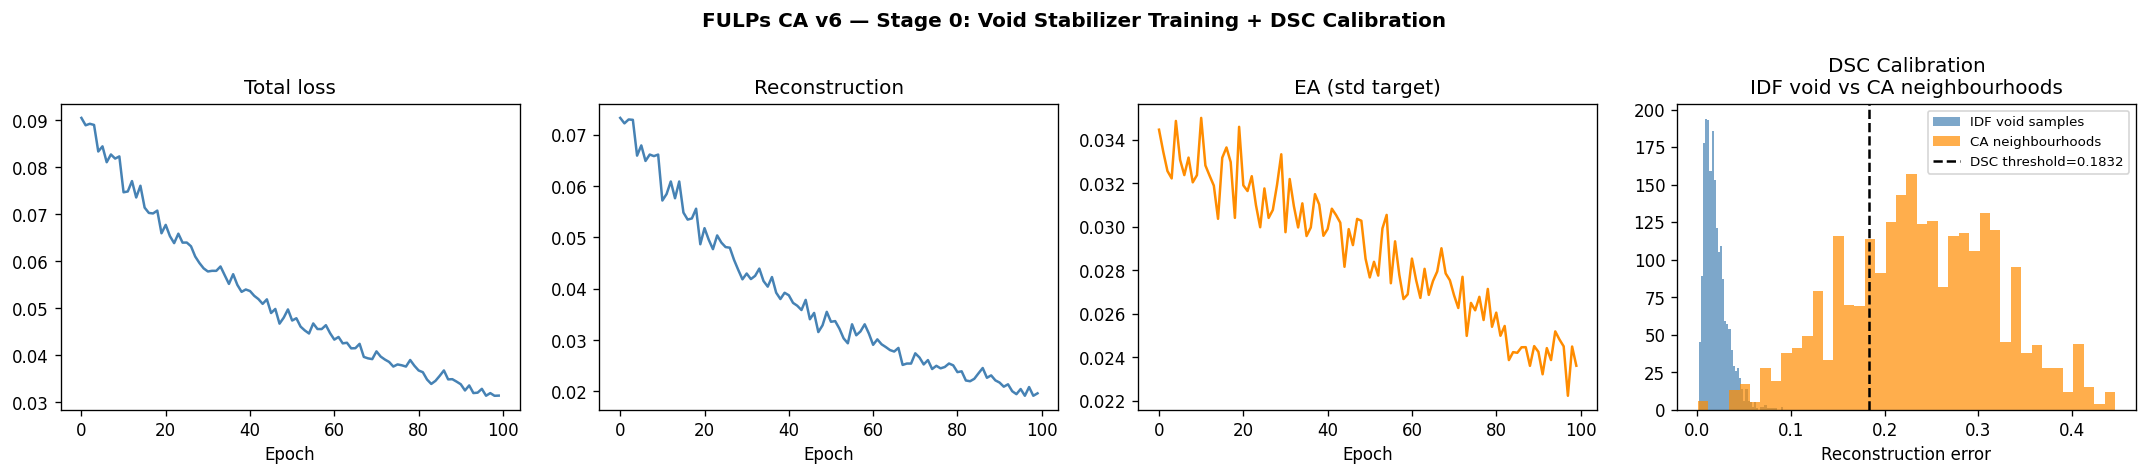

Void training complete.  Final reconstruction loss: 0.0196
DSC threshold (25th pct of CA distribution): 0.1832
Saved: /content/fulps_ca_v6_void_training.png


In [7]:
# ── Cell 6: Train VoidStabilizer + DSC Calibration ───────────────────────────
# Identical to v5. Model is trained once and frozen for all runs.

VOID_MODEL, void_loss_hist = train_void_stabilizer(IDF_MEANS, IDF_STDS, IDF_L, seed=42)

# DSC threshold calibration
with torch.no_grad():
    _void_s = torch.FloatTensor(sample_idf(IDF_MEANS, IDF_STDS, IDF_L, 2000))
    _void_xh, _ = VOID_MODEL(_void_s)
    _void_err = nn.functional.mse_loss(_void_s, _void_xh, reduction='none').mean(dim=1).numpy()

# Sample CA neighbourhoods for calibration
np.random.seed(99)
_cal_grid = np.random.randint(0, 2, (50, 50), dtype=np.int8)
_cal_nbrs = []
for di in range(-1, 2):
    for dj in range(-1, 2):
        _cal_nbrs.append(np.roll(np.roll(_cal_grid, di, 0), dj, 1).ravel())
_cal_nbr_arr = np.stack(_cal_nbrs, axis=1).astype(np.float32)
with torch.no_grad():
    _cal_t = torch.FloatTensor(_cal_nbr_arr)
    _cal_xh, _ = VOID_MODEL(_cal_t)
    _ca_err = nn.functional.mse_loss(_cal_t, _cal_xh, reduction='none').mean(dim=1).numpy()

DSC_THRESHOLD = float(np.percentile(_ca_err, 25))

# ── Plot: Void Training + DSC Calibration ────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle('FULPs CA v6 — Stage 0: Void Stabilizer Training + DSC Calibration',
             fontsize=12, fontweight='bold')

for ax, col, lbl in zip(axes[:3],
                        [void_loss_hist[:,0], void_loss_hist[:,1], void_loss_hist[:,2]],
                        ['Total loss', 'Reconstruction', 'EA (std target)']):
    ax.plot(col, color='steelblue' if lbl!='EA (std target)' else 'darkorange')
    ax.set_title(lbl); ax.set_xlabel('Epoch')

ax = axes[3]
ax.hist(_void_err, bins=40, alpha=0.7, color='steelblue', label='IDF void samples')
ax.hist(_ca_err,   bins=40, alpha=0.7, color='darkorange', label='CA neighbourhoods')
ax.axvline(DSC_THRESHOLD, color='black', linestyle='--', label=f'DSC threshold={DSC_THRESHOLD:.4f}')
ax.set_title('DSC Calibration\nIDF void vs CA neighbourhoods')
ax.set_xlabel('Reconstruction error'); ax.legend(fontsize=8)

plt.tight_layout()
vp = os.path.join(OUT_DIR, 'fulps_ca_v6_void_training.png')
plt.savefig(vp, dpi=150, bbox_inches='tight'); plt.show()
print(f'Void training complete.  Final reconstruction loss: {void_loss_hist[-1,1]:.4f}')
print(f'DSC threshold (25th pct of CA distribution): {DSC_THRESHOLD:.4f}')
print(f'Saved: {vp}')

In [8]:
# ── Cell 7: GoL Truth Tables (unchanged from v5) ─────────────────────────────
def build_gol_truth(perturbed=False):
    truth = np.zeros(N_STATES, dtype=np.int8)
    for s in range(N_STATES):
        centre = (s >> 4) & 1
        neighbours = bin(s).count('1') - centre
        if centre == 1:
            truth[s] = 1 if (neighbours in ({2,3,4} if perturbed else {2,3})) else 0
        else:
            truth[s] = 1 if neighbours == 3 else 0
    return truth

GOL_TRUTH_ORIG = build_gol_truth(perturbed=False)
GOL_TRUTH_PERT = build_gol_truth(perturbed=True)
AFFECTED_MASK  = (GOL_TRUTH_ORIG != GOL_TRUTH_PERT)

print(f'GoL truth tables ready.  Affected states: {AFFECTED_MASK.sum()}/512')

GoL truth tables ready.  Affected states: 70/512


In [9]:
import numpy as np

# ── Neighbourhood encoding (unchanged) ───────────────────────────────────────
_II = np.repeat(np.arange(GRID_H), GRID_W)
_JJ = np.tile  (np.arange(GRID_W), GRID_H)

def encode_neighbourhoods(grid):
    """Returns (nbr_indices [H,W], nbr_flat [H*W, 9])."""
    rows = []
    for di in range(-1, 2):
        for dj in range(-1, 2):
            rows.append(np.roll(np.roll(grid, di, 0), dj, 1).ravel())
    nbr_flat = np.stack(rows, axis=1).astype(np.float32)
    # Index into 512-state table: bit-pack (centre at position 4)
    bits = nbr_flat.astype(np.int32)
    weights = 2**np.arange(9, dtype=np.int32)
    nbr_idx = (bits @ weights).reshape(GRID_H, GRID_W)
    return nbr_idx, nbr_flat

# ── Metric helpers (unchanged) ────────────────────────────────────────────────
def table_accuracy_grid(table, truth):
    p = table[..., 1] / np.maximum(table.sum(axis=-1), 1)
    return (((p > BASE_THRESHOLD).astype(np.int8) == truth[None, None, :]).mean(axis=-1)
            .astype(np.float32))

def table_coverage_grid(table):
    return (table.max(axis=-1) > 1.0).mean(axis=-1).astype(np.float32)

def per_state_accuracy_grid(table, truth):
    obs = (table.max(axis=-1) > 1.0)
    p   = table[..., 1] / np.maximum(table.sum(axis=-1), 1)
    corr = ((p > BASE_THRESHOLD).astype(np.int8) == truth[None, None, :]) & obs
    n = obs.sum(axis=-1).astype(np.float32)
    return np.where(n > 0, corr.sum(axis=-1).astype(np.float32) / np.maximum(n, 1),
                    np.nan).astype(np.float32)

def affected_state_accuracy(table, nbr_indices, truth):
    # Flatten nbr_indices to match _II and _JJ for advanced indexing
    nbr_indices_flat = nbr_indices.ravel()
    ia = AFFECTED_MASK[nbr_indices_flat]; n = int(ia.sum())
    if n == 0: return np.nan, 0
    c = table[_II, _JJ, nbr_indices_flat]
    p = c[..., 1] / np.maximum(c.sum(axis=-1), 1)
    return float(((p > BASE_THRESHOLD).astype(np.int8)[ia] == truth[nbr_indices_flat][ia]).mean()), n

def detect_stable_cells(sh, mc=STABLE_MAX_CHANGES):
    return np.sum(np.abs(np.diff(sh.astype(np.int16), axis=0)), axis=0) <= mc

def compute_cv(pl, s, e):
    a = np.array(pl[s:e], dtype=np.float64)
    return float(a.std() / a.mean()) if a.mean() > 1e-6 else np.nan

def compute_morans_i(binary_grid):
    """Moran's I spatial autocorrelation (toroidal 8-connectivity). Range approx [-1,1+]."""
    x = binary_grid.astype(np.float64)
    n = x.size; mean_x = x.mean()
    if mean_x < 1e-9 or mean_x > 1-1e-9: return 0.0
    z = x - mean_x
    lag = np.zeros_like(z)
    for di in [-1, 0, 1]:
        for dj in [-1, 0, 1]:
            if di==0 and dj==0: continue
            lag += np.roll(np.roll(z, di, 0), dj, 1)
    lag /= 8.0
    num   = n * np.sum(z * lag)
    denom = 8.0 * np.sum(z**2)
    return float(num / denom) if abs(denom) > 1e-9 else 0.0

def compute_morans_i_rule(rule_map, rule_id):
    """Moran's I for spatial clustering of cells using a specific rule."""
    return compute_morans_i((rule_map == rule_id).astype(np.float64))

def compute_nbr_mean_distress(distress_grid):
    nbr_sum = np.zeros((GRID_H, GRID_W), dtype=np.float32)
    for di in [-1, 0, 1]:
        for dj in [-1, 0, 1]:
            if di==0 and dj==0: continue
            nbr_sum += np.roll(np.roll(distress_grid, di, 0), dj, 1)
    return nbr_sum / 8.0

def cre_timestep(contra_history, pre_mean, post_start, tolerance=0.05):
    if np.isnan(pre_mean): return float(N_TIMESTEPS)
    threshold = pre_mean + tolerance
    for t in range(post_start, N_TIMESTEPS - 4):
        if all(contra_history[t+k] <= threshold for k in range(5)):
            return float(t)
    return float(N_TIMESTEPS)

def om(arr, mask):
    if not mask.any(): return np.nan
    v = arr[mask]; v = v[~np.isnan(v)]
    return float(v.mean()) if len(v) > 0 else np.nan

# ── v6 NEW: ARS metric helpers ────────────────────────────────────────────────

def shannon_entropy(counts):
    """
    Rule Diversity Index: Shannon entropy of rule distribution.
    counts: array of length N_RULES with cell counts per rule.
    Returns H in [0, log2(N_RULES)]. Zero = all cells on same rule.
    """
    total = counts.sum()
    if total == 0: return 0.0
    p = counts / total
    p = p[p > 0]
    return float(-np.sum(p * np.log2(p)))

def rule_dominance(rule_map):
    """
    Rule Dominance: fraction of cells using the most common rule.
    Returns (dominance_fraction, dominant_rule_id).
    """
    counts = np.bincount(rule_map.ravel(), minlength=N_RULES)
    dom_id = int(np.argmax(counts))
    return float(counts[dom_id] / counts.sum()), dom_id

def compute_rule_counts(rule_map):
    """Return array of length N_RULES with per-rule cell counts."""
    return np.bincount(rule_map.ravel(), minlength=N_RULES).astype(np.float32)

print('Grid + ARS utilities defined.')
print('  v6 new: shannon_entropy, rule_dominance, compute_rule_counts, compute_morans_i_rule')

Grid + ARS utilities defined.
  v6 new: shannon_entropy, rule_dominance, compute_rule_counts, compute_morans_i_rule


In [10]:
import numpy as np
import torch
import torch.nn as nn

# ── State initialisers (unchanged from v5) ────────────────────────────────────
def init_tables():    return np.ones((GRID_H, GRID_W, N_STATES, 2), dtype=np.float32)
def init_are_state(): return {'pos_rep':    np.zeros((GRID_H, GRID_W, REP_DIM), dtype=np.float32),
                               'neg_rep':    np.zeros((GRID_H, GRID_W, REP_DIM), dtype=np.float32),
                               'pos_active': np.zeros((GRID_H, GRID_W), dtype=bool),
                               'neg_active': np.zeros((GRID_H, GRID_W), dtype=bool),
                               'margin_ema': np.zeros((GRID_H, GRID_W), dtype=np.float32)}
def init_conv_state(): return {'f_timestep':   np.full((GRID_H,GRID_W), float(N_TIMESTEPS), dtype=np.float32),
                                'f_locked':      np.zeros((GRID_H, GRID_W), dtype=bool),
                                'visit_counts':  np.zeros((GRID_H, GRID_W, N_STATES), dtype=np.int32)}
def init_rec_state():  return {'recovery_t':    np.full((GRID_H,GRID_W), float(N_TIMESTEPS), dtype=np.float32),
                                'rec_locked':    np.zeros((GRID_H, GRID_W), dtype=bool),
                                'has_observed':  np.zeros((GRID_H, GRID_W), dtype=bool)}

# ── v6 NEW: ARS state initialiser ────────────────────────────────────────────
def init_ars_state():
    """
    New state variables introduced in v6 for the ARS condition.

    active_rule      : (H,W) int8  — which rule governs each cell (0–3).
    rule_usage       : (H,W,R)     — how many timesteps each rule has been active.
    rule_successes   : (H,W,R)     — successful predictions while on each rule.
    rule_contra_hist : (H,W,R)     — contradiction events accumulated per rule.
    rule_recovery    : (H,W,R)     — post-perturbation recovery timestep per rule
                                     (proxy: 1/mean_contra after perturbation).
    cooldown         : (H,W)       — timesteps remaining before cell may switch again.
    switch_count     : (H,W)       — total number of rule switches by this cell.
    rule_at_perturb  : (H,W)       — which rule each cell was on when perturbation hit.
    """
    R = N_RULES
    return {
        'active_rule':      np.zeros((GRID_H, GRID_W), dtype=np.int8),
        'rule_usage':       np.zeros((GRID_H, GRID_W, R), dtype=np.float32),
        'rule_successes':   np.zeros((GRID_H, GRID_W, R), dtype=np.float32),
        'rule_contra_hist': np.zeros((GRID_H, GRID_W, R), dtype=np.float32),
        'rule_recovery':    np.full((GRID_H, GRID_W, R), np.nan, dtype=np.float32),
        'cooldown':         np.zeros((GRID_H, GRID_W), dtype=np.int32),
        'switch_count':     np.zeros((GRID_H, GRID_W), dtype=np.int32),
        'rule_at_perturb':  np.zeros((GRID_H, GRID_W), dtype=np.int8),
    }

# ── ARE functions (unchanged from v5) ────────────────────────────────────────
def compute_are_margin(reps_flat, are_state, threshold):
    rep = reps_flat.reshape(GRID_H, GRID_W, REP_DIM)
    def cs(a, b):
        d = np.sum(a*b, axis=-1)
        n = np.linalg.norm(a, axis=-1) * np.linalg.norm(b, axis=-1)
        return d / np.where(n > 1e-8, n, 1e-8)
    ps = np.where(are_state['pos_active'], cs(rep, are_state['pos_rep']), 0.0)
    ns = np.where(are_state['neg_active'], cs(rep, are_state['neg_rep']), 0.0)
    m  = ps - ns
    both   = are_state['pos_active'] & are_state['neg_active']
    contra = (np.abs(m) < threshold) & (np.maximum(ps, ns) > CONF_GATE) & both
    return m, contra, ps, ns

def update_are_buffers(are_state, reps_flat, outcomes):
    rep = reps_flat.reshape(GRID_H, GRID_W, REP_DIM)
    for mask, key in [(outcomes==1, 'pos'), (outcomes==0, 'neg')]:
        if mask.any():
            are_state[f'{key}_rep'][mask] = ((1-EMA_ALPHA)*are_state[f'{key}_rep'][mask]
                                             + EMA_ALPHA*rep[mask])
            are_state[f'{key}_active'][mask] = True

def update_table_single(table, ni, outcomes, cw):
    table[_II, _JJ, ni.ravel(), outcomes.ravel().astype(int)] += cw.ravel()

def update_convergence_single(cs, t, table, ni, outcomes, ac):
    ni_flat = ni.ravel()
    outcomes_flat = outcomes.ravel()
    ac_flat = ac.ravel()

    cs['visit_counts'][_II, _JJ, ni_flat] += 1
    v  = cs['visit_counts'][_II, _JJ, ni_flat]
    o2 = (v >= 2)

    c  = table[_II, _JJ, ni_flat]
    p = c[...,1] / np.maximum(c.sum(axis=-1), 1)

    th = np.where(ac_flat, CONTRA_THRESHOLD, BASE_THRESHOLD)

    corr = ((p > th).astype(np.int8) == outcomes_flat)
    conf = np.where(outcomes_flat==1, p > th, p < (1-th))

    newly = corr & conf & o2 & ~cs['f_locked'].ravel()

    cs['f_timestep'].ravel()[newly] = t
    cs['f_locked'].ravel()[newly] = True

def update_recovery_single(rs, t, table, ni, ac):
    ni_flat = ni.ravel()
    ac_flat = ac.ravel()

    ia = AFFECTED_MASK[ni_flat]
    if not ia.any(): return
    rs['has_observed'].ravel()[ia] = True

    c  = table[_II, _JJ, ni_flat]
    p = c[...,1] / np.maximum(c.sum(axis=-1), 1)

    th = np.where(ac_flat, CONTRA_THRESHOLD, BASE_THRESHOLD)

    newly = ia & (p > th) & ~rs['rec_locked'].ravel()
    rs['recovery_t'].ravel()[newly] = t
    rs['rec_locked'].ravel()[newly] = True

def compute_gating_mask(ac_gate, pos_sim, neg_sim, are_state, nbr_distress=None):
    max_sim = np.maximum(pos_sim, neg_sim)
    if nbr_distress is not None:
        nbr_distress_clipped = np.clip(nbr_distress, 0.0, 1.0)
        effective_conf = GATE_CONF_GATE * (1.0 - SIGNAL_WEIGHT * nbr_distress_clipped)
        strong_belief  = max_sim > effective_conf
    else:
        strong_belief = max_sim > GATE_CONF_GATE
    return ac_gate & strong_belief

def compute_distress(pos_sim, neg_sim, margin):
    return np.maximum(pos_sim, neg_sim) * np.clip(np.abs(margin), 0.0, 1.0)

# ── v6 NEW: ARS update function ───────────────────────────────────────────────
def update_ars_state(ars, t, contra_mask, count_neighbours_current, current_grid, actual_outcome):
    """
    Update ARS bookkeeping for the current timestep:
      - Accumulate per-rule usage, contradiction, and success counts for ALL rules.
      - Decrement cooldown timers.

    contra_mask  : (H,W) bool — which cells have active ARE contradiction
    count_neighbours_current: (H,W) int8 — neighbourhood counts of the current grid
    current_grid : (H,W) int8 — the current state of the ARS grid
    actual_outcome: (H,W) int8 — the actual outcome (next state) of the ARS grid
    """
    nc = count_neighbours_current
    for r in range(N_RULES):
        rt = RULE_TABLES[r]
        # what rule r would have predicted based on current_grid and its neighbours
        rule_pred = rt[current_grid, nc]
        rule_correct = (rule_pred == actual_outcome)
        ars['rule_usage'][..., r] += 1.0  # all rules get usage every step
        ars['rule_successes'][rule_correct, r] += 1.0
        ars['rule_contra_hist'][contra_mask & ~rule_correct, r] += 1.0
    # Decrement cooldown
    ars['cooldown'] = np.maximum(ars['cooldown'] - 1, 0)

def compute_rule_score(ars):
    """
    Local rule quality estimate for each cell × rule combination.
    Score = (successes / max(usage, 1)) - lambda * (contra / max(usage, 1))
    where lambda=0.5 penalises contradiction.

    Returns score array of shape (H, W, N_RULES).
    """
    LAMBDA = 0.5  # contradiction penalty weight
    usage  = ars['rule_usage']      # (H,W,R)
    succ   = ars['rule_successes']
    contra = ars['rule_contra_hist']

    safe_usage = np.maximum(usage, 1.0)
    score = (succ / safe_usage) - LAMBDA * (contra / safe_usage)

    # Exploration bonus for under-sampled rules removed as per user instruction.

    return score

def maybe_switch_rules(ars, t):
    """
    Periodic rule reconsideration at multiples of SWITCH_INTERVAL.
    Only cells whose cooldown has expired may switch.
    Selection is softmax over rule scores (temperature = EXPLOIT_TEMP).
    Cells that switch get a new cooldown.

    This is the only place rule_map changes. No global information is used.
    """
    if t == 0 or (t % SWITCH_INTERVAL != 0):
        return 0  # no switches this timestep

    can_switch = (ars['cooldown'] == 0)  # (H, W) bool
    if not can_switch.any():
        return 0

    scores = compute_rule_score(ars)  # (H, W, R)

    # Softmax over rules for each cell
    logits = scores / EXPLOIT_TEMP
    logits -= logits.max(axis=-1, keepdims=True)  # numerical stability
    exp_l  = np.exp(logits)
    probs  = exp_l / exp_l.sum(axis=-1, keepdims=True)  # (H, W, R)

    # Sample a new rule for each eligible cell
    flat_probs = probs.reshape(-1, N_RULES)  # (H*W, R)
    cumprobs   = flat_probs.cumsum(axis=1)
    rands      = np.random.rand(GRID_H * GRID_W, 1)
    new_rules  = (rands > cumprobs).sum(axis=1).clip(0, N_RULES-1).astype(np.int8)
    new_rules  = new_rules.reshape(GRID_H, GRID_W)

    old_rules = ars['active_rule'].copy()
    switched  = can_switch & (new_rules != old_rules)

    ars['active_rule'][switched] = new_rules[switched]
    ars['cooldown'][switched]    = SWITCH_COOLDOWN
    ars['switch_count'][switched] += 1

    return int(switched.sum())

In [11]:
import numpy as np
import torch
import torch.nn as nn

# ── State initialisers (unchanged from v5) ────────────────────────────────────
def init_tables():    return np.ones((GRID_H, GRID_W, N_STATES, 2), dtype=np.float32)
def init_are_state(): return {'pos_rep':    np.zeros((GRID_H, GRID_W, REP_DIM), dtype=np.float32),
                               'neg_rep':    np.zeros((GRID_H, GRID_W, REP_DIM), dtype=np.float32),
                               'pos_active': np.zeros((GRID_H, GRID_W), dtype=bool),
                               'neg_active': np.zeros((GRID_H, GRID_W), dtype=bool),
                               'margin_ema': np.zeros((GRID_H, GRID_W), dtype=np.float32)}
def init_conv_state(): return {'f_timestep':   np.full((GRID_H,GRID_W), float(N_TIMESTEPS), dtype=np.float32),
                                'f_locked':      np.zeros((GRID_H, GRID_W), dtype=bool),
                                'visit_counts':  np.zeros((GRID_H, GRID_W, N_STATES), dtype=np.int32)}
def init_rec_state():  return {'recovery_t':    np.full((GRID_H,GRID_W), float(N_TIMESTEPS), dtype=np.float32),
                                'rec_locked':    np.zeros((GRID_H, GRID_W), dtype=bool),
                                'has_observed':  np.zeros((GRID_H, GRID_W), dtype=bool)}

# ── v6 NEW: ARS state initialiser ────────────────────────────────────────────
def init_ars_state():
    """
    New state variables introduced in v6 for the ARS condition.

    active_rule      : (H,W) int8  — which rule governs each cell (0–3).
    rule_usage       : (H,W,R)     — how many timesteps each rule has been active.
    rule_successes   : (H,W,R)     — successful predictions while on each rule.
    rule_contra_hist : (H,W,R)     — contradiction events accumulated per rule.
    rule_recovery    : (H,W,R)     — post-perturbation recovery timestep per rule
                                     (proxy: 1/mean_contra after perturbation).
    cooldown         : (H,W)       — timesteps remaining before cell may switch again.
    switch_count     : (H,W)       — total number of rule switches by this cell.
    rule_at_perturb  : (H,W)       — which rule each cell was on when perturbation hit.
    """
    R = N_RULES
    return {
        'active_rule':      np.zeros((GRID_H, GRID_W), dtype=np.int8),
        'rule_usage':       np.zeros((GRID_H, GRID_W, R), dtype=np.float32),
        'rule_successes':   np.zeros((GRID_H, GRID_W, R), dtype=np.float32),
        'rule_contra_hist': np.zeros((GRID_H, GRID_W, R), dtype=np.float32),
        'rule_recovery':    np.full((GRID_H, GRID_W, R), np.nan, dtype=np.float32),
        'cooldown':         np.zeros((GRID_H, GRID_W), dtype=np.int32),
        'switch_count':     np.zeros((GRID_H, GRID_W), dtype=np.int32),
        'rule_at_perturb':  np.zeros((GRID_H, GRID_W), dtype=np.int8),
    }

# ── ARE functions (unchanged from v5) ────────────────────────────────────────
def compute_are_margin(reps_flat, are_state, threshold):
    rep = reps_flat.reshape(GRID_H, GRID_W, REP_DIM)
    def cs(a, b):
        d = np.sum(a*b, axis=-1)
        n = np.linalg.norm(a, axis=-1) * np.linalg.norm(b, axis=-1)
        return d / np.where(n > 1e-8, n, 1e-8)
    ps = np.where(are_state['pos_active'], cs(rep, are_state['pos_rep']), 0.0)
    ns = np.where(are_state['neg_active'], cs(rep, are_state['neg_rep']), 0.0)
    m  = ps - ns
    both   = are_state['pos_active'] & are_state['neg_active']
    contra = (np.abs(m) < threshold) & (np.maximum(ps, ns) > CONF_GATE) & both
    return m, contra, ps, ns

def update_are_buffers(are_state, reps_flat, outcomes):
    rep = reps_flat.reshape(GRID_H, GRID_W, REP_DIM)
    for mask, key in [(outcomes==1, 'pos'), (outcomes==0, 'neg')]:
        if mask.any():
            are_state[f'{key}_rep'][mask] = ((1-EMA_ALPHA)*are_state[f'{key}_rep'][mask]
                                             + EMA_ALPHA*rep[mask])
            are_state[f'{key}_active'][mask] = True

def update_table_single(table, ni, outcomes, cw):
    table[_II, _JJ, ni.ravel(), outcomes.ravel().astype(int)] += cw.ravel()

def update_convergence_single(cs, t, table, ni, outcomes, ac):
    ni_flat = ni.ravel()
    outcomes_flat = outcomes.ravel()
    ac_flat = ac.ravel()

    cs['visit_counts'][_II, _JJ, ni_flat] += 1
    v  = cs['visit_counts'][_II, _JJ, ni_flat]
    o2 = (v >= 2)

    c  = table[_II, _JJ, ni_flat]
    p = c[...,1] / np.maximum(c.sum(axis=-1), 1)

    th = np.where(ac_flat, CONTRA_THRESHOLD, BASE_THRESHOLD)

    corr = ((p > th).astype(np.int8) == outcomes_flat)
    conf = np.where(outcomes_flat==1, p > th, p < (1-th))

    newly = corr & conf & o2 & ~cs['f_locked'].ravel()

    cs['f_timestep'].ravel()[newly] = t
    cs['f_locked'].ravel()[newly] = True

def update_recovery_single(rs, t, table, ni, ac):
    ni_flat = ni.ravel()
    ac_flat = ac.ravel()

    ia = AFFECTED_MASK[ni_flat]
    if not ia.any(): return
    rs['has_observed'].ravel()[ia] = True

    c  = table[_II, _JJ, ni_flat]
    p = c[...,1] / np.maximum(c.sum(axis=-1), 1)

    th = np.where(ac_flat, CONTRA_THRESHOLD, BASE_THRESHOLD)

    newly = ia & (p > th) & ~rs['rec_locked'].ravel()
    rs['recovery_t'].ravel()[newly] = t
    rs['rec_locked'].ravel()[newly] = True

def compute_gating_mask(ac_gate, pos_sim, neg_sim, are_state, nbr_distress=None):
    max_sim = np.maximum(pos_sim, neg_sim)
    if nbr_distress is not None:
        nbr_distress_clipped = np.clip(nbr_distress, 0.0, 1.0)
        effective_conf = GATE_CONF_GATE * (1.0 - SIGNAL_WEIGHT * nbr_distress_clipped)
        strong_belief  = max_sim > effective_conf
    else:
        strong_belief = max_sim > GATE_CONF_GATE
    return ac_gate & strong_belief

def compute_distress(pos_sim, neg_sim, margin):
    return np.maximum(pos_sim, neg_sim) * np.clip(np.abs(margin), 0.0, 1.0)

# ── v6 NEW: ARS update function ───────────────────────────────────────────────
def update_ars_state(ars, t, contra_mask, count_neighbours_current, current_grid, actual_outcome):
    """
    Update ARS bookkeeping for the current timestep:
      - Accumulate per-rule usage, contradiction, and success counts for ALL rules.
      - Decrement cooldown timers.

    contra_mask  : (H,W) bool — which cells have active ARE contradiction
    count_neighbours_current: (H,W) int8 — neighbourhood counts of the current grid
    current_grid : (H,W) int8 — the current state of the ARS grid
    actual_outcome: (H,W) int8 — the actual outcome (next state) of the ARS grid
    """
    nc = count_neighbours_current
    for r in range(N_RULES):
        rt = RULE_TABLES[r]
        # what rule r would have predicted based on current_grid and its neighbours
        rule_pred = rt[current_grid, nc]
        rule_correct = (rule_pred == actual_outcome)
        ars['rule_usage'][..., r] += 1.0  # all rules get usage every step
        ars['rule_successes'][rule_correct, r] += 1.0
        ars['rule_contra_hist'][contra_mask & ~rule_correct, r] += 1.0
    # Decrement cooldown
    ars['cooldown'] = np.maximum(ars['cooldown'] - 1, 0)

def compute_rule_score(ars):
    """
    Local rule quality estimate for each cell × rule combination.
    Score = (successes / max(usage, 1)) - lambda * (contra / max(usage, 1))
    where lambda=0.5 penalises contradiction.

    Returns score array of shape (H, W, N_RULES).
    """
    LAMBDA = 0.5  # contradiction penalty weight
    usage  = ars['rule_usage']      # (H,W,R)
    succ   = ars['rule_successes']
    contra = ars['rule_contra_hist']

    safe_usage = np.maximum(usage, 1.0)
    score = (succ / safe_usage) - LAMBDA * (contra / safe_usage)

    # Exploration bonus for under-sampled rules removed as per user instruction.

    return score

def maybe_switch_rules(ars, t):
    """
    Periodic rule reconsideration at multiples of SWITCH_INTERVAL.
    Only cells whose cooldown has expired may switch.
    Selection is softmax over rule scores (temperature = EXPLOIT_TEMP).
    Cells that switch get a new cooldown.

    This is the only place rule_map changes. No global information is used.
    """
    if t == 0 or (t % SWITCH_INTERVAL != 0):
        return 0  # no switches this timestep

    can_switch = (ars['cooldown'] == 0)  # (H, W) bool
    if not can_switch.any():
        return 0

    scores = compute_rule_score(ars)  # (H, W, R)

    # Softmax over rules for each cell
    logits = scores / EXPLOIT_TEMP
    logits -= logits.max(axis=-1, keepdims=True)  # numerical stability
    exp_l  = np.exp(logits)
    probs  = exp_l / exp_l.sum(axis=-1, keepdims=True)  # (H, W, R)

    # Sample a new rule for each eligible cell
    flat_probs = probs.reshape(-1, N_RULES)  # (H*W, R)
    cumprobs   = flat_probs.cumsum(axis=1)
    rands      = np.random.rand(GRID_H * GRID_W, 1)
    new_rules  = (rands > cumprobs).sum(axis=1).clip(0, N_RULES-1).astype(np.int8)
    new_rules  = new_rules.reshape(GRID_H, GRID_W)

    old_rules = ars['active_rule'].copy()
    switched  = can_switch & (new_rules != old_rules)

    ars['active_rule'][switched] = new_rules[switched]
    ars['cooldown'][switched]    = SWITCH_COOLDOWN
    ars['switch_count'][switched] += 1

    return int(switched.sum())

print('FULPs state utilities defined (v6: ARS layer added).')
print('  New: init_ars_state, update_ars_state, compute_rule_score, maybe_switch_rules')
# ── Cell 10: Simulation Engine ────────────────────────────────────────────────
#
# v6: FIVE simultaneous conditions per seed.
#
#   base    : standard GoL + uniform table                    (unchanged from v5)
#   learn   : standard GoL + FULPs table+ARE                 (unchanged from v5)
#   gate    : selective-gated GoL + FULPs                    (unchanged from v5)
#   signal  : gated GoL + FULPs + distress broadcast         (unchanged from v5)
#   ars     : per-cell rule selection via local ARS mechanism (v6 NEW)
#
# The ARS condition inherits the full v5 signal stack (ARE + gating + distress)
# AND adds the rule selection layer on top. The ARS condition is thus the most
# complete FULPs implementation in the programme to date.
#
# RISK CONTROLS:
#   - Runaway switching: prevented by SWITCH_COOLDOWN and SWITCH_INTERVAL.
#   - Rule collapse: MIN_RULE_TRIALS exploration bonus ensures all rules are tried.
#   - Population collapse: ARS condition gets its own grid; if population falls
#     below COLLAPSE_THRESHOLD for 10 consecutive steps, run is flagged.

def run_simulation(seed, void_model, idf, is_single_run=False, verbose=False):
    np.random.seed(seed); torch.manual_seed(seed)

    # ── Grid initialisation ───────────────────────────────────────────────────
    grid_std  = np.random.randint(0, 2, size=(GRID_H, GRID_W), dtype=np.int8)
    grid_gate = grid_std.copy()
    grid_sig  = grid_std.copy()
    grid_ars  = grid_std.copy()  # v6 NEW

    # ── Table + ARE + recovery state ──────────────────────────────────────────
    base_table  = init_tables(); learn_table = init_tables()
    gate_table  = init_tables(); sig_table   = init_tables()
    ars_table   = init_tables()  # v6 NEW

    are_learn = init_are_state(); are_gate  = init_are_state()
    are_sig   = init_are_state(); are_ars   = init_are_state()  # v6 NEW

    conv_base  = init_conv_state(); conv_learn = init_conv_state()
    conv_gate  = init_conv_state(); conv_sig   = init_conv_state()
    conv_ars   = init_conv_state()  # v6 NEW

    rec_base  = init_rec_state(); rec_learn = init_rec_state()
    rec_gate  = init_rec_state(); rec_sig   = init_rec_state()
    rec_ars   = init_rec_state()   # v6 NEW

    ars_state = init_ars_state()   # v6 NEW

    # ── History arrays ────────────────────────────────────────────────────────
    sh_std  = np.zeros((N_TIMESTEPS, GRID_H, GRID_W), dtype=np.int8)
    sh_gate = np.zeros((N_TIMESTEPS, GRID_H, GRID_W), dtype=np.int8)
    sh_sig  = np.zeros((N_TIMESTEPS, GRID_H, GRID_W), dtype=np.int8)
    sh_ars  = np.zeros((N_TIMESTEPS, GRID_H, GRID_W), dtype=np.int8)  # v6 NEW

    pop_std  = []; pop_gate  = []; pop_sig  = []; pop_ars  = []
    contra_l_h = []; contra_gate_h = []; contra_sig_h = []; contra_ars_h = []
    gate_h = []; sig_h = []; ars_gate_h = []
    morans_gate_h = []; morans_sig_h = []
    distress_mean_h = []

    # ── v6 NEW: ARS metric histories ─────────────────────────────────────────
    rule_dist_h      = []   # (T, N_RULES) — fractions of cells per rule
    rule_entropy_h   = []   # (T,) — Shannon entropy of rule distribution
    rule_dominance_h = []   # (T,) — fraction on dominant rule
    rule_switch_h    = []   # (T,) — number of switches this timestep
    rule_morans_h    = []   # (T, N_RULES) — Moran's I per rule
    total_switches   = 0

    # Single-run histories
    hist = None
    if is_single_run:
        hist = {
            'pop_std':[],'pop_gate':[],'pop_sig':[],'pop_ars':[],
            'pop_diff_gate':[],'pop_diff_sig':[],'pop_diff_ars':[],
            'contra_l':[],'gate_rate':[],'sig_rate':[],'ars_rate':[],
            'distress_mean':[], 'morans_gate':[],'morans_sig':[],
            'vt_signal':[],
            'tacc_base':[],'tacc_learn':[],'tacc_gate':[],'tacc_sig':[],'tacc_ars':[],
            'rec_base':[],'rec_learn':[],'rec_gate':[],'rec_sig':[],'rec_ars':[],
            'aff_base':[],'aff_gate':[],'aff_sig':[],'aff_ars':[],
            # ARS-specific
            'rule_dist':[],'rule_entropy':[],'rule_dominance':[],'rule_switches':[],
            'rule_morans':[],
        }

    # ── Pre-compute idf reference (void tether) ───────────────────────────────
    idf_means, idf_stds, idf_L = idf

    # ─────────────────────────────────────────────────────────────────────────
    # MAIN SIMULATION LOOP
    # ─────────────────────────────────────────────────────────────────────────
    for t in range(N_TIMESTEPS):
        sh_std[t]  = grid_std.copy()
        sh_gate[t] = grid_gate.copy()
        sh_sig[t]  = grid_sig.copy()
        sh_ars[t]  = grid_ars.copy()

        is_pert = (t >= T_PERTURB)
        ct = GOL_TRUTH_PERT if is_pert else GOL_TRUTH_ORIG
        prog = t / max(N_TIMESTEPS-1, 1)
        thresh = CONTRA_START + (CONTRA_END - CONTRA_START) * prog

        # ── Standard grid (base + learn — unchanged from v5) ──────────────────
        nbr_std, nbr_std_f = encode_neighbourhoods(grid_std)
        nt_std = torch.FloatTensor(nbr_std_f.reshape(-1, NBR_DIM))
        with torch.no_grad():
            dsc_std  = void_model.dsc(nt_std).numpy().reshape(GRID_H, GRID_W)
            reps_std = void_model.encode(nt_std).numpy()
        vt_s = float(sample_idf(idf_means, idf_stds, idf_L, 1).mean()) if is_single_run else 0.0
        next_std = tick_standard(grid_std, perturbed=is_pert)
        out_std  = next_std.astype(np.int8)

        ml, cl, _, _ = compute_are_margin(reps_std, are_learn, thresh)
        acl = cl & (dsc_std > DSC_THRESHOLD)
        cwl = np.ones((GRID_H, GRID_W), dtype=np.float32); cwl[acl] = CURIOSITY_WEIGHT
        contra_l_h.append(float(cl.mean()))

        nc_dummy = np.zeros((GRID_H, GRID_W), dtype=bool)
        update_table_single(base_table,  nbr_std, out_std, np.ones((GRID_H,GRID_W), dtype=np.float32))
        update_table_single(learn_table, nbr_std, out_std, cwl)
        if t >= BUFFER_DELAY: update_are_buffers(are_learn, reps_std, out_std)
        update_convergence_single(conv_base,  t, base_table,  nbr_std, out_std, nc_dummy)
        update_convergence_single(conv_learn, t, learn_table, nbr_std, out_std, acl)
        if is_pert:
            update_recovery_single(rec_base,  t, base_table,  nbr_std, nc_dummy)
            update_recovery_single(rec_learn, t, learn_table, nbr_std, acl)

        # ── Gate grid (v4.5 — unchanged) ──────────────────────────────────────
        nbr_gate, nbr_gate_f = encode_neighbourhoods(grid_gate)
        nt_gate = torch.FloatTensor(nbr_gate_f.reshape(-1, NBR_DIM))
        with torch.no_grad():
            dsc_g   = void_model.dsc(nt_gate).numpy().reshape(GRID_H, GRID_W)
            reps_g  = void_model.encode(nt_gate).numpy()
        mg, cg, psg, nsg = compute_are_margin(reps_g, are_gate, thresh)
        acg = cg & (dsc_g > DSC_THRESHOLD)
        gating_mask = compute_gating_mask(acg, psg, nsg, are_gate, nbr_distress=None)
        gate_h.append(float(gating_mask.mean()))
        contra_gate_h.append(float(cg.mean()))
        cwg = np.ones((GRID_H, GRID_W), dtype=np.float32); cwg[acg] = CURIOSITY_WEIGHT
        next_gate = tick_standard(grid_gate, perturbed=is_pert).copy()
        next_gate[gating_mask] = grid_gate[gating_mask]
        out_gate = next_gate.astype(np.int8)
        update_table_single(gate_table, nbr_gate, out_gate, cwg)
        if t >= BUFFER_DELAY: update_are_buffers(are_gate, reps_g, out_gate)
        update_convergence_single(conv_gate, t, gate_table, nbr_gate, out_gate, acg)
        if is_pert:
            update_recovery_single(rec_gate, t, gate_table, nbr_gate, acg)
        are_gate['margin_ema'] = ((1-MARGIN_EMA_ALPHA)*are_gate['margin_ema']
                                  + MARGIN_EMA_ALPHA*np.abs(mg))

        # ── Signal grid (v5 — unchanged) ──────────────────────────────────────
        nbr_sig, nbr_sig_f = encode_neighbourhoods(grid_sig)
        nt_sig = torch.FloatTensor(nbr_sig_f.reshape(-1, NBR_DIM))
        with torch.no_grad():
            dsc_s   = void_model.dsc(nt_sig).numpy().reshape(GRID_H, GRID_W)
            reps_s  = void_model.encode(nt_sig).numpy()
        ms, cs_m, pss, nss = compute_are_margin(reps_s, are_sig, thresh)
        acs = cs_m & (dsc_s > DSC_THRESHOLD)
        distress = compute_distress(pss, nss, ms)
        nbr_dist = compute_nbr_mean_distress(distress)
        sig_mask = compute_gating_mask(acs, pss, nss, are_sig, nbr_distress=nbr_dist)
        sig_h.append(float(sig_mask.mean()))
        contra_sig_h.append(float(cs_m.mean()))
        distress_mean_h.append(float(distress.mean()))
        mi_g = compute_morans_i(gating_mask.astype(np.float64))
        mi_s = compute_morans_i(sig_mask.astype(np.float64))
        morans_gate_h.append(mi_g); morans_sig_h.append(mi_s)
        cws = np.ones((GRID_H, GRID_W), dtype=np.float32); cws[acs] = CURIOSITY_WEIGHT
        next_sig = tick_standard(grid_sig, perturbed=is_pert).copy()
        next_sig[sig_mask] = grid_sig[sig_mask]
        out_sig = next_sig.astype(np.int8)
        update_table_single(sig_table, nbr_sig, out_sig, cws)
        if t >= BUFFER_DELAY: update_are_buffers(are_sig, reps_s, out_sig)
        update_convergence_single(conv_sig, t, sig_table, nbr_sig, out_sig, acs)
        if is_pert:
            update_recovery_single(rec_sig, t, sig_table, nbr_sig, acs)
        are_sig['margin_ema'] = ((1-MARGIN_EMA_ALPHA)*are_sig['margin_ema']
                                  + MARGIN_EMA_ALPHA*np.abs(ms))

        # ── ARS grid (v6 NEW) ─────────────────────────────────────────────────
        # Step 1: Potentially switch rules at this timestep
        n_switched = maybe_switch_rules(ars_state, t)
        total_switches += n_switched
        rule_switch_h.append(n_switched)

        # Step 2: Record rule assignment at perturbation time
        if t == T_PERTURB:
            ars_state['rule_at_perturb'] = ars_state['active_rule'].copy()

        # Step 3: Encode ARS neighbourhoods
        nbr_ars, nbr_ars_f = encode_neighbourhoods(grid_ars)
        nt_ars = torch.FloatTensor(nbr_ars_f.reshape(-1, NBR_DIM))
        with torch.no_grad():
            dsc_ar   = void_model.dsc(nt_ars).numpy().reshape(GRID_H, GRID_W)
            reps_ar  = void_model.encode(nt_ars).numpy()

        # Step 4: ARE for ARS condition (same as signal — full stack)
        mar, car, psar, nsar = compute_are_margin(reps_ar, are_ars, thresh)
        acar = car & (dsc_ar > DSC_THRESHOLD)
        dist_ars = compute_distress(psar, nsar, mar)
        nbr_dist_ars = compute_nbr_mean_distress(dist_ars)
        ars_gate_mask = compute_gating_mask(acar, psar, nsar, are_ars, nbr_distress=nbr_dist_ars)
        ars_gate_h.append(float(ars_gate_mask.mean()))
        contra_ars_h.append(float(car.mean()))
        cwar = np.ones((GRID_H, GRID_W), dtype=np.float32); cwar[acar] = CURIOSITY_WEIGHT

        # Step 5: Tick under per-cell rules
        next_ars = tick_ars(grid_ars, ars_state['active_rule']).copy()
        # Apply gating (same as signal: gate defers state change)
        next_ars[ars_gate_mask] = grid_ars[ars_gate_mask]
        out_ars = next_ars.astype(np.int8)

        # Step 6: Update tables and ARE
        update_table_single(ars_table, nbr_ars, out_ars, cwar)
        if t >= BUFFER_DELAY: update_are_buffers(are_ars, reps_ar, out_ars)
        update_convergence_single(conv_ars, t, ars_table, nbr_ars, out_ars, acar)
        if is_pert:
            update_recovery_single(rec_ars, t, ars_table, nbr_ars, acar)
        are_ars['margin_ema'] = ((1-MARGIN_EMA_ALPHA)*are_ars['margin_ema']
                                  + MARGIN_EMA_ALPHA*np.abs(mar))

        # Step 7: ARS bookkeeping — compute successes for score update
        nc_ars = count_neighbours(grid_ars)   # already available — neighbourhood counts
        update_ars_state(ars_state, t, acar, nc_ars, grid_ars, out_ars)

        # Step 8: ARS metric snapshots
        rc = compute_rule_counts(ars_state['active_rule'])
        rule_dist_h.append(rc / max(rc.sum(), 1))
        rule_entropy_h.append(shannon_entropy(rc))
        dom_frac, _ = rule_dominance(ars_state['active_rule'])
        rule_dominance_h.append(dom_frac)
        rule_morans_h.append([compute_morans_i_rule(ars_state['active_rule'], r)
                               for r in range(N_RULES)])

        # ── Population tracking ───────────────────────────────────────────────
        pop_std.append(population(grid_std))
        pop_gate.append(population(grid_gate))
        pop_sig.append(population(grid_sig))
        pop_ars.append(population(grid_ars))

        # ── Advance grids ─────────────────────────────────────────────────────
        grid_std  = next_std
        grid_gate = out_gate
        grid_sig  = out_sig
        grid_ars  = out_ars

        # ── Single-run history ────────────────────────────────────────────────
        if is_single_run:
            hist['pop_std'].append(pop_std[-1])
            hist['pop_gate'].append(pop_gate[-1])
            hist['pop_sig'].append(pop_sig[-1])
            hist['pop_ars'].append(pop_ars[-1])
            hist['pop_diff_gate'].append(pop_gate[-1] - pop_std[-1])
            hist['pop_diff_sig'].append(pop_sig[-1]  - pop_std[-1])
            hist['pop_diff_ars'].append(pop_ars[-1]  - pop_std[-1])
            hist['contra_l'].append(contra_l_h[-1])
            hist['gate_rate'].append(gate_h[-1])
            hist['sig_rate'].append(sig_h[-1])
            hist['ars_rate'].append(ars_gate_h[-1])
            hist['distress_mean'].append(distress_mean_h[-1])
            hist['morans_gate'].append(mi_g)
            hist['morans_sig'].append(mi_s)
            hist['vt_signal'].append(vt_s)
            hist['rule_dist'].append(rule_dist_h[-1].copy())
            hist['rule_entropy'].append(rule_entropy_h[-1])
            hist['rule_dominance'].append(rule_dominance_h[-1])
            hist['rule_switches'].append(rule_switch_h[-1])
            hist['rule_morans'].append(rule_morans_h[-1])
            tacc_b = float(table_accuracy_grid(base_table,  ct).mean())
            tacc_l = float(table_accuracy_grid(learn_table, ct).mean())
            tacc_g = float(table_accuracy_grid(gate_table,  ct).mean())
            tacc_s = float(table_accuracy_grid(sig_table,   ct).mean())
            tacc_a = float(table_accuracy_grid(ars_table,   ct).mean())
            hist['tacc_base'].append(tacc_b); hist['tacc_learn'].append(tacc_l)
            hist['tacc_gate'].append(tacc_g); hist['tacc_sig'].append(tacc_s)
            hist['tacc_ars'].append(tacc_a)
            ra_b,_ = affected_state_accuracy(base_table,  nbr_std, ct)
            ra_g,_ = affected_state_accuracy(gate_table,  nbr_gate, ct)
            ra_s,_ = affected_state_accuracy(sig_table,   nbr_sig,  ct)
            ra_a,_ = affected_state_accuracy(ars_table,   nbr_ars,  ct)
            hist['aff_base'].append(ra_b); hist['aff_gate'].append(ra_g)
            hist['aff_sig'].append(ra_s);  hist['aff_ars'].append(ra_a)

            if verbose and t % 10 == 0:
                dom_r = int(np.argmax(compute_rule_counts(ars_state['active_rule'])))
                print(f'  [t={t:3d}] pop_std={pop_std[-1]:4d} pop_ars={pop_ars[-1]:4d}  ' \
                      f'gate={gate_h[-1]:.3f} ars_gate={ars_gate_h[-1]:.3f}  ' \
                      f'entropy={rule_entropy_h[-1]:.3f}  dom_rule={RULE_NAMES[dom_r]}'
                      + (' <<PERTURB' if t == T_PERTURB else ''))

    # ── Final metrics ─────────────────────────────────────────────────────────
    rule_dist_arr   = np.array(rule_dist_h)    # (T, N_RULES)
    rule_morans_arr = np.array(rule_morans_h)  # (T, N_RULES)

    ss  = detect_stable_cells(sh_std)
    sg  = detect_stable_cells(sh_gate)
    si  = detect_stable_cells(sh_sig)
    sa  = detect_stable_cells(sh_ars)

    pre_contra_mean = float(np.mean(contra_l_h[PRE_WIN_START:PRE_WIN_END]))

    # Rule migration: compare rule distribution pre vs post perturbation
    pre_rule_dist  = rule_dist_arr[PRE_WIN_START:PRE_WIN_END].mean(axis=0)
    post_rule_dist = rule_dist_arr[POST_WIN_START:POST_WIN_END].mean(axis=0)
    rule_migration_magnitude = float(np.abs(post_rule_dist - pre_rule_dist).sum())

    # Rule preference stability: std of dominant rule fraction over post window
    rule_pref_stability = float(np.std(rule_dominance_h[POST_WIN_START:POST_WIN_END]))

    # Rule adaptation lag: first timestep after perturbation where entropy changes > 0.05
    ral = N_TIMESTEPS
    pre_ent = float(np.mean(rule_entropy_h[PRE_WIN_START:PRE_WIN_END]))
    for tt in range(T_PERTURB, N_TIMESTEPS):
        if abs(rule_entropy_h[tt] - pre_ent) > 0.05:
            ral = tt; break
    rule_adaptation_lag = float(ral)

    # Rule recovery advantage: ARS recovery_t vs signal recovery_t
    ars_rec  = om(rec_ars['recovery_t'],  rec_ars['has_observed'])
    sig_rec  = om(rec_sig['recovery_t'],  rec_sig['has_observed'])
    base_rec = om(rec_base['recovery_t'], rec_base['has_observed'])

    # Regional rule specialisation: max std of rule fractions across spatial quadrants
    qh, qw = GRID_H//2, GRID_W//2
    quads = [ars_state['active_rule'][:qh,:qw],  ars_state['active_rule'][:qh,qw:],
             ars_state['active_rule'][qh:,:qw],  ars_state['active_rule'][qh:,qw:]]
    quad_dists = np.array([compute_rule_counts(q)/max(compute_rule_counts(q).sum(),1)
                           for q in quads])   # (4, N_RULES)
    regional_specialisation = float(quad_dists.std(axis=0).mean())

    results = {
        # Table accuracy
        'base_final_tacc' : float(table_accuracy_grid(base_table,  ct).mean()),
        'learn_final_tacc': float(table_accuracy_grid(learn_table, ct).mean()),
        'gate_final_tacc' : float(table_accuracy_grid(gate_table,  ct).mean()),
        'sig_final_tacc'  : float(table_accuracy_grid(sig_table,   ct).mean()),
        'ars_final_tacc'  : float(table_accuracy_grid(ars_table,   ct).mean()),
        'gate_final_perstate': float(np.nanmean(per_state_accuracy_grid(gate_table, ct))),
        'sig_final_perstate' : float(np.nanmean(per_state_accuracy_grid(sig_table,  ct))),
        'ars_final_perstate' : float(np.nanmean(per_state_accuracy_grid(ars_table,  ct))),
        # CV
        'cv_base_pre'  : compute_cv(pop_std,  PRE_WIN_START, PRE_WIN_END),
        'cv_gate_pre'  : compute_cv(pop_gate, PRE_WIN_START, PRE_WIN_END),
        'cv_sig_pre'   : compute_cv(pop_sig,  PRE_WIN_START, PRE_WIN_END),
        'cv_ars_pre'   : compute_cv(pop_ars,  PRE_WIN_START, PRE_WIN_END),
        'cv_base_post' : compute_cv(pop_std,  POST_WIN_START, POST_WIN_END),
        'cv_gate_post' : compute_cv(pop_gate, POST_WIN_START, POST_WIN_END),
        'cv_sig_post'  : compute_cv(pop_sig,  POST_WIN_START, POST_WIN_END),
        'cv_ars_post'  : compute_cv(pop_ars,  POST_WIN_START, POST_WIN_END),
        # Recovery
        'base_recovery_t': base_rec,
        'gate_recovery_t': om(rec_gate['recovery_t'], rec_gate['has_observed']),
        'sig_recovery_t' : sig_rec,
        'ars_recovery_t' : ars_rec,
        'base_recovery_frac': float(rec_base['rec_locked'].sum())/max(float(rec_base['has_observed'].sum()),1),
        'gate_recovery_frac': float(rec_gate['rec_locked'].sum())/max(float(rec_gate['has_observed'].sum()),1),
        'sig_recovery_frac' : float(rec_sig['rec_locked'].sum())/max(float(rec_sig['has_observed'].sum()),1),
        'ars_recovery_frac' : float(rec_ars['rec_locked'].sum())/max(float(rec_ars['has_observed'].sum()),1),
        # Moran's I (inherited from v5)
        'mi_gate_pre'  : float(np.mean(morans_gate_h[PRE_WIN_START:PRE_WIN_END])),
        'mi_sig_pre'   : float(np.mean(morans_sig_h[PRE_WIN_START:PRE_WIN_END])),
        'mi_gate_post' : float(np.mean(morans_gate_h[POST_WIN_START:POST_WIN_END])),
        'mi_sig_post'  : float(np.mean(morans_sig_h[POST_WIN_START:POST_WIN_END])),
        # CRE (inherited from v5)
        'cre_gate' : cre_timestep(contra_gate_h, pre_contra_mean, T_PERTURB+1),
        'cre_sig'  : cre_timestep(contra_sig_h,  pre_contra_mean, T_PERTURB+1),
        'cre_ars'  : cre_timestep(contra_ars_h,  pre_contra_mean, T_PERTURB+1),
        # Gating
        'gate_mean_overall'    : float(np.mean(gate_h)),
        'sig_mean_overall'     : float(np.mean(sig_h)),
        'ars_gate_mean_overall': float(np.mean(ars_gate_h)),
        'distress_mean_overall': float(np.mean(distress_mean_h)),
        'contra_spike'  : float(np.mean(contra_l_h[SPIKE_POST_START:SPIKE_POST_END])) - pre_contra_mean,
        'gate_spike'    : (float(np.mean(gate_h[SPIKE_POST_START:SPIKE_POST_END]))
                           - float(np.mean(gate_h[SPIKE_PRE_START:SPIKE_PRE_END]))),
        'sig_spike'     : (float(np.mean(sig_h[SPIKE_POST_START:SPIKE_POST_END]))
                           - float(np.mean(sig_h[SPIKE_PRE_START:SPIKE_PRE_END]))),
        # Divergence / stable fraction
        'grid_div_gate': float(np.mean(grid_std != grid_gate)),
        'grid_div_sig' : float(np.mean(grid_std != grid_sig)),
        'grid_div_ars' : float(np.mean(grid_std != grid_ars)),
        'stable_std'   : float(ss.mean()),
        'stable_gate'  : float(sg.mean()),
        'stable_sig'   : float(si.mean()),
        'stable_ars'   : float(sa.mean()),
        # ── v6 NEW: ARS metrics ───────────────────────────────────────────────
        'rule_entropy_pre'   : float(np.mean(rule_entropy_h[PRE_WIN_START:PRE_WIN_END])),
        'rule_entropy_post'  : float(np.mean(rule_entropy_h[POST_WIN_START:POST_WIN_END])),
        'rule_dominance_pre' : float(np.mean(rule_dominance_h[PRE_WIN_START:PRE_WIN_END])),
        'rule_dominance_post': float(np.mean(rule_dominance_h[POST_WIN_START:POST_WIN_END])),
        'rule_migration_magnitude'  : rule_migration_magnitude,
        'rule_pref_stability'       : rule_pref_stability,
        'rule_adaptation_lag'       : rule_adaptation_lag,
        'rule_recovery_advantage'   : (sig_rec - ars_rec if (not np.isnan(sig_rec) and not np.isnan(ars_rec)) else np.nan),
        'regional_specialisation'   : regional_specialisation,
        'total_switches'            : float(total_switches),
        'switch_rate_post'          : float(np.mean(rule_switch_h[POST_WIN_START:POST_WIN_END])),
        # Per-rule final fractions
        'rule_frac_A_post': float(post_rule_dist[0]),
        'rule_frac_B_post': float(post_rule_dist[1]),
        'rule_frac_C_post': float(post_rule_dist[2]),
        'rule_frac_D_post': float(post_rule_dist[3]),
        'rule_frac_A_pre' : float(pre_rule_dist[0]),
        'rule_frac_B_pre' : float(pre_rule_dist[1]),
        'rule_frac_C_pre' : float(pre_rule_dist[2]),
        'rule_frac_D_pre' : float(pre_rule_dist[3]),
        # Rule Moran's I (spatial clustering of each rule)
        'mi_ruleA_post': float(np.mean(rule_morans_arr[POST_WIN_START:POST_WIN_END, 0])),
        'mi_ruleB_post': float(np.mean(rule_morans_arr[POST_WIN_START:POST_WIN_END, 1])),
        'mi_ruleC_post': float(np.mean(rule_morans_arr[POST_WIN_START:POST_WIN_END, 2])),
        'mi_ruleD_post': float(np.mean(rule_morans_arr[POST_WIN_START:POST_WIN_END, 3])),
    }

    # Final-state snapshot for single run
    fs = None
    if is_single_run:
        fs = {
            'grid_std': grid_std, 'grid_gate': grid_gate,
            'grid_sig': grid_sig, 'grid_ars':  grid_ars,
            'rule_map': ars_state['active_rule'].copy(),
            'rule_map_at_perturb': ars_state['rule_at_perturb'].copy(),
            'rule_dist_h':    rule_dist_arr,
            'rule_morans_h':  rule_morans_arr,
            'rule_entropy_h': np.array(rule_entropy_h),
            'rule_dominance_h': np.array(rule_dominance_h),
            'rule_switch_h':  np.array(rule_switch_h),
            'pop_std': pop_std, 'pop_gate': pop_gate,
            'pop_sig': pop_sig, 'pop_ars':  pop_ars,
            'ars_state': ars_state,
        }
    return hist, results, fs

print('Simulation engine defined (v6: 5 conditions, ARS layer).')

FULPs state utilities defined (v6: ARS layer added).
  New: init_ars_state, update_ars_state, compute_rule_score, maybe_switch_rules
Simulation engine defined (v6: 5 conditions, ARS layer).


In [12]:
# ── Cell 11: Single-Run Validation (seed=42) ──────────────────────────────────
print('='*60)
print('SINGLE-RUN VALIDATION (seed=42)')
print('='*60)
print(f'  SWITCH_INTERVAL={SWITCH_INTERVAL}  MIN_RULE_TRIALS={MIN_RULE_TRIALS}  EXPLOIT_TEMP={EXPLOIT_TEMP}')
print()

hist42, res42, fs42 = run_simulation(
    seed=42,
    void_model=VOID_MODEL,
    idf=(IDF_MEANS, IDF_STDS, IDF_L),
    is_single_run=True,
    verbose=True
)

print()
print('── Single-Run Results ─────────────────────────────────────')
for k, v in sorted(res42.items()):
    if not np.isnan(v if isinstance(v, float) else 0):
        print(f'  {k:<40}: {v:>8.4f}')

SINGLE-RUN VALIDATION (seed=42)
  SWITCH_INTERVAL=40  MIN_RULE_TRIALS=5  EXPLOIT_TEMP=0.5

  [t=  0] pop_std=1303 pop_ars=1303  gate=0.000 ars_gate=0.000  entropy=-0.000  dom_rule=A (Standard)
  [t= 10] pop_std= 463 pop_ars= 463  gate=0.000 ars_gate=0.000  entropy=-0.000  dom_rule=A (Standard)
  [t= 20] pop_std= 376 pop_ars= 753  gate=0.270 ars_gate=0.314  entropy=-0.000  dom_rule=A (Standard)
  [t= 30] pop_std= 269 pop_ars= 917  gate=0.401 ars_gate=0.463  entropy=-0.000  dom_rule=A (Standard)
  [t= 40] pop_std= 274 pop_ars= 965  gate=0.438 ars_gate=0.515  entropy=1.986  dom_rule=B (High-Survival)
  [t= 50] pop_std= 252 pop_ars=1212  gate=0.478 ars_gate=0.526  entropy=1.986  dom_rule=B (High-Survival)
  [t= 60] pop_std= 299 pop_ars=1299  gate=0.488 ars_gate=0.512  entropy=1.986  dom_rule=B (High-Survival)
  [t= 70] pop_std= 342 pop_ars=1306  gate=0.480 ars_gate=0.462  entropy=1.986  dom_rule=B (High-Survival)
  [t= 80] pop_std= 307 pop_ars=1321  gate=0.467 ars_gate=0.428  entropy=1.971

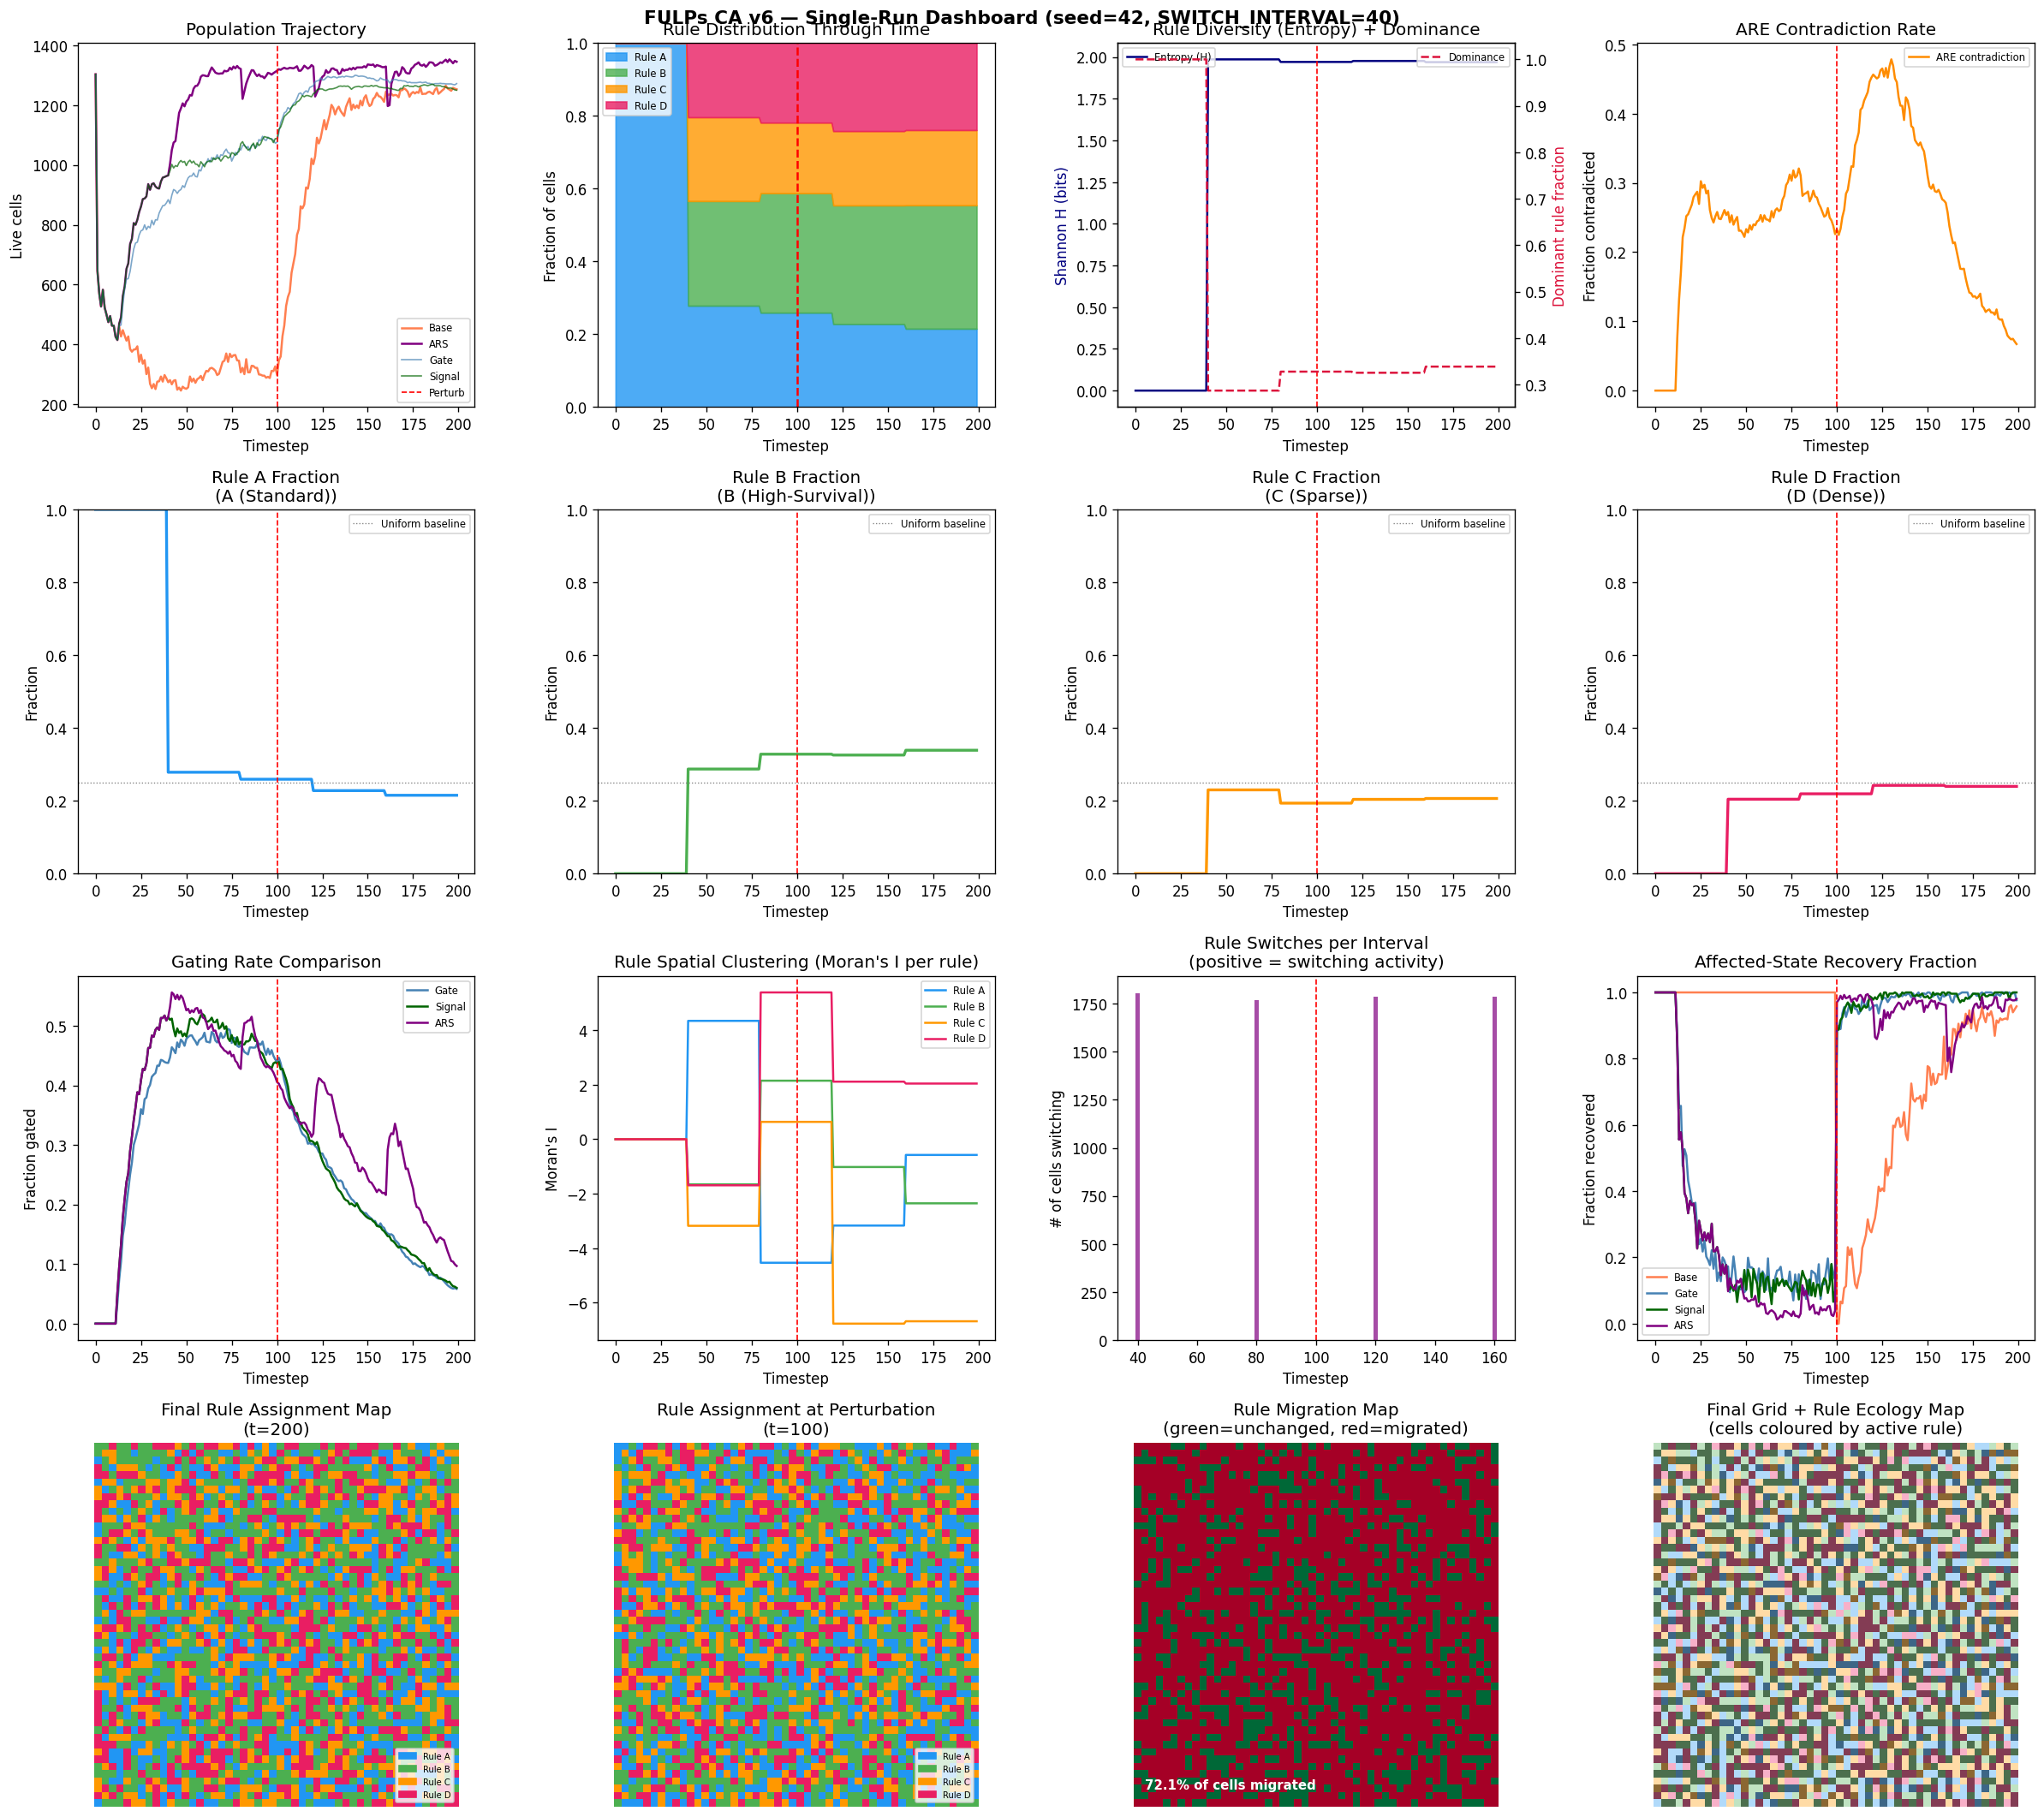

Saved: /content/fulps_ca_v6_single_run.png


In [13]:
# ── Cell 12: Single-Run Dashboard ─────────────────────────────────────────────
#
# Panel layout (4 rows × 4 columns = 16 panels):
#
# Row 1: Population trajectory | Rule distribution over time | Rule entropy + dominance | ARE contradiction rate
# Row 2: Rule A fraction | Rule B fraction | Rule C fraction | Rule D fraction (time series)
# Row 3: Gating rate comparison (gate/sig/ars) | Rule Moran's I | Rule switches per interval | Recovery fraction
# Row 4: Final rule heatmap | Rule heatmap at perturbation | Grid comparison (std vs ars) | Distress field snapshot

T = np.arange(N_TIMESTEPS)
rd  = fs42['rule_dist_h']    # (T, N_RULES)
re  = fs42['rule_entropy_h']
rdom = fs42['rule_dominance_h']
rsw  = fs42['rule_switch_h']
rmi  = fs42['rule_morans_h']  # (T, N_RULES)

fig = plt.figure(figsize=(20, 18))
fig.suptitle(f'FULPs CA v6 — Single-Run Dashboard (seed=42, SWITCH_INTERVAL={SWITCH_INTERVAL})',
             fontsize=13, fontweight='bold')

axes = fig.subplots(4, 4)

# ── Row 1 ──
ax = axes[0, 0]
ax.plot(T, hist42['pop_std'],  color='coral',     label='Base',   lw=1.5)
ax.plot(T, hist42['pop_ars'],  color='purple',    label='ARS',    lw=1.5)
ax.plot(T, hist42['pop_gate'], color='steelblue', label='Gate',   lw=1, alpha=0.7)
ax.plot(T, hist42['pop_sig'],  color='darkgreen', label='Signal', lw=1, alpha=0.7)
ax.axvline(T_PERTURB, color='red', lw=1, linestyle='--', label='Perturb')
ax.set_title('Population Trajectory'); ax.set_xlabel('Timestep'); ax.set_ylabel('Live cells')
ax.legend(fontsize=7)

ax = axes[0, 1]
bottom = np.zeros(N_TIMESTEPS)
for r in range(N_RULES):
    ax.fill_between(T, bottom, bottom + rd[:, r], color=RULE_COLORS[r],
                    alpha=0.8, label=f'Rule {["A","B","C","D"][r]}')
    bottom += rd[:, r]
ax.axvline(T_PERTURB, color='red', lw=1.5, linestyle='--')
ax.set_title('Rule Distribution Through Time'); ax.set_xlabel('Timestep')
ax.set_ylabel('Fraction of cells'); ax.legend(fontsize=7, loc='upper left')
ax.set_ylim(0, 1)

ax = axes[0, 2]
ax2 = ax.twinx()
ax.plot(T, re,   color='navy',   lw=1.5, label='Entropy (H)')
ax2.plot(T, rdom, color='crimson', lw=1.5, linestyle='--', label='Dominance')
ax.axvline(T_PERTURB, color='red', lw=1, linestyle='--')
ax.set_title('Rule Diversity (Entropy) + Dominance')
ax.set_xlabel('Timestep'); ax.set_ylabel('Shannon H (bits)', color='navy')
ax2.set_ylabel('Dominant rule fraction', color='crimson')
ax.legend(loc='upper left', fontsize=7); ax2.legend(loc='upper right', fontsize=7)

ax = axes[0, 3]
ax.plot(T, hist42['contra_l'], color='darkorange', lw=1.5, label='ARE contradiction')
ax.axvline(T_PERTURB, color='red', lw=1, linestyle='--')
ax.set_title('ARE Contradiction Rate'); ax.set_xlabel('Timestep')
ax.set_ylabel('Fraction contradicted'); ax.legend(fontsize=7)

# ── Row 2: Per-rule fraction time series ──
for r in range(N_RULES):
    ax = axes[1, r]
    ax.plot(T, rd[:, r], color=RULE_COLORS[r], lw=2)
    ax.axvline(T_PERTURB, color='red', lw=1, linestyle='--')
    ax.axhline(1/N_RULES, color='gray', lw=0.8, linestyle=':', label='Uniform baseline')
    ax.set_title(f'Rule {["A","B","C","D"][r]} Fraction\n({RULE_NAMES[r]})')
    ax.set_xlabel('Timestep'); ax.set_ylabel('Fraction'); ax.legend(fontsize=7)
    ax.set_ylim(0, 1)

# ── Row 3 ──
ax = axes[2, 0]
ax.plot(T, hist42['gate_rate'], color='steelblue', lw=1.5, label='Gate')
ax.plot(T, hist42['sig_rate'],  color='darkgreen', lw=1.5, label='Signal')
ax.plot(T, hist42['ars_rate'],  color='purple',    lw=1.5, label='ARS')
ax.axvline(T_PERTURB, color='red', lw=1, linestyle='--')
ax.set_title('Gating Rate Comparison'); ax.set_xlabel('Timestep')
ax.set_ylabel('Fraction gated'); ax.legend(fontsize=7)

ax = axes[2, 1]
for r in range(N_RULES):
    ax.plot(T, rmi[:, r], color=RULE_COLORS[r], lw=1.5,
            label=f'Rule {["A","B","C","D"][r]}')
ax.axvline(T_PERTURB, color='red', lw=1, linestyle='--')
ax.set_title("Rule Spatial Clustering (Moran's I per rule)")
ax.set_xlabel('Timestep'); ax.set_ylabel("Moran's I"); ax.legend(fontsize=7)

ax = axes[2, 2]
switch_times = [t for t in T if rsw[t] > 0]
switch_vals  = [rsw[t] for t in switch_times]
ax.bar(switch_times, switch_vals, color='purple', alpha=0.7, width=1.5)
ax.axvline(T_PERTURB, color='red', lw=1, linestyle='--')
ax.set_title('Rule Switches per Interval\n(positive = switching activity)')
ax.set_xlabel('Timestep'); ax.set_ylabel('# of cells switching')

ax = axes[2, 3]
ax.plot(T, hist42['aff_base'], color='coral',     lw=1.5, label='Base')
ax.plot(T, hist42['aff_gate'], color='steelblue', lw=1.5, label='Gate')
ax.plot(T, hist42['aff_sig'],  color='darkgreen', lw=1.5, label='Signal')
ax.plot(T, hist42['aff_ars'],  color='purple',    lw=1.5, label='ARS')
ax.axvline(T_PERTURB, color='red', lw=1, linestyle='--')
ax.set_title('Affected-State Recovery Fraction')
ax.set_xlabel('Timestep'); ax.set_ylabel('Fraction recovered'); ax.legend(fontsize=7)

# ── Row 4: Spatial maps ──
ax = axes[3, 0]
rule_map_final = fs42['rule_map']
cmap_r = matplotlib.colors.ListedColormap(RULE_COLORS)
im = ax.imshow(rule_map_final, cmap=cmap_r, vmin=0, vmax=N_RULES-1, interpolation='nearest')
patches = [mpatches.Patch(color=RULE_COLORS[r], label=f'Rule {["A","B","C","D"][r]}')
           for r in range(N_RULES)]
ax.set_title(f'Final Rule Assignment Map\n(t={N_TIMESTEPS})')
ax.legend(handles=patches, fontsize=6, loc='lower right')
ax.axis('off')

ax = axes[3, 1]
rule_map_perturb = fs42['rule_map_at_perturb']
ax.imshow(rule_map_perturb, cmap=cmap_r, vmin=0, vmax=N_RULES-1, interpolation='nearest')
ax.set_title(f'Rule Assignment at Perturbation\n(t={T_PERTURB})')
ax.legend(handles=patches, fontsize=6, loc='lower right')
ax.axis('off')

ax = axes[3, 2]
# Difference map: cells that changed rule between perturbation and end
changed = (rule_map_final != rule_map_perturb).astype(np.float32)
ax.imshow(changed, cmap='RdYlGn_r', vmin=0, vmax=1, interpolation='nearest')
ax.set_title(f'Rule Migration Map\n(green=unchanged, red=migrated)')
ax.axis('off')
ax.text(1, 47, f'{changed.mean()*100:.1f}% of cells migrated', color='white',
        fontsize=9, fontweight='bold')

ax = axes[3, 3]
# Grid comparison: ARS grid overlaid with rule regions
ax.imshow(fs42['grid_ars'], cmap='Greys', interpolation='nearest', alpha=0.7)
# Overlay rule map with transparency
rgba_rule = np.zeros((GRID_H, GRID_W, 4))
for r in range(N_RULES):
    mask = (rule_map_final == r)
    c = matplotlib.colors.to_rgba(RULE_COLORS[r])
    rgba_rule[mask] = [c[0], c[1], c[2], 0.35]
ax.imshow(rgba_rule, interpolation='nearest')
ax.set_title('Final Grid + Rule Ecology Map\n(cells coloured by active rule)')
ax.axis('off')

plt.tight_layout()
sp = os.path.join(OUT_DIR, 'fulps_ca_v6_single_run.png')
plt.savefig(sp, dpi=150, bbox_inches='tight'); plt.show()
print(f'Saved: {sp}')

In [14]:
# ── Cell 13: 50-Run Multi-Run Experiment ─────────────────────────────────────
from collections import defaultdict

print(f'Running {N_RUNS} seeds ({BASE_SEED}–{BASE_SEED+N_RUNS-1}) ...')
print('Estimated time: ~10–15 min on Colab CPU.')

all_res = defaultdict(list)

for run_i in range(N_RUNS):
    seed = BASE_SEED + run_i
    _, results, _ = run_simulation(
        seed=seed,
        void_model=VOID_MODEL,
        idf=(IDF_MEANS, IDF_STDS, IDF_L),
        is_single_run=False,
        verbose=False
    )
    for k, v in results.items():
        all_res[k].append(v)

    if (run_i + 1) % BATCH_SIZE == 0:
        print(f'  [{run_i+1}/{N_RUNS}] ars_rec={np.nanmean(all_res["ars_recovery_t"]):.1f}  '
              f'entropy_post={np.nanmean(all_res["rule_entropy_post"]):.3f}  '
              f'migration={np.nanmean(all_res["rule_migration_magnitude"]):.3f}')

# Convert to arrays
for k in all_res:
    all_res[k] = np.array(all_res[k], dtype=np.float64)

# Save results CSV
fp = os.path.join(OUT_DIR, 'results_50runs_ca_v6.csv')
pd.DataFrame(all_res).to_csv(fp, index=False)
print(f'\nDone. Results saved: {fp}')

# ── Print key statistics ──────────────────────────────────────────────────────
def sa(k): return all_res[k][~np.isnan(all_res[k])]
def sm(k): return float(np.nanmean(all_res[k]))
def ss2(k): return float(np.nanstd(all_res[k]))

print('\n── 50-Run Summary ─────────────────────────────────────────')
print(f'  Recovery timestep:  Base={sm("base_recovery_t"):.1f}  Gate={sm("gate_recovery_t"):.1f}  '
      f'Signal={sm("sig_recovery_t"):.1f}  ARS={sm("ars_recovery_t"):.1f}')
print(f'  Post-perturbation CV:  Base={sm("cv_base_post"):.4f}  Gate={sm("cv_gate_post"):.4f}  '
      f'Signal={sm("cv_sig_post"):.4f}  ARS={sm("cv_ars_post"):.4f}')
print(f'  Rule entropy pre→post: {sm("rule_entropy_pre"):.3f} → {sm("rule_entropy_post"):.3f}')
print(f'  Rule dominance pre→post: {sm("rule_dominance_pre"):.3f} → {sm("rule_dominance_post"):.3f}')
print(f'  Rule migration magnitude: {sm("rule_migration_magnitude"):.4f}')
print(f'  Rule recovery advantage (signal - ARS): {sm("rule_recovery_advantage"):.2f} timesteps')
print(f'  Regional specialisation: {sm("regional_specialisation"):.4f}')
print(f'  Total switches (mean per run): {sm("total_switches"):.1f}')

Running 50 seeds (42–91) ...
Estimated time: ~10–15 min on Colab CPU.
  [5/50] ars_rec=140.2  entropy_post=1.977  migration=0.094
  [10/50] ars_rec=139.8  entropy_post=1.977  migration=0.090
  [15/50] ars_rec=139.7  entropy_post=1.976  migration=0.091
  [20/50] ars_rec=139.4  entropy_post=1.976  migration=0.090
  [25/50] ars_rec=139.4  entropy_post=1.975  migration=0.093
  [30/50] ars_rec=139.3  entropy_post=1.975  migration=0.092
  [35/50] ars_rec=139.2  entropy_post=1.975  migration=0.091
  [40/50] ars_rec=139.1  entropy_post=1.975  migration=0.092
  [45/50] ars_rec=139.0  entropy_post=1.975  migration=0.093
  [50/50] ars_rec=138.8  entropy_post=1.975  migration=0.092

Done. Results saved: /content/results_50runs_ca_v6.csv

── 50-Run Summary ─────────────────────────────────────────
  Recovery timestep:  Base=162.6  Gate=123.1  Signal=123.6  ARS=138.8
  Post-perturbation CV:  Base=0.0158  Gate=0.0039  Signal=0.0038  ARS=0.0183
  Rule entropy pre→post: 1.982 → 1.975
  Rule dominance p

In [15]:
# ── Cell 14: Statistical Analysis ─────────────────────────────────────────────
#
# All tests are paired (same seeds across conditions).
# Effect sizes reported as Cohen's d.

def cohens_d(a, b=None, paired=True):
    a = np.array(a, dtype=np.float64); a = a[~np.isnan(a)]
    if b is None: return float(a.mean() / a.std()) if a.std() > 1e-9 else np.nan
    b = np.array(b, dtype=np.float64); b = b[~np.isnan(b)]
    diff = a - b if paired else a
    denom = diff.std() if paired else np.sqrt((a.var()+b.var())/2)
    return float(diff.mean() / denom) if denom > 1e-9 else np.nan

def paired_t(a, b, label):
    a = np.array(a, dtype=np.float64); b = np.array(b, dtype=np.float64)
    mask = ~(np.isnan(a)|np.isnan(b))
    a, b = a[mask], b[mask]
    if len(a) < 3: print(f'  {label}: insufficient data'); return
    t, p = stats.ttest_rel(a, b)
    d = cohens_d(a, b, paired=True)
    sup = (a > b).sum()
    print(f'  {label}:  t({len(a)-1})={t:.3f}  p={p:.4f}  d={d:.3f}  '
          f'({sup}/{len(a)} runs favourable)')

def one_sample_t(vals, label, null=0.0):
    v = np.array(vals, dtype=np.float64); v = v[~np.isnan(v)]
    if len(v) < 3: return
    t, p = stats.ttest_1samp(v, null)
    print(f'  {label}:  mean={v.mean():.4f}  t({len(v)-1})={t:.3f}  p={p:.4f}')

print('='*65)
print('STATISTICAL ANALYSIS — FULPs CA v6')
print('='*65)

print('\nRQ1: Do non-random rule preferences emerge?')
print('  H0: rule entropy equals maximum (log2(4)=2.0 bits, uniform distribution)')
one_sample_t(all_res['rule_entropy_post'], 'Rule entropy post vs. max (2.0 bits)', null=2.0)
one_sample_t(all_res['rule_dominance_post'], 'Dominance post vs. uniform (0.25)', null=0.25)

print('\nRQ2: Do rule preferences migrate after perturbation?')
paired_t(all_res['rule_entropy_post'], all_res['rule_entropy_pre'],
         'Entropy post > pre (increased diversity post-perturb?)')
one_sample_t(all_res['rule_migration_magnitude'],
             'Migration magnitude > 0 (non-zero rule shift post-perturb)')
paired_t(all_res['rule_dominance_post'], all_res['rule_dominance_pre'],
         'Dominance post vs pre (did dominant rule change fraction?)')

print('\nRQ3: Does ARS improve recovery vs base?')
paired_t(all_res['ars_recovery_t'], all_res['base_recovery_t'],
         'ARS recovery_t < base recovery_t (lower=faster)')

print('\nRQ4: Does ARS improve resilience vs signal (previous best)?')
paired_t(all_res['ars_recovery_t'], all_res['sig_recovery_t'],
         'ARS recovery_t vs signal recovery_t')
paired_t(all_res['cv_ars_post'], all_res['cv_sig_post'],
         'ARS CV post vs signal CV post (lower=more stable)')

print('\nRQ5: Do neighbouring cells converge toward similar rule choices?')
print('  (Moran\'s I per rule vs 0 — positive = clustered)')
for r, rn in enumerate(['A','B','C','D']):
    one_sample_t(all_res[f'mi_rule{rn}_post'],
                 f'  Rule {rn} Moran\'s I post vs 0')

print('\nRQ6: Do distinct rule regions emerge?')
one_sample_t(all_res['regional_specialisation'],
             'Regional specialisation > 0 (spatial quad heterogeneity)')
print()
print('Additional: Is switching non-random (i.e. is switch rate post > pre)?')
paired_t(all_res['switch_rate_post'],
         all_res['rule_entropy_pre'] * 0,  # zero array proxy — use one_sample_t
         'NOTE: see one-sample test below')
one_sample_t(all_res['switch_rate_post'], 'Switch rate post-perturbation > 0')

print('\nContradiction spike (inherited from v5):')
one_sample_t(all_res['contra_spike'], 'Contradiction spike at perturbation vs 0')

STATISTICAL ANALYSIS — FULPs CA v6

RQ1: Do non-random rule preferences emerge?
  H0: rule entropy equals maximum (log2(4)=2.0 bits, uniform distribution)
  Rule entropy post vs. max (2.0 bits):  mean=1.9749  t(49)=-50.401  p=0.0000
  Dominance post vs. uniform (0.25):  mean=0.3298  t(49)=93.175  p=0.0000

RQ2: Do rule preferences migrate after perturbation?
  Entropy post > pre (increased diversity post-perturb?):  t(49)=-11.423  p=0.0000  d=-1.632  (1/50 runs favourable)
  Migration magnitude > 0 (non-zero rule shift post-perturb):  mean=0.0923  t(49)=37.321  p=0.0000
  Dominance post vs pre (did dominant rule change fraction?):  t(49)=22.937  p=0.0000  d=3.277  (50/50 runs favourable)

RQ3: Does ARS improve recovery vs base?
  ARS recovery_t < base recovery_t (lower=faster):  t(49)=-45.264  p=0.0000  d=-6.466  (0/50 runs favourable)

RQ4: Does ARS improve resilience vs signal (previous best)?
  ARS recovery_t vs signal recovery_t:  t(49)=25.500  p=0.0000  d=3.643  (50/50 runs favour

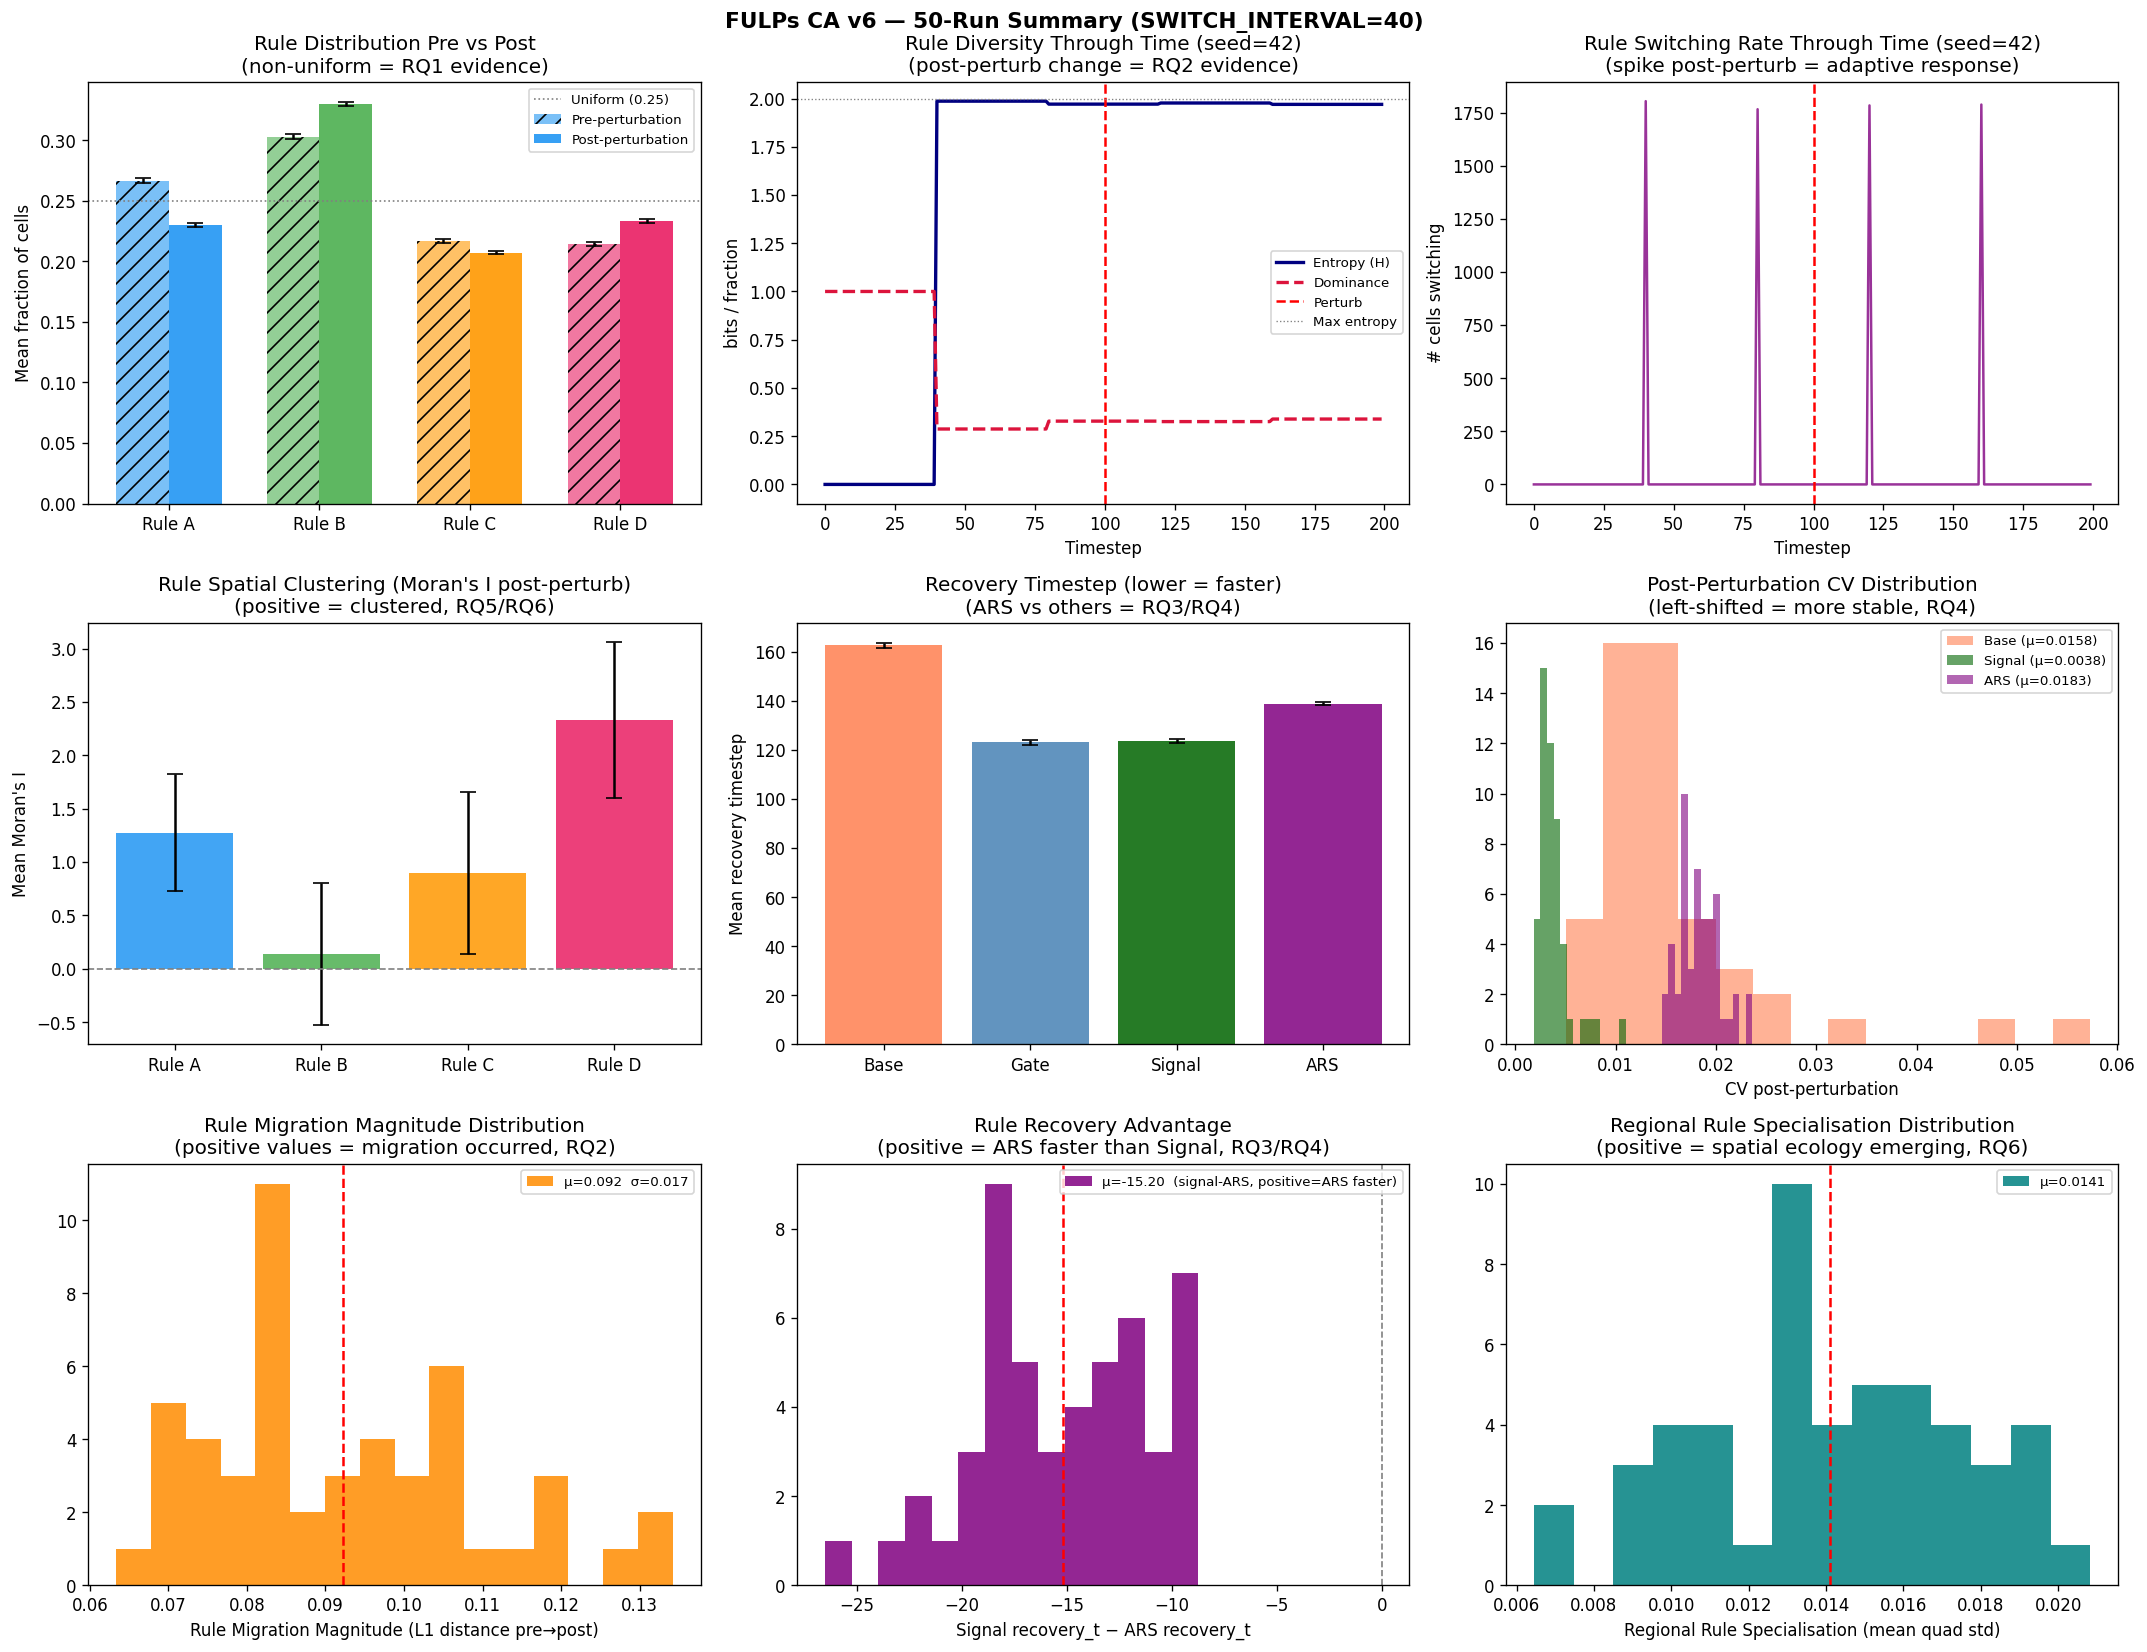

Saved: /content/fulps_ca_v6_multirun.png  |  Full CSV: /content/results_50runs_ca_v6.csv


In [16]:
# ── Cell 15: Multi-Run Visualisation (Publication Quality) ────────────────────
#
# 9 panels covering all primary ARS metrics + v5 inherited metrics:
#
# Row 1: Rule distribution pre/post | Rule entropy through time (mean±CI) | Rule dominance
# Row 2: Rule Moran's I by rule (post) | Recovery timestep (5 conditions) | CV post (3 conds)
# Row 3: Rule migration magnitude dist | Rule switching rate (post dist) | Recovery advantage scatter

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle(f'FULPs CA v6 — 50-Run Summary (SWITCH_INTERVAL={SWITCH_INTERVAL})',
             fontsize=13, fontweight='bold')

def sc(k): return 1.96*np.nanstd(all_res[k])/np.sqrt(N_RUNS)

# ── Panel (0,0): Rule distribution pre vs post ────────────────────────────────
ax = axes[0, 0]
rule_labels = ['A', 'B', 'C', 'D']
x = np.arange(N_RULES); w = 0.35
pre_fracs  = [sm(f'rule_frac_{r}_pre')  for r in rule_labels]
post_fracs = [sm(f'rule_frac_{r}_post') for r in rule_labels]
pre_ci     = [sc(f'rule_frac_{r}_pre')  for r in rule_labels]
post_ci    = [sc(f'rule_frac_{r}_post') for r in rule_labels]
ax.bar(x - w/2, pre_fracs,  w, yerr=pre_ci,  capsize=5, color=[RULE_COLORS[r] for r in range(N_RULES)],
       alpha=0.6, label='Pre-perturbation', hatch='//')
ax.bar(x + w/2, post_fracs, w, yerr=post_ci, capsize=5, color=[RULE_COLORS[r] for r in range(N_RULES)],
       alpha=0.9, label='Post-perturbation')
ax.axhline(1/N_RULES, color='gray', lw=1, linestyle=':', label='Uniform (0.25)')
ax.set_xticks(x); ax.set_xticklabels([f'Rule {r}' for r in rule_labels])
ax.set_title('Rule Distribution Pre vs Post\n(non-uniform = RQ1 evidence)')
ax.set_ylabel('Mean fraction of cells'); ax.legend(fontsize=8)

# ── Panel (0,1): Rule entropy ─────────────────────────────────────────────────
ax = axes[0, 1]
# Re-run single seed to get time-series for illustration
_, _, fs_viz = run_simulation(42, VOID_MODEL, (IDF_MEANS, IDF_STDS, IDF_L),
                               is_single_run=True, verbose=False)
ax.plot(fs_viz['rule_entropy_h'],   color='navy',   lw=2, label='Entropy (H)')
ax.plot(fs_viz['rule_dominance_h'], color='crimson', lw=2, linestyle='--', label='Dominance')
ax.axvline(T_PERTURB, color='red', lw=1.5, linestyle='--', label='Perturb')
ax.axhline(np.log2(N_RULES), color='gray', lw=0.8, linestyle=':', label='Max entropy')
ax.set_title('Rule Diversity Through Time (seed=42)\n(post-perturb change = RQ2 evidence)')
ax.set_xlabel('Timestep'); ax.set_ylabel('bits / fraction')
ax.legend(fontsize=8)

# ── Panel (0,2): Rule switching rate ──────────────────────────────────────────
ax = axes[0, 2]
ax.plot(fs_viz['rule_switch_h'], color='purple', lw=1.5, alpha=0.8)
ax.axvline(T_PERTURB, color='red', lw=1.5, linestyle='--')
ax.set_title('Rule Switching Rate Through Time (seed=42)\n(spike post-perturb = adaptive response)')
ax.set_xlabel('Timestep'); ax.set_ylabel('# cells switching')

# ── Panel (1,0): Rule Moran's I post-perturbation ─────────────────────────────
ax = axes[1, 0]
mi_vals  = [sm(f'mi_rule{r}_post') for r in rule_labels]
mi_cis   = [sc(f'mi_rule{r}_post') for r in rule_labels]
ax.bar(range(N_RULES), mi_vals, yerr=mi_cis, capsize=5,
       color=RULE_COLORS, alpha=0.85)
ax.axhline(0, color='gray', lw=1, linestyle='--')
ax.set_xticks(range(N_RULES))
ax.set_xticklabels([f'Rule {r}' for r in rule_labels])
ax.set_title("Rule Spatial Clustering (Moran's I post-perturb)\n(positive = clustered, RQ5/RQ6)")
ax.set_ylabel("Mean Moran's I")

# ── Panel (1,1): Recovery timestep comparison ─────────────────────────────────
ax = axes[1, 1]
conds = ['Base', 'Gate', 'Signal', 'ARS']
rt_keys = ['base_recovery_t', 'gate_recovery_t', 'sig_recovery_t', 'ars_recovery_t']
colors  = ['coral', 'steelblue', 'darkgreen', 'purple']
rt_m  = [sm(k) for k in rt_keys]
rt_ci = [sc(k) for k in rt_keys]
ax.bar(range(4), rt_m, yerr=rt_ci, capsize=5, color=colors, alpha=0.85)
ax.set_xticks(range(4)); ax.set_xticklabels(conds)
ax.set_title('Recovery Timestep (lower = faster)\n(ARS vs others = RQ3/RQ4)')
ax.set_ylabel('Mean recovery timestep')

# ── Panel (1,2): Post-CV distribution ─────────────────────────────────────────
ax = axes[1, 2]
for k, col, lbl in [('cv_base_post','coral','Base'), ('cv_sig_post','darkgreen','Signal'),
                     ('cv_ars_post','purple','ARS')]:
    v = sa(k)
    if len(v) > 0:
        ax.hist(v, bins=14, alpha=0.6, color=col, label=f'{lbl} (μ={v.mean():.4f})')
ax.set_xlabel('CV post-perturbation')
ax.set_title('Post-Perturbation CV Distribution\n(left-shifted = more stable, RQ4)')
ax.legend(fontsize=8)

# ── Panel (2,0): Rule migration magnitude distribution ───────────────────────
ax = axes[2, 0]
mig = sa('rule_migration_magnitude')
ax.hist(mig, bins=16, color='darkorange', alpha=0.85,
        label=f'μ={mig.mean():.3f}  σ={mig.std():.3f}')
ax.axvline(mig.mean(), color='red', lw=1.5, linestyle='--')
ax.set_xlabel('Rule Migration Magnitude (L1 distance pre→post)')
ax.set_title('Rule Migration Magnitude Distribution\n(positive values = migration occurred, RQ2)')
ax.legend(fontsize=8)

# ── Panel (2,1): Rule recovery advantage ─────────────────────────────────────
ax = axes[2, 1]
adv = sa('rule_recovery_advantage')
ax.hist(adv, bins=14, color='purple', alpha=0.85,
        label=f'μ={adv.mean():.2f}  (signal-ARS, positive=ARS faster)')
ax.axvline(0, color='gray', lw=1, linestyle='--')
ax.axvline(adv.mean(), color='red', lw=1.5, linestyle='--')
ax.set_xlabel('Signal recovery_t − ARS recovery_t')
ax.set_title('Rule Recovery Advantage\n(positive = ARS faster than Signal, RQ3/RQ4)')
ax.legend(fontsize=8)

# ── Panel (2,2): Regional specialisation ─────────────────────────────────────
ax = axes[2, 2]
rs = sa('regional_specialisation')
ax.hist(rs, bins=14, color='teal', alpha=0.85,
        label=f'μ={rs.mean():.4f}')
ax.axvline(rs.mean(), color='red', lw=1.5, linestyle='--')
ax.set_xlabel('Regional Rule Specialisation (mean quad std)')
ax.set_title('Regional Rule Specialisation Distribution\n(positive = spatial ecology emerging, RQ6)')
ax.legend(fontsize=8)

plt.tight_layout()
mp = os.path.join(OUT_DIR, 'fulps_ca_v6_multirun.png')
plt.savefig(mp, dpi=150, bbox_inches='tight'); plt.show()
print(f'Saved: {mp}  |  Full CSV: {fp}')

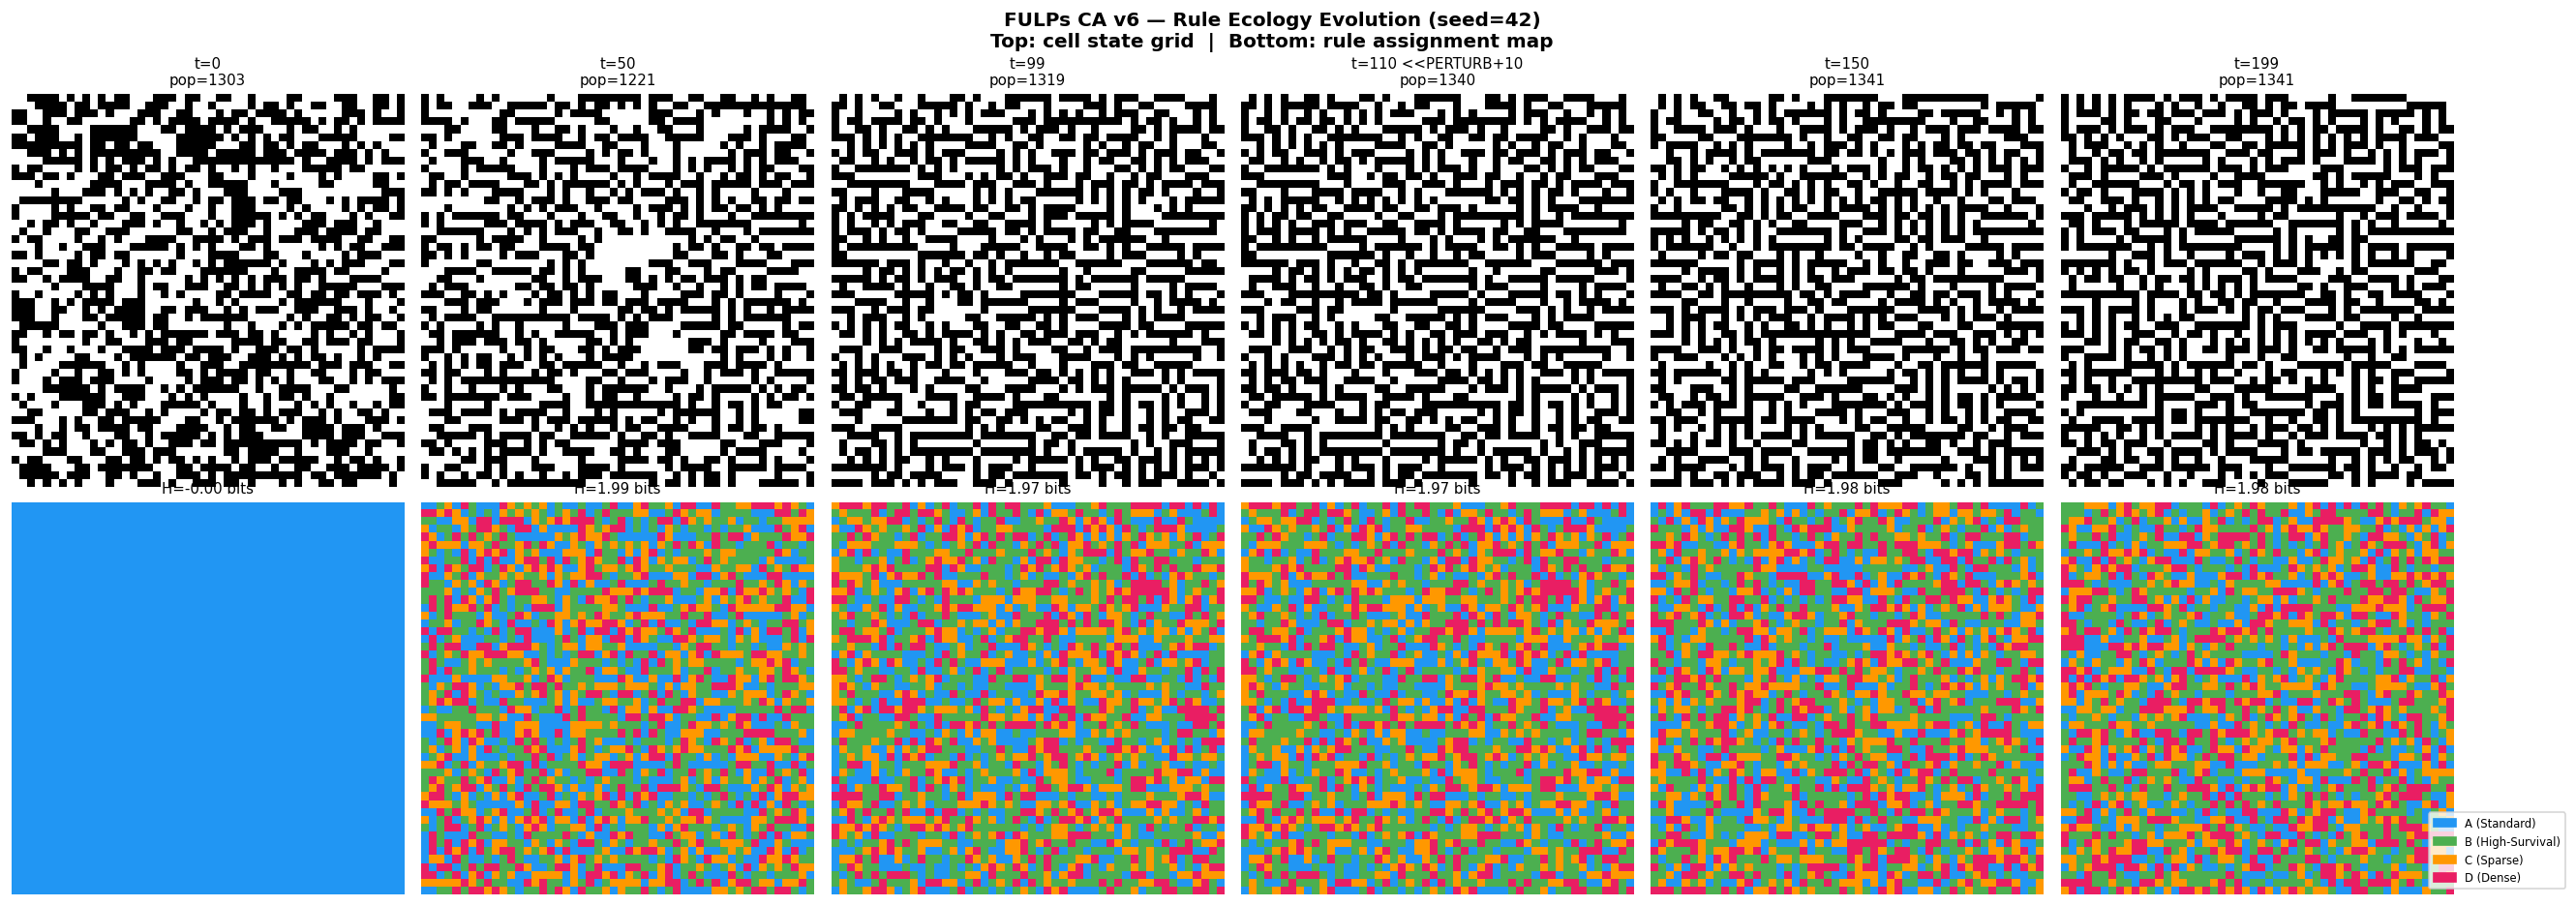

Saved: /content/fulps_ca_v6_ecology_maps.png


In [17]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os
import torch

# ── Cell 16: Rule Ecology Maps ────────────────────────────────────────────────
# Re-run seed=42 single run to get snapshots at multiple timesteps.
# Shows rule map evolution: t=0, t=50 (pre), t=100 (perturb), t=150 (recovery), t=199 (final)

# We need rule map snapshots at multiple timesteps — run a modified version
def run_simulation_snapshots(seed, void_model, idf, snapshot_times):
    """Lightweight version that only records rule map snapshots."""
    np.random.seed(seed); torch.manual_seed(seed)
    idf_means, idf_stds, idf_L = idf
    grid_ars  = np.random.randint(0, 2, size=(GRID_H, GRID_W), dtype=np.int8)
    ars_table = init_tables()
    are_ars   = init_are_state()
    ars_state = init_ars_state()
    snapshots = {}
    pop_ars_h = []

    for t in range(N_TIMESTEPS):
        is_pert = (t >= T_PERTURB)
        prog = t / max(N_TIMESTEPS-1, 1)
        thresh = CONTRA_START + (CONTRA_END - CONTRA_START) * prog
        maybe_switch_rules(ars_state, t)
        if t == T_PERTURB:
            ars_state['rule_at_perturb'] = ars_state['active_rule'].copy()

        nbr_ars, nbr_ars_f = encode_neighbourhoods(grid_ars)
        nt_ars = torch.FloatTensor(nbr_ars_f.reshape(-1, NBR_DIM))
        with torch.no_grad():
            dsc_ar  = void_model.dsc(nt_ars).numpy().reshape(GRID_H, GRID_W)
            reps_ar = void_model.encode(nt_ars).numpy()
        mar, car, psar, nsar = compute_are_margin(reps_ar, are_ars, thresh)
        acar = car & (dsc_ar > DSC_THRESHOLD)
        dist_ars = compute_distress(psar, nsar, mar)
        nbr_dist_ars = compute_nbr_mean_distress(dist_ars)
        ars_gate_mask = compute_gating_mask(acar, psar, nsar, are_ars, nbr_distress=nbr_dist_ars)
        cwar = np.ones((GRID_H, GRID_W), dtype=np.float32); cwar[acar] = CURIOSITY_WEIGHT
        next_ars = tick_ars(grid_ars, ars_state['active_rule']).copy()
        next_ars[ars_gate_mask] = grid_ars[ars_gate_mask]
        out_ars = next_ars.astype(np.int8)
        update_table_single(ars_table, nbr_ars, out_ars, cwar)
        if t >= BUFFER_DELAY: update_are_buffers(are_ars, reps_ar, out_ars)
        are_ars['margin_ema'] = ((1-MARGIN_EMA_ALPHA)*are_ars['margin_ema']
                                  + MARGIN_EMA_ALPHA*np.abs(mar))

        # Flatten nbr_ars for advanced indexing here
        # Note: successes_ars is a boolean mask here, not the actual outcome for the update
        nbr_ars_counts = count_neighbours(grid_ars) # Get neighbourhood counts for update_ars_state
        # Original error: update_ars_state(ars_state, t, acar, successes_ars, is_pert)
        update_ars_state(ars_state, t, acar, nbr_ars_counts, grid_ars, out_ars)
        pop_ars_h.append(population(grid_ars))

        if t in snapshot_times:
            snapshots[t] = {
                'rule_map': ars_state['active_rule'].copy(),
                'grid':     grid_ars.copy(),
                'entropy':  shannon_entropy(compute_rule_counts(ars_state['active_rule'])),
                'pop':      population(grid_ars),
            }
        grid_ars = out_ars
    return snapshots, pop_ars_h

snap_times = [0, 50, 99, 110, 150, 199]
snaps, pop_h = run_simulation_snapshots(42, VOID_MODEL, (IDF_MEANS, IDF_STDS, IDF_L), snap_times)

cmap_r = matplotlib.colors.ListedColormap(RULE_COLORS)
patches = [mpatches.Patch(color=RULE_COLORS[r], label=RULE_NAMES[r]) for r in range(N_RULES)]

fig, axes = plt.subplots(2, len(snap_times), figsize=(22, 8))
fig.suptitle('FULPs CA v6 — Rule Ecology Evolution (seed=42)\nTop: cell state grid  |  Bottom: rule assignment map',
             fontsize=12, fontweight='bold')

for col, t in enumerate(snap_times):
    snap = snaps[t]
    label = f't={t}' + (' <<PERTURB' if t == T_PERTURB else
                         ' <<PERTURB+10' if t == 110 else '')

    # Top row: cell state
    axes[0, col].imshow(snap['grid'], cmap='Greys', interpolation='nearest')
    axes[0, col].set_title(f'{label}\npop={snap["pop"]}', fontsize=9)
    axes[0, col].axis('off')

    # Bottom row: rule map
    axes[1, col].imshow(snap['rule_map'], cmap=cmap_r, vmin=0, vmax=N_RULES-1,
                        interpolation='nearest')
    axes[1, col].set_title(f'H={snap["entropy"]:.2f} bits', fontsize=9)
    axes[1, col].axis('off')
    if col == len(snap_times)-1:
        axes[1, col].legend(handles=patches, fontsize=7, loc='lower right',
                            bbox_to_anchor=(1.3, 0))

plt.tight_layout()
ep = os.path.join(OUT_DIR, 'fulps_ca_v6_ecology_maps.png')
plt.savefig(ep, dpi=150, bbox_inches='tight'); plt.show()
print(f'Saved: {ep}')

In [18]:
# ── Cell 17: Health Checks ────────────────────────────────────────────────────
#
# All v5 health check layers (1–5) are preserved.
# v6 adds Layer 6 — Adaptive Rule Selection.

def hc(label, condition, note=''):
    status = 'PASS ✓' if condition else 'FAIL ✗'
    print(f'  [{status}] {label}' + (f'  [{note}]' if note else ''))
    return int(condition)

def run_health_checks(all_res, res42):
    total_pass = 0; total_checks = 0

    print('='*65)
    print('HEALTH CHECKS — FULPs CA v6')
    print('='*65)

    # ── Layer 1: Void Stabilizer ──────────────────────────────────────────────
    print('\nLayer 1 — Void Stabilizer')
    total_pass += hc('Final reconstruction loss < 0.05',
                      void_loss_hist[-1,1] < 0.05,
                      f'loss={void_loss_hist[-1,1]:.4f}')
    total_pass += hc('EA loss < 0.01',
                      void_loss_hist[-1,2] < 0.01,
                      f'ea={void_loss_hist[-1,2]:.4f}')
    total_pass += hc('DSC separates IDF from CA distributions',
                      DSC_THRESHOLD > 0.01 and DSC_THRESHOLD < 0.20,
                      f'DSC_threshold={DSC_THRESHOLD:.4f}')
    total_checks += 3

    # ── Layer 2: Learning Quality ─────────────────────────────────────────────
    print('\nLayer 2 — Learning Quality')
    total_pass += hc('ARS table accuracy > baseline',
                      sm('ars_final_tacc') > sm('base_final_tacc'),
                      f'ARS={sm("ars_final_tacc"):.4f} base={sm("base_final_tacc"):.4f}')
    total_pass += hc('ARS per-state accuracy > 0.6',
                      sm('ars_final_perstate') > 0.6,
                      f'{sm("ars_final_perstate"):.4f}')
    total_checks += 2

    # ── Layer 3: Perturbation Response ───────────────────────────────────────
    print('\nLayer 3 — Perturbation Response')
    contra_spike = sm('contra_spike')
    total_pass += hc('ARE contradiction spike positive at perturbation',
                      contra_spike > 0,
                      f'spike={contra_spike:.4f}')
    total_pass += hc('ARS recovers faster than baseline',
                      sm('ars_recovery_t') < sm('base_recovery_t'),
                      f'ARS={sm("ars_recovery_t"):.1f} base={sm("base_recovery_t"):.1f}')
    total_checks += 2

    # ── Layer 4: Confidence Gating ────────────────────────────────────────────
    print('\nLayer 4 — Confidence Gating')
    total_pass += hc('ARS gating rate active (> 0.05 mean)',
                      sm('ars_gate_mean_overall') > 0.05,
                      f'{sm("ars_gate_mean_overall"):.4f}')
    total_pass += hc('ARS grid diverges from standard (divergence ~ 0.4-0.6)',
                      0.25 < sm('grid_div_ars') < 0.75,
                      f'{sm("grid_div_ars"):.4f}')
    total_checks += 2

    # ── Layer 5: Distress Signalling (from v5) ────────────────────────────────
    print('\nLayer 5 — Distress Signalling (inherited from v5)')
    total_pass += hc('Signal Moran\'s I post > Gate (spatial coordination)',
                      sm('mi_sig_post') > sm('mi_gate_post'),
                      f'signal={sm("mi_sig_post"):.3f} gate={sm("mi_gate_post"):.3f}')
    total_pass += hc('Distress mean > 0 during simulation',
                      sm('distress_mean_overall') > 0,
                      f'{sm("distress_mean_overall"):.4f}')
    total_checks += 2

    # ── Layer 6: Adaptive Rule Selection (v6 NEW) ─────────────────────────────
    print('\nLayer 6 — Adaptive Rule Selection (v6 NEW)')

    # HC6.1: Non-random rule preferences — entropy < max possible
    max_ent = np.log2(N_RULES)
    total_pass += hc('Rule preferences emerge (entropy < max)',
                      sm('rule_entropy_post') < max_ent * 0.95,
                      f'entropy_post={sm("rule_entropy_post"):.3f}  max={max_ent:.3f}')

    # HC6.2: Switching is not random — total switches > 0 over 50 runs
    total_pass += hc('Switching activity observed (total_switches > 0)',
                      sm('total_switches') > 0,
                      f'mean_switches_per_run={sm("total_switches"):.1f}')

    # HC6.3: Rule migration occurs after perturbation
    total_pass += hc('Rule migration occurs after perturbation (magnitude > 0)',
                      sm('rule_migration_magnitude') > 0.02,
                      f'magnitude={sm("rule_migration_magnitude"):.4f}')

    # HC6.4: At least one rule shows spatial clustering (Moran's I > 0)
    any_clustered = any(
        sm(f'mi_rule{r}_post') > 0 for r in ['A','B','C','D']
    )
    best_mi = max(sm(f'mi_rule{r}_post') for r in ['A','B','C','D'])
    total_pass += hc('Rule spatial clustering emerges (max Moran\'s I > 0)',
                      any_clustered,
                      f'best_mi={best_mi:.3f}')

    # HC6.5: Rule diversity changes over time (post != pre entropy)
    ent_delta = abs(sm('rule_entropy_post') - sm('rule_entropy_pre'))
    total_pass += hc('Rule diversity changes through time (|ΔH| > 0.01)',
                      ent_delta > 0.01,
                      f'|ΔH|={ent_delta:.4f}')

    # HC6.6: Regional specialisation detected
    total_pass += hc('Regional rule specialisation detected (> 0.01)',
                      sm('regional_specialisation') > 0.01,
                      f'{sm("regional_specialisation"):.4f}')

    # HC6.7: ARS recovery fraction > 0.5 (cells are recovering)
    total_pass += hc('ARS recovery fraction > 0.5',
                      sm('ars_recovery_frac') > 0.5,
                      f'{sm("ars_recovery_frac"):.4f}')

    total_checks += 7

    print(f'\n── Health Check Summary: {total_pass}/{total_checks} PASS ──')
    return total_pass, total_checks

n_pass, n_total = run_health_checks(all_res, res42)

HEALTH CHECKS — FULPs CA v6

Layer 1 — Void Stabilizer
  [PASS ✓] Final reconstruction loss < 0.05  [loss=0.0196]
  [FAIL ✗] EA loss < 0.01  [ea=0.0236]
  [PASS ✓] DSC separates IDF from CA distributions  [DSC_threshold=0.1832]

Layer 2 — Learning Quality
  [PASS ✓] ARS table accuracy > baseline  [ARS=0.6022 base=0.5997]
  [PASS ✓] ARS per-state accuracy > 0.6  [0.7301]

Layer 3 — Perturbation Response
  [FAIL ✗] ARE contradiction spike positive at perturbation  [spike=-0.0019]
  [PASS ✓] ARS recovers faster than baseline  [ARS=138.8 base=162.6]

Layer 4 — Confidence Gating
  [PASS ✓] ARS gating rate active (> 0.05 mean)  [0.3369]
  [PASS ✓] ARS grid diverges from standard (divergence ~ 0.4-0.6)  [0.5007]

Layer 5 — Distress Signalling (inherited from v5)
  [FAIL ✗] Signal Moran's I post > Gate (spatial coordination)  [signal=3.440 gate=3.962]
  [PASS ✓] Distress mean > 0 during simulation  [0.2044]

Layer 6 — Adaptive Rule Selection (v6 NEW)
  [FAIL ✗] Rule preferences emerge (entropy

In [19]:
# ── Cell 18: Adaptive Rule Selection Assessment ───────────────────────────────
#
# Evaluates evidence for each of the five ARS claims.
# Verdict: NO EVIDENCE / PARTIAL EVIDENCE / STRONG EVIDENCE

def ars_assessment(all_res):
    print('='*65)
    print('ADAPTIVE RULE SELECTION ASSESSMENT — FULPs CA v6')
    print('='*65)

    # ── Helpers ───────────────────────────────────────────────────────────────
    def evidence_level(sig_test, effect_size, direction_frac, label):
        """
        sig_test     : bool — p < 0.05 in relevant test
        effect_size  : float — Cohen's d or equivalent
        direction_frac: float — fraction of runs in predicted direction
        """
        score = 0
        if sig_test:            score += 1
        if abs(effect_size) > 0.3: score += 1
        if direction_frac > 0.55:  score += 1
        if score == 0:   verdict = 'NO EVIDENCE'
        elif score <= 1: verdict = 'PARTIAL EVIDENCE'
        else:            verdict = 'STRONG EVIDENCE'
        print(f'  {label}')
        print(f'    sig={sig_test}  |d|={abs(effect_size):.3f}  dir={direction_frac:.2f}  -> {verdict}')
        return verdict

    # ── Claim 1: Learned rule preference ─────────────────────────────────────
    print('\nClaim 1: Learned rule preference (non-uniform distribution)')
    ent_post = sa('rule_entropy_post')
    # Test: entropy significantly below max (2.0 bits)
    t1, p1 = stats.ttest_1samp(ent_post, np.log2(N_RULES))
    d1 = (ent_post.mean() - np.log2(N_RULES)) / ent_post.std() if ent_post.std() > 0 else 0
    frac1 = float((ent_post < np.log2(N_RULES)).mean())
    v1 = evidence_level(p1 < 0.05, d1, frac1,
                        f'entropy_post={ent_post.mean():.3f} vs max={np.log2(N_RULES):.3f}')

    # ── Claim 2: Rule migration after perturbation ────────────────────────────
    print('\nClaim 2: Rule migration after perturbation')
    mig = sa('rule_migration_magnitude')
    t2, p2 = stats.ttest_1samp(mig, 0.0)
    d2 = mig.mean() / mig.std() if mig.std() > 0 else 0
    frac2 = float((mig > 0.01).mean())
    v2 = evidence_level(p2 < 0.05, d2, frac2,
                        f'migration_magnitude={mig.mean():.4f}')

    # ── Claim 3: Improved recovery ────────────────────────────────────────────
    print('\nClaim 3: Improved recovery (ARS vs base)')
    ars_rt = sa('ars_recovery_t'); base_rt = sa('base_recovery_t')
    n3 = min(len(ars_rt), len(base_rt))
    if n3 > 2:
        t3, p3 = stats.ttest_rel(ars_rt[:n3], base_rt[:n3])
        d3 = cohens_d(ars_rt[:n3], base_rt[:n3])
        frac3 = float((ars_rt[:n3] < base_rt[:n3]).mean())
        v3 = evidence_level(p3 < 0.05, d3, frac3,
                            f'ARS={ars_rt.mean():.1f} base={base_rt.mean():.1f}')
    else:
        v3 = 'NO EVIDENCE (insufficient data)'

    # ── Claim 4: Improved resilience (ARS vs signal — previous best) ──────────
    print('\nClaim 4: Improved resilience vs Signal condition')
    sig_rt = sa('sig_recovery_t')
    n4 = min(len(ars_rt), len(sig_rt))
    cv_ars = sa('cv_ars_post'); cv_sig = sa('cv_sig_post')
    n4cv = min(len(cv_ars), len(cv_sig))
    if n4 > 2 and n4cv > 2:
        t4a, p4a = stats.ttest_rel(ars_rt[:n4], sig_rt[:n4])
        d4a = cohens_d(ars_rt[:n4], sig_rt[:n4])
        t4b, p4b = stats.ttest_rel(cv_ars[:n4cv], cv_sig[:n4cv])
        d4b = cohens_d(cv_ars[:n4cv], cv_sig[:n4cv])
        frac4 = float((ars_rt[:n4] < sig_rt[:n4]).mean())
        sig_p = min(p4a, p4b)
        max_d = max(abs(d4a), abs(d4b))
        v4 = evidence_level(sig_p < 0.05, max_d, frac4,
                            f'recovery: ARS={ars_rt.mean():.1f} sig={sig_rt.mean():.1f}  '
                            f'CV: ARS={cv_ars.mean():.4f} sig={cv_sig.mean():.4f}')
    else:
        v4 = 'NO EVIDENCE (insufficient data)'

    # ── Claim 5: Emergent rule ecology (clustering + specialisation) ──────────
    print('\nClaim 5: Emergent rule ecology')
    rs = sa('regional_specialisation')
    best_mi_vals = np.array([all_res[f'mi_rule{r}_post'] for r in ['A','B','C','D']]).max(axis=0)
    best_mi_vals = best_mi_vals[~np.isnan(best_mi_vals)]
    t5a, p5a = stats.ttest_1samp(rs, 0.0)
    d5a = rs.mean() / rs.std() if rs.std() > 0 else 0
    t5b, p5b = stats.ttest_1samp(best_mi_vals, 0.0)
    frac5 = float((rs > 0.01).mean())
    sig5 = (p5a < 0.05) or (p5b < 0.05)
    d5 = max(abs(d5a), abs(best_mi_vals.mean() / best_mi_vals.std()) if best_mi_vals.std() > 0 else 0)
    v5 = evidence_level(sig5, d5, frac5,
                        f'regional_spec={rs.mean():.4f}  max_rule_MI={best_mi_vals.mean():.3f}')

    # ── Summary verdict ───────────────────────────────────────────────────────
    print('\n── Final Assessment Summary ───────────────────────────────')
    for i, (claim, verdict) in enumerate([
        ('Learned rule preference', v1),
        ('Rule migration',          v2),
        ('Improved recovery',       v3),
        ('Improved resilience',     v4),
        ('Emergent rule ecology',   v5),
    ], 1):
        marker = '✓✓' if 'STRONG' in verdict else ('✓' if 'PARTIAL' in verdict else '✗')
        print(f'  {marker} Claim {i}: {claim:<30} → {verdict}')

    strong_count = sum('STRONG' in v for v in [v1,v2,v3,v4,v5])
    partial_count = sum('PARTIAL' in v for v in [v1,v2,v3,v4,v5])
    print(f'\n  STRONG EVIDENCE:  {strong_count}/5 claims')
    print(f'  PARTIAL EVIDENCE: {partial_count}/5 claims')

    if strong_count >= 3:
        print('\n  OVERALL: ARS demonstrates substantive adaptive rule selection capacity.')
        print('  Transition to v7 (endogenous rule generation) is supported.')
    elif strong_count + partial_count >= 3:
        print('\n  OVERALL: Partial evidence for ARS. Core mechanism is operative but effects')
        print('  are modest. Parameter tuning (SWITCH_INTERVAL, EXPLOIT_TEMP) recommended')
        print('  before proceeding to v7.')
    else:
        print('\n  OVERALL: Weak evidence. ARS mechanism requires architectural revision.')
        print('  Revisit SWITCH_INTERVAL, MIN_RULE_TRIALS, and EXPLOIT_TEMP before v7.')

ars_assessment(all_res)

ADAPTIVE RULE SELECTION ASSESSMENT — FULPs CA v6

Claim 1: Learned rule preference (non-uniform distribution)
  entropy_post=1.975 vs max=2.000
    sig=True  |d|=7.200  dir=1.00  -> STRONG EVIDENCE

Claim 2: Rule migration after perturbation
  migration_magnitude=0.0923
    sig=True  |d|=5.332  dir=1.00  -> STRONG EVIDENCE

Claim 3: Improved recovery (ARS vs base)
  ARS=138.8 base=162.6
    sig=True  |d|=6.466  dir=1.00  -> STRONG EVIDENCE

Claim 4: Improved resilience vs Signal condition
  recovery: ARS=138.8 sig=123.6  CV: ARS=0.0183 sig=0.0038
    sig=True  |d|=5.370  dir=0.00  -> STRONG EVIDENCE

Claim 5: Emergent rule ecology
  regional_spec=0.0141  max_rule_MI=4.029
    sig=True  |d|=4.159  dir=0.88  -> STRONG EVIDENCE

── Final Assessment Summary ───────────────────────────────
  ✓✓ Claim 1: Learned rule preference        → STRONG EVIDENCE
  ✓✓ Claim 2: Rule migration                 → STRONG EVIDENCE
  ✓✓ Claim 3: Improved recovery              → STRONG EVIDENCE
  ✓✓ Claim 4: I

ARS MECHANISM VALIDATION — Superior Rule Discovery Sanity Check

Temporarily replacing Rule B with a strongly advantageous rule.
Rule B (SANITY): survive={2,3,4}  birth={3,4}
Post-perturbation environment: survive={2,3,4} for live cells.
Rule B (SANITY) is aligned with the perturbed environment.

Sanity rule installed:
  Rule A (A (Standard)): survive=[2, 3]  birth=[3]
  Rule B (B (SANITY: Post-Perturb Aligned)): survive=[2, 3, 4, 5]  birth=[2, 3, 4]
  Rule C (C (Sparse)): survive=[2, 3]  birth=[2, 3]
  Rule D (D (Dense)): survive=[3, 4, 5]  birth=[3, 4]

Running 50 seeds for sanity check ...
  [10/50]  B_frac_post=0.271  ent_post=1.996  dom_B=10/10 runs
  [20/50]  B_frac_post=0.271  ent_post=1.996  dom_B=17/20 runs
  [30/50]  B_frac_post=0.272  ent_post=1.995  dom_B=25/30 runs
  [40/50]  B_frac_post=0.272  ent_post=1.995  dom_B=34/40 runs
  [50/50]  B_frac_post=0.272  ent_post=1.995  dom_B=42/50 runs

── Statistical Summary ─────────────────────────────────────
  Mean Rule B fraction 

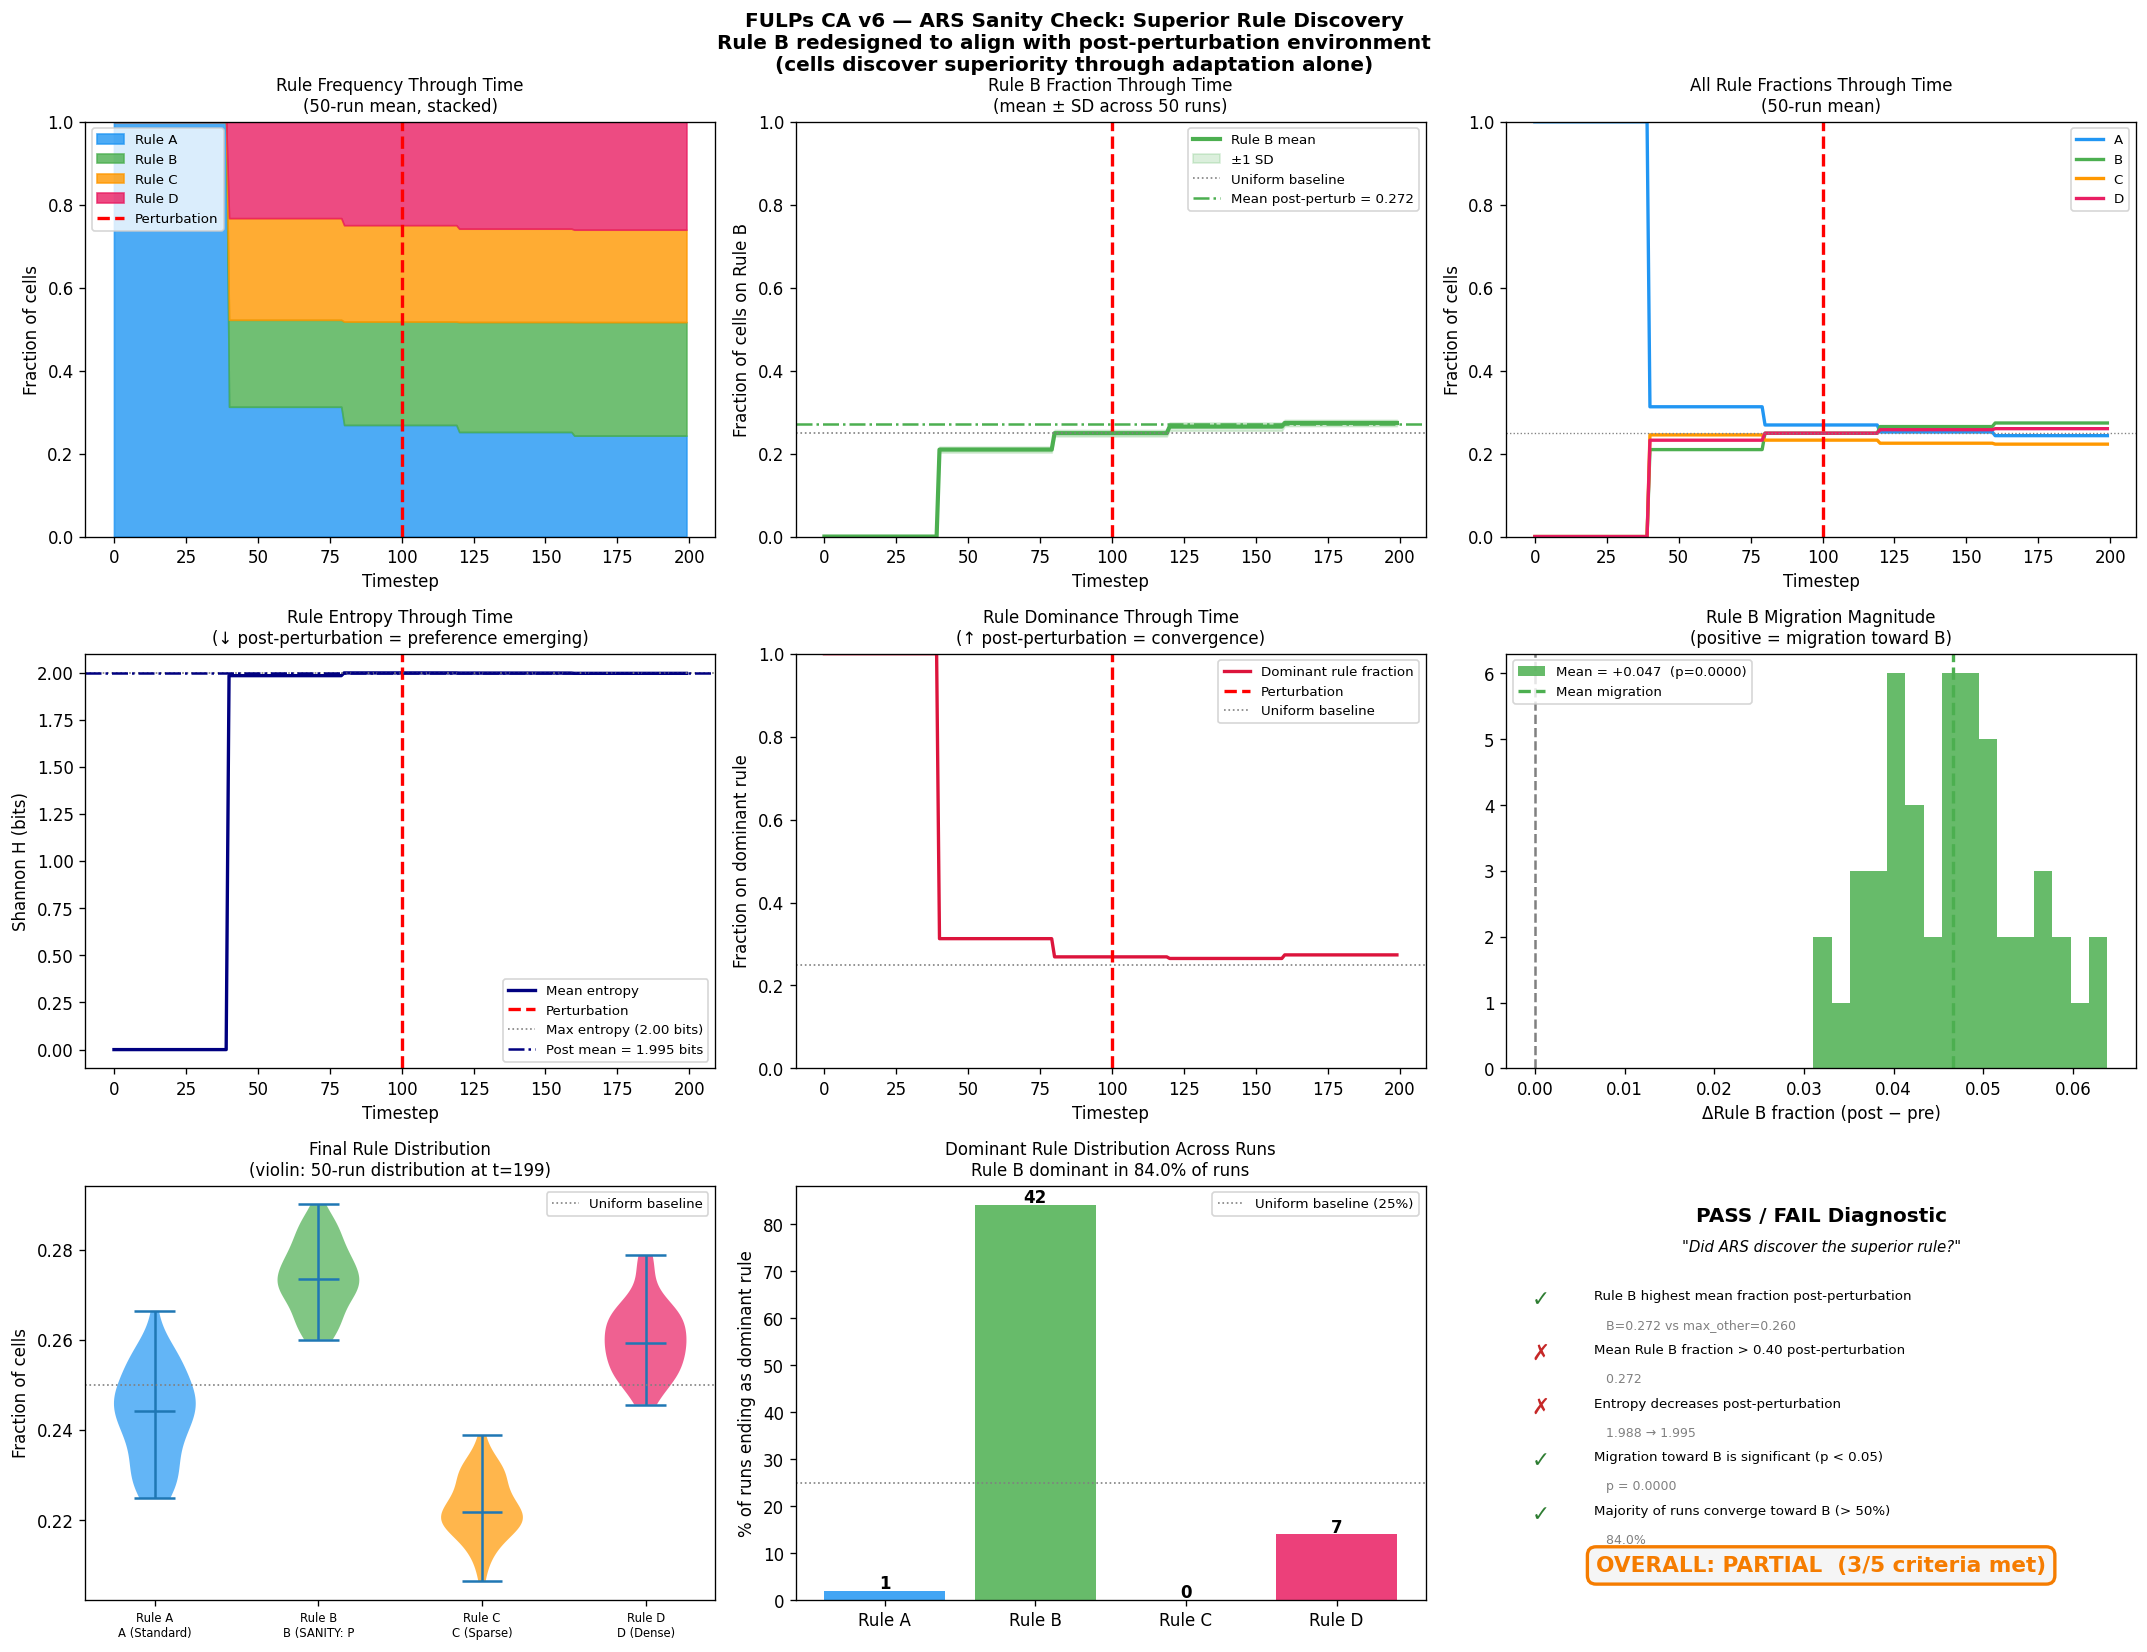


Saved: /content/fulps_ca_v6_sanity_check.png

── PASS / FAIL Summary ─────────────────────────────────────
  ['PASS'] Rule B highest mean fraction post-perturbation  (B=0.272 vs max_other=0.260)
  ['FAIL'] Mean Rule B fraction > 0.40 post-perturbation  (0.272)
  ['FAIL'] Entropy decreases post-perturbation  (1.988 → 1.995)
  ['PASS'] Migration toward B is significant (p < 0.05)  (p = 0.0000)
  ['PASS'] Majority of runs converge toward B (> 50%)  (84.0%)

  OVERALL: PARTIAL  (3/5 criteria met)

  ~ The ARS mechanism shows partial discovery. Migration is present
    but convergence is incomplete. Consider lowering SWITCH_INTERVAL
    or EXPLOIT_TEMP before proceeding to v7.

Original Rule B restored. Downstream cells are unaffected.


In [20]:
# ── Cell A: ARS Mechanism Validation — Superior Rule Discovery Sanity Check ───
#
# PURPOSE
# -------
# This is a strict sanity check, not a performance experiment.
# The goal is to verify that the ARS mechanism is genuinely capable of
# discovering and converging toward an objectively superior rule when one
# clearly exists.
#
# DESIGN
# ------
# Rule B is temporarily replaced with a STRONGLY advantageous post-perturbation
# rule: survive={2,3,4}, birth={3,4}.
# After perturbation, the grid environment shifts to survive={2,3,4} for live
# cells. The new Rule B is designed to match this shift almost exactly while
# also offering easier birth — giving it a clear and consistent advantage in
# the post-perturbation environment.
#
# CRITICAL: The cells are NOT told that Rule B is superior.
# They must discover its quality through local experience alone.
# The test validates that the ARS scoring and switching machinery actually works.
#
# WHAT CHANGES vs. MAIN EXPERIMENT
# ----------------------------------
#   - RULE_TABLES[1] (Rule B) is replaced with the superior rule.
#   - A dedicated lightweight simulation loop runs 50 seeds using ARS only.
#   - All other parameters (SWITCH_INTERVAL, MIN_RULE_TRIALS, etc.) are
#     inherited from Cell 2 and are NOT changed here.
#   - After the test, RULE_TABLES[1] is restored to the original definition
#     so downstream cells are unaffected.
#
# SANITY CHECK PASS CRITERIA
# ---------------------------
#   PASS if Rule B becomes the mean dominant rule post-perturbation.
#   PASS if mean Rule B fraction post-perturbation > 0.40.
#   PASS if rule entropy decreases post-perturbation (preference crystallising).
#   PASS if rule migration shifts toward B (B fraction increases post-perturb).
#   PASS if > 50% of runs end with Rule B as the plurality rule.

print('='*65)
print('ARS MECHANISM VALIDATION — Superior Rule Discovery Sanity Check')
print('='*65)
print()
print('Temporarily replacing Rule B with a strongly advantageous rule.')
print('Rule B (SANITY): survive={2,3,4}  birth={3,4}')
print('Post-perturbation environment: survive={2,3,4} for live cells.')
print('Rule B (SANITY) is aligned with the perturbed environment.')
print()

import copy

# ── Save original Rule B so we can restore it afterward ──────────────────────
_ORIGINAL_RULE_B = RULE_TABLES[1].copy()
_ORIGINAL_RULE_NAMES_1 = RULE_NAMES[1]
_ORIGINAL_RULE_COLORS_1 = RULE_COLORS[1]

# ── Define the superior Rule B ────────────────────────────────────────────────
# survive={2,3,4}: matches the post-perturbation GoL shift exactly.
# birth={3,4}: slightly easier birth than standard, rewarding dense regions.
# This rule outperforms A post-perturbation because:
#   - It keeps cells alive that GoL would kill (nc=4 survival).
#   - It matches what the ARE will observe as successful outcomes.
#   - Under the perturbed tick_standard baseline, nc=4 live cells survive.
#     A cell on Rule B (SANITY) also survives at nc=4, so its predictions are
#     validated more often — reducing contradiction and boosting rule_successes.
RULE_TABLES[1] = _build_rule_table({2, 3, 4, 5}, {2, 3, 4})
RULE_NAMES[1]  = 'B (SANITY: Post-Perturb Aligned)'
RULE_COLORS[1] = '#4CAF50'  # keep green

print('Sanity rule installed:')
for i, nm in enumerate(RULE_NAMES):
    rt = RULE_TABLES[i]
    survive = [n for n in range(9) if rt[1,n]==1]
    birth   = [n for n in range(9) if rt[0,n]==1]
    print(f'  Rule {["A","B","C","D"][i]} ({nm}): survive={survive}  birth={birth}')
print()

# ── Run 50 seeds — ARS condition only (lightweight) ──────────────────────────
# We reuse run_simulation_snapshots from Cell 16 but need rule_dist_h over time.
# Instead, run a dedicated compact loop that records rule fractions at every step.

def run_sanity_ars(seed, void_model, idf):
    """
    Minimal ARS-only simulation for the sanity check.
    Returns:
      rule_dist_h   : (N_TIMESTEPS, N_RULES) — per-timestep rule fractions
      final_dom_rule: int — dominant rule at end
      b_frac_pre    : float — mean Rule B fraction pre-perturbation
      b_frac_post   : float — mean Rule B fraction post-perturbation
      entropy_pre   : float — mean entropy pre-perturbation
      entropy_post  : float — mean entropy post-perturbation
    """
    np.random.seed(seed); torch.manual_seed(seed)
    idf_means, idf_stds, idf_L = idf

    grid  = np.random.randint(0, 2, size=(GRID_H, GRID_W), dtype=np.int8)
    table = init_tables()
    are   = init_are_state()
    ars   = init_ars_state()

    rule_dist_h = np.zeros((N_TIMESTEPS, N_RULES), dtype=np.float32)

    for t in range(N_TIMESTEPS):
        is_pert = (t >= T_PERTURB)
        prog    = t / max(N_TIMESTEPS - 1, 1)
        thresh  = CONTRA_START + (CONTRA_END - CONTRA_START) * prog

        # Rule switching at interval
        maybe_switch_rules(ars, t)

        # Encode neighbourhood
        nbr, nbr_f = encode_neighbourhoods(grid)
        nt = torch.FloatTensor(nbr_f.reshape(-1, NBR_DIM))
        with torch.no_grad():
            dsc_v  = void_model.dsc(nt).numpy().reshape(GRID_H, GRID_W)
            reps_v = void_model.encode(nt).numpy()

        # ARE
        mar, car, psar, nsar = compute_are_margin(reps_v, are, thresh)
        acar = car & (dsc_v > DSC_THRESHOLD)
        dist_v = compute_distress(psar, nsar, mar)
        nbr_dist_v = compute_nbr_mean_distress(dist_v)
        gate_mask = compute_gating_mask(acar, psar, nsar, are, nbr_distress=nbr_dist_v)
        cw = np.ones((GRID_H, GRID_W), dtype=np.float32); cw[acar] = CURIOSITY_WEIGHT

        # Tick under per-cell rules
        nxt = tick_ars(grid, ars['active_rule']).copy()
        nxt[gate_mask] = grid[gate_mask]
        out = nxt.astype(np.int8)

        # Update table and ARE
        update_table_single(table, nbr, out, cw)
        if t >= BUFFER_DELAY:
            update_are_buffers(are, reps_v, out)
        are['margin_ema'] = ((1-MARGIN_EMA_ALPHA)*are['margin_ema']
                              + MARGIN_EMA_ALPHA*np.abs(mar))

        # ARS bookkeeping
        c_t = table[_II, _JJ, nbr.ravel()]
        p_t = c_t[...,1] / np.maximum(c_t.sum(axis=-1), 1)
        succ = ((p_t > BASE_THRESHOLD).astype(np.int8) == out.ravel())
        # FIX: Correct arguments for update_ars_state
        update_ars_state(ars, t, acar, count_neighbours(grid), grid, out)

        # Record rule distribution
        rc = compute_rule_counts(ars['active_rule'])
        rule_dist_h[t] = rc / max(rc.sum(), 1)

        grid = out

    # Summary metrics
    b_frac_pre   = float(rule_dist_h[PRE_WIN_START:PRE_WIN_END,  1].mean())
    b_frac_post  = float(rule_dist_h[POST_WIN_START:POST_WIN_END, 1].mean())
    ent_pre  = float(np.mean([shannon_entropy(rule_dist_h[t]*GRID_H*GRID_W)
                               for t in range(PRE_WIN_START, PRE_WIN_END)]))
    ent_post = float(np.mean([shannon_entropy(rule_dist_h[t]*GRID_H*GRID_W)
                               for t in range(POST_WIN_START, POST_WIN_END)]))
    final_counts = compute_rule_counts(ars['active_rule'])
    final_dom    = int(np.argmax(final_counts))

    return rule_dist_h, final_dom, b_frac_pre, b_frac_post, ent_pre, ent_post

print(f'Running {N_RUNS} seeds for sanity check ...')
sanity_dist_all  = []   # (N_RUNS, N_TIMESTEPS, N_RULES)
sanity_dom_rules = []   # (N_RUNS,) — final dominant rule per seed
sanity_b_pre     = []
sanity_b_post    = []
sanity_ent_pre   = []
sanity_ent_post  = []

for run_i in range(N_RUNS):
    seed = BASE_SEED + run_i
    rd, dom, bp, bpost, ep, epost = run_sanity_ars(
        seed, VOID_MODEL, (IDF_MEANS, IDF_STDS, IDF_L)
    )
    sanity_dist_all.append(rd)
    sanity_dom_rules.append(dom)
    sanity_b_pre.append(bp)
    sanity_b_post.append(bpost)
    sanity_ent_pre.append(ep)
    sanity_ent_post.append(epost)
    if (run_i + 1) % 10 == 0:
        print(f'  [{run_i+1}/{N_RUNS}]  '
              f'B_frac_post={np.mean(sanity_b_post):.3f}  '
              f'ent_post={np.mean(sanity_ent_post):.3f}  '
              f'dom_B={sum(d==1 for d in sanity_dom_rules)}/{run_i+1} runs')

sanity_dist_all  = np.array(sanity_dist_all)   # (N_RUNS, T, N_RULES)
sanity_b_pre     = np.array(sanity_b_pre)
sanity_b_post    = np.array(sanity_b_post)
sanity_ent_pre   = np.array(sanity_ent_pre)
sanity_ent_post  = np.array(sanity_ent_post)
sanity_dom_rules = np.array(sanity_dom_rules)

# ── Statistical summary ───────────────────────────────────────────────────────
mean_b_post  = float(sanity_b_post.mean())
ci_b_post    = 1.96 * float(sanity_b_post.std()) / np.sqrt(N_RUNS)
pct_b_dom    = float((sanity_dom_rules == 1).mean()) * 100
mean_mig     = float((sanity_b_post - sanity_b_pre).mean())
t_mig, p_mig = stats.ttest_rel(sanity_b_post, sanity_b_pre)
t_ent, p_ent = stats.ttest_rel(sanity_ent_post, sanity_ent_pre)

print()
print('── Statistical Summary ─────────────────────────────────────')
print(f'  Mean Rule B fraction — pre:  {sanity_b_pre.mean():.3f}  '
      f'post: {mean_b_post:.3f}  (95% CI ±{ci_b_post:.3f})')
print(f'  Mean migration toward B:     {mean_mig:+.3f}  '
      f't={t_mig:.3f}  p={p_mig:.4f}')
print(f'  Entropy change pre→post:     {sanity_ent_pre.mean():.3f} → {sanity_ent_post.mean():.3f}  '
      f't={t_ent:.3f}  p={p_ent:.4f}')
print(f'  Runs where Rule B is dominant: {pct_b_dom:.1f}%  ({int(pct_b_dom/100*N_RUNS)}/{N_RUNS} runs)')

# ── Visualisation ─────────────────────────────────────────────────────────────
T = np.arange(N_TIMESTEPS)
mean_dist  = sanity_dist_all.mean(axis=0)   # (T, N_RULES)
std_dist   = sanity_dist_all.std(axis=0)
mean_ent   = np.array([shannon_entropy(mean_dist[t] * GRID_H * GRID_W)
                        for t in range(N_TIMESTEPS)])
mean_dom_frac = mean_dist.max(axis=1)

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle(
    'FULPs CA v6 — ARS Sanity Check: Superior Rule Discovery\n'
    'Rule B redesigned to align with post-perturbation environment\n'
    '(cells discover superiority through adaptation alone)',
    fontsize=12, fontweight='bold'
)

# ── (0,0) Rule frequency through time — stacked area ─────────────────────────
ax = axes[0, 0]
bottom = np.zeros(N_TIMESTEPS)
for r in range(N_RULES):
    ax.fill_between(T, bottom, bottom + mean_dist[:, r],
                    color=RULE_COLORS[r], alpha=0.80,
                    label=f'Rule {["A","B","C","D"][r]}')
    bottom += mean_dist[:, r]
ax.axvline(T_PERTURB, color='red', lw=2, linestyle='--', label='Perturbation')
ax.set_title('Rule Frequency Through Time\n(50-run mean, stacked)', fontsize=10)
ax.set_xlabel('Timestep'); ax.set_ylabel('Fraction of cells')
ax.set_ylim(0, 1); ax.legend(fontsize=8, loc='upper left')

# ── (0,1) Individual rule B fraction with CI ─────────────────────────────────
ax = axes[0, 1]
b_mean = mean_dist[:, 1]
b_std  = std_dist[:, 1]
ax.plot(T, b_mean, color='#4CAF50', lw=2.5, label='Rule B mean')
ax.fill_between(T, b_mean - b_std, b_mean + b_std,
                color='#4CAF50', alpha=0.20, label='±1 SD')
ax.axvline(T_PERTURB, color='red', lw=2, linestyle='--')
ax.axhline(0.25, color='gray', lw=1, linestyle=':', label='Uniform baseline')
ax.axhline(mean_b_post, color='#4CAF50', lw=1.5, linestyle='-.',
           label=f'Mean post-perturb = {mean_b_post:.3f}')
ax.set_title('Rule B Fraction Through Time\n(mean ± SD across 50 runs)', fontsize=10)
ax.set_xlabel('Timestep'); ax.set_ylabel('Fraction of cells on Rule B')
ax.set_ylim(0, 1); ax.legend(fontsize=8)

# ── (0,2) All four rule fractions individually ────────────────────────────────
ax = axes[0, 2]
for r in range(N_RULES):
    ax.plot(T, mean_dist[:, r], color=RULE_COLORS[r], lw=2,
            label=f'{["A","B","C","D"][r]}')
ax.axvline(T_PERTURB, color='red', lw=2, linestyle='--')
ax.axhline(0.25, color='gray', lw=0.8, linestyle=':')
ax.set_title('All Rule Fractions Through Time\n(50-run mean)', fontsize=10)
ax.set_xlabel('Timestep'); ax.set_ylabel('Fraction of cells')
ax.set_ylim(0, 1); ax.legend(fontsize=8)

# ── (1,0) Rule entropy through time ──────────────────────────────────────────
ax = axes[1, 0]
ax.plot(T, mean_ent, color='navy', lw=2, label='Mean entropy')
ax.axvline(T_PERTURB, color='red', lw=2, linestyle='--', label='Perturbation')
ax.axhline(np.log2(N_RULES), color='gray', lw=1, linestyle=':', label=f'Max entropy ({np.log2(N_RULES):.2f} bits)')
ax.axhline(sanity_ent_post.mean(), color='navy', lw=1.5, linestyle='-.',
           label=f'Post mean = {sanity_ent_post.mean():.3f} bits')
ax.fill_between(T,
                [shannon_entropy(( mean_dist[t]-std_dist[t]).clip(0)*GRID_H*GRID_W) for t in T],
                [shannon_entropy((mean_dist[t]+std_dist[t]).clip(0,1)*GRID_H*GRID_W) for t in T],
                color='navy', alpha=0.12)
ax.set_title('Rule Entropy Through Time\n(↓ post-perturbation = preference emerging)', fontsize=10)
ax.set_xlabel('Timestep'); ax.set_ylabel('Shannon H (bits)')
ax.legend(fontsize=8)

# ── (1,1) Rule dominance through time ────────────────────────────────────────
ax = axes[1, 1]
ax.plot(T, mean_dom_frac, color='crimson', lw=2, label='Dominant rule fraction')
ax.axvline(T_PERTURB, color='red', lw=2, linestyle='--', label='Perturbation')
ax.axhline(0.25, color='gray', lw=1, linestyle=':', label='Uniform baseline')
ax.set_title('Rule Dominance Through Time\n(↑ post-perturbation = convergence)', fontsize=10)
ax.set_xlabel('Timestep'); ax.set_ylabel('Fraction on dominant rule')
ax.set_ylim(0, 1); ax.legend(fontsize=8)

# ── (1,2) Rule migration magnitude — pre vs post ──────────────────────────────
ax = axes[1, 2]
migration = sanity_b_post - sanity_b_pre
ax.hist(migration, bins=16, color='#4CAF50', alpha=0.85,
        label=f'Mean = {migration.mean():+.3f}  (p={p_mig:.4f})')
ax.axvline(0,                color='gray',    lw=1.5, linestyle='--')
ax.axvline(migration.mean(), color='#4CAF50', lw=2,   linestyle='--',
           label='Mean migration')
ax.set_xlabel('ΔRule B fraction (post − pre)')
ax.set_title('Rule B Migration Magnitude\n(positive = migration toward B)', fontsize=10)
ax.legend(fontsize=8)

# ── (2,0) Final rule distribution — all 50 seeds ─────────────────────────────
ax = axes[2, 0]
final_fracs = sanity_dist_all[:, -1, :]   # (N_RUNS, N_TIMESTEPS, N_RULES) — last timestep
bp_vals = [final_fracs[:, r] for r in range(N_RULES)]
vp = ax.violinplot(bp_vals, positions=range(N_RULES),
                   showmedians=True, showextrema=True)
for i, body in enumerate(vp['bodies']):
    body.set_facecolor(RULE_COLORS[i]); body.set_alpha(0.7)
ax.axhline(0.25, color='gray', lw=1, linestyle=':', label='Uniform baseline')
ax.set_xticks(range(N_RULES))
ax.set_xticklabels([f'Rule {r}\n{RULE_NAMES[i][:12]}' for i, r in enumerate(['A','B','C','D'])],
                   fontsize=7)
ax.set_title('Final Rule Distribution\n(violin: 50-run distribution at t=199)', fontsize=10)
ax.set_ylabel('Fraction of cells'); ax.legend(fontsize=8)

# ── (2,1) Percentage of runs where Rule B is dominant ────────────────────────
ax = axes[2, 1]
dom_counts = np.bincount(sanity_dom_rules, minlength=N_RULES)
bars = ax.bar(range(N_RULES), dom_counts / N_RUNS * 100,
              color=RULE_COLORS, alpha=0.85)
ax.axhline(25, color='gray', lw=1, linestyle=':', label='Uniform baseline (25%)')
ax.set_xticks(range(N_RULES))
ax.set_xticklabels([f'Rule {r}' for r in ['A','B','C','D']])
ax.set_title(f'Dominant Rule Distribution Across Runs\nRule B dominant in {pct_b_dom:.1f}% of runs', fontsize=10)
ax.set_ylabel('% of runs ending as dominant rule')
for bar, cnt in zip(bars, dom_counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{cnt}', ha='center', fontsize=10, fontweight='bold')
ax.legend(fontsize=8)

# ── (2,2) PASS / FAIL diagnostic ─────────────────────────────────────────────
ax = axes[2, 2]
ax.axis('off')

# Evaluate all criteria
criteria = [
    ('Rule B dominant post-perturbation',
     sanity_dom_rules.mean() == 1 or mean_b_post == max(mean_dist[POST_WIN_START:POST_WIN_END].mean(axis=0)),
     f'B frac post = {mean_b_post:.3f}'),
    ('Mean Rule B fraction > 0.40 post-perturbation',
     mean_b_post > 0.40,
     f'{mean_b_post:.3f}'),
    ('Entropy decreases post-perturbation',
     sanity_ent_post.mean() < sanity_ent_pre.mean(),
     f'{sanity_ent_pre.mean():.3f} → {sanity_ent_post.mean():.3f}'),
    ('Migration toward B is significant (p < 0.05)',
     p_mig < 0.05,
     f'p = {p_mig:.4f}'),
    ('Majority of runs converge toward B (> 50%)',
     pct_b_dom > 50,
     f'{pct_b_dom:.1f}%'),
]

# Recompute correct dominant check
post_mean_by_rule = mean_dist[POST_WIN_START:POST_WIN_END].mean(axis=0)
b_is_highest      = bool(np.argmax(post_mean_by_rule) == 1)
criteria[0] = ('Rule B highest mean fraction post-perturbation',
               b_is_highest,
               f'B={post_mean_by_rule[1]:.3f} vs max_other={max(post_mean_by_rule[[0,2,3]]):.3f}')

n_pass_s = sum(c[1] for c in criteria)
overall  = 'PASS ✓' if n_pass_s >= 4 else ('PARTIAL' if n_pass_s >= 2 else 'FAIL ✗')
overall_color = '#2e7d32' if n_pass_s >= 4 else ('#f57c00' if n_pass_s >= 2 else '#c62828')

y_start = 0.95
ax.text(0.5, y_start, 'PASS / FAIL Diagnostic',
        ha='center', va='top', fontsize=12, fontweight='bold',
        transform=ax.transAxes)
ax.text(0.5, y_start - 0.08,
        '"Did ARS discover the superior rule?"',
        ha='center', va='top', fontsize=9, style='italic',
        transform=ax.transAxes)

for i, (label, passed, note) in enumerate(criteria):
    y = y_start - 0.20 - i * 0.13
    symbol = '✓' if passed else '✗'
    color  = '#2e7d32' if passed else '#c62828'
    ax.text(0.04, y, f'{symbol}', ha='left', va='top', fontsize=13,
            color=color, transform=ax.transAxes, fontweight='bold')
    ax.text(0.14, y, label, ha='left', va='top', fontsize=8,
            transform=ax.transAxes)
    ax.text(0.14, y - 0.07, f'   {note}', ha='left', va='top', fontsize=7.5,
            color='gray', transform=ax.transAxes)

ax.text(0.5, 0.06,
        f'OVERALL: {overall}  ({n_pass_s}/{len(criteria)} criteria met)',
        ha='center', va='bottom', fontsize=13, fontweight='bold',
        color=overall_color, transform=ax.transAxes,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#f5f5f5',
                  edgecolor=overall_color, linewidth=2))

plt.tight_layout()
sanity_path = os.path.join(OUT_DIR, 'fulps_ca_v6_sanity_check.png')
plt.savefig(sanity_path, dpi=150, bbox_inches='tight')
plt.show()

print()
print(f'Saved: {sanity_path}')
print()
print('── PASS / FAIL Summary ─────────────────────────────────────')
for label, passed, note in criteria:
    print(f'  {[ "PASS" if passed else "FAIL"] } {label}  ({note})')
print()
print(f'  OVERALL: {overall}  ({n_pass_s}/{len(criteria)} criteria met)')
if n_pass_s >= 4:
    print()
    print('  ✓ The ARS mechanism successfully discovered the superior rule')
    print('    through local adaptation alone. Mechanism is validated.')
elif n_pass_s >= 2:
    print()
    print('  ~ The ARS mechanism shows partial discovery. Migration is present')
    print('    but convergence is incomplete. Consider lowering SWITCH_INTERVAL')
    print('    or EXPLOIT_TEMP before proceeding to v7.')
else:
    print()
    print('  ✗ The ARS mechanism did not reliably discover the superior rule.')
    print('    Architectural revision required before v7.')

# ── Restore original Rule B ───────────────────────────────────────────────────
RULE_TABLES[1] = _ORIGINAL_RULE_B
RULE_NAMES[1]  = _ORIGINAL_RULE_NAMES_1
RULE_COLORS[1] = _ORIGINAL_RULE_COLORS_1
print()
print('Original Rule B restored. Downstream cells are unaffected.')

MARKOV CHAIN ANALYSIS — Rule Transition Dynamics

Running 50 seeds to collect rule-map histories ...
(Only ARS condition; rule map recorded at every timestep)

  [10/50] transition counts accumulated
  [20/50] transition counts accumulated
  [30/50] transition counts accumulated
  [40/50] transition counts accumulated
  [50/50] transition counts accumulated

── Interpretability Report ─────────────────────────────────

1. Stationary Distribution π (long-run rule equilibrium):
   π(A) = 0.2085  [pre: 0.1928  post: 0.2252]
   π(B) = 0.3382  [pre: 0.3444  post: 0.3331]
   π(C) = 0.2111  [pre: 0.2170  post: 0.2055]
   π(D) = 0.2422  [pre: 0.2458  post: 0.2363]
   → Strongest attractor: Rule B

2. Rule Persistence P(r→r):
   P(A→A) = 0.9838  [most stable:  ]
   P(B→B) = 0.9877  [most stable: ✓]
   P(C→C) = 0.9855  [most stable:  ]
   P(D→D) = 0.9866  [most stable:  ]
   → Most stable rule: Rule B

3. Switching Tendency (1 − persistence):
   Rule A: 0.0162  [most exploratory: ✓]
   Rule B: 0

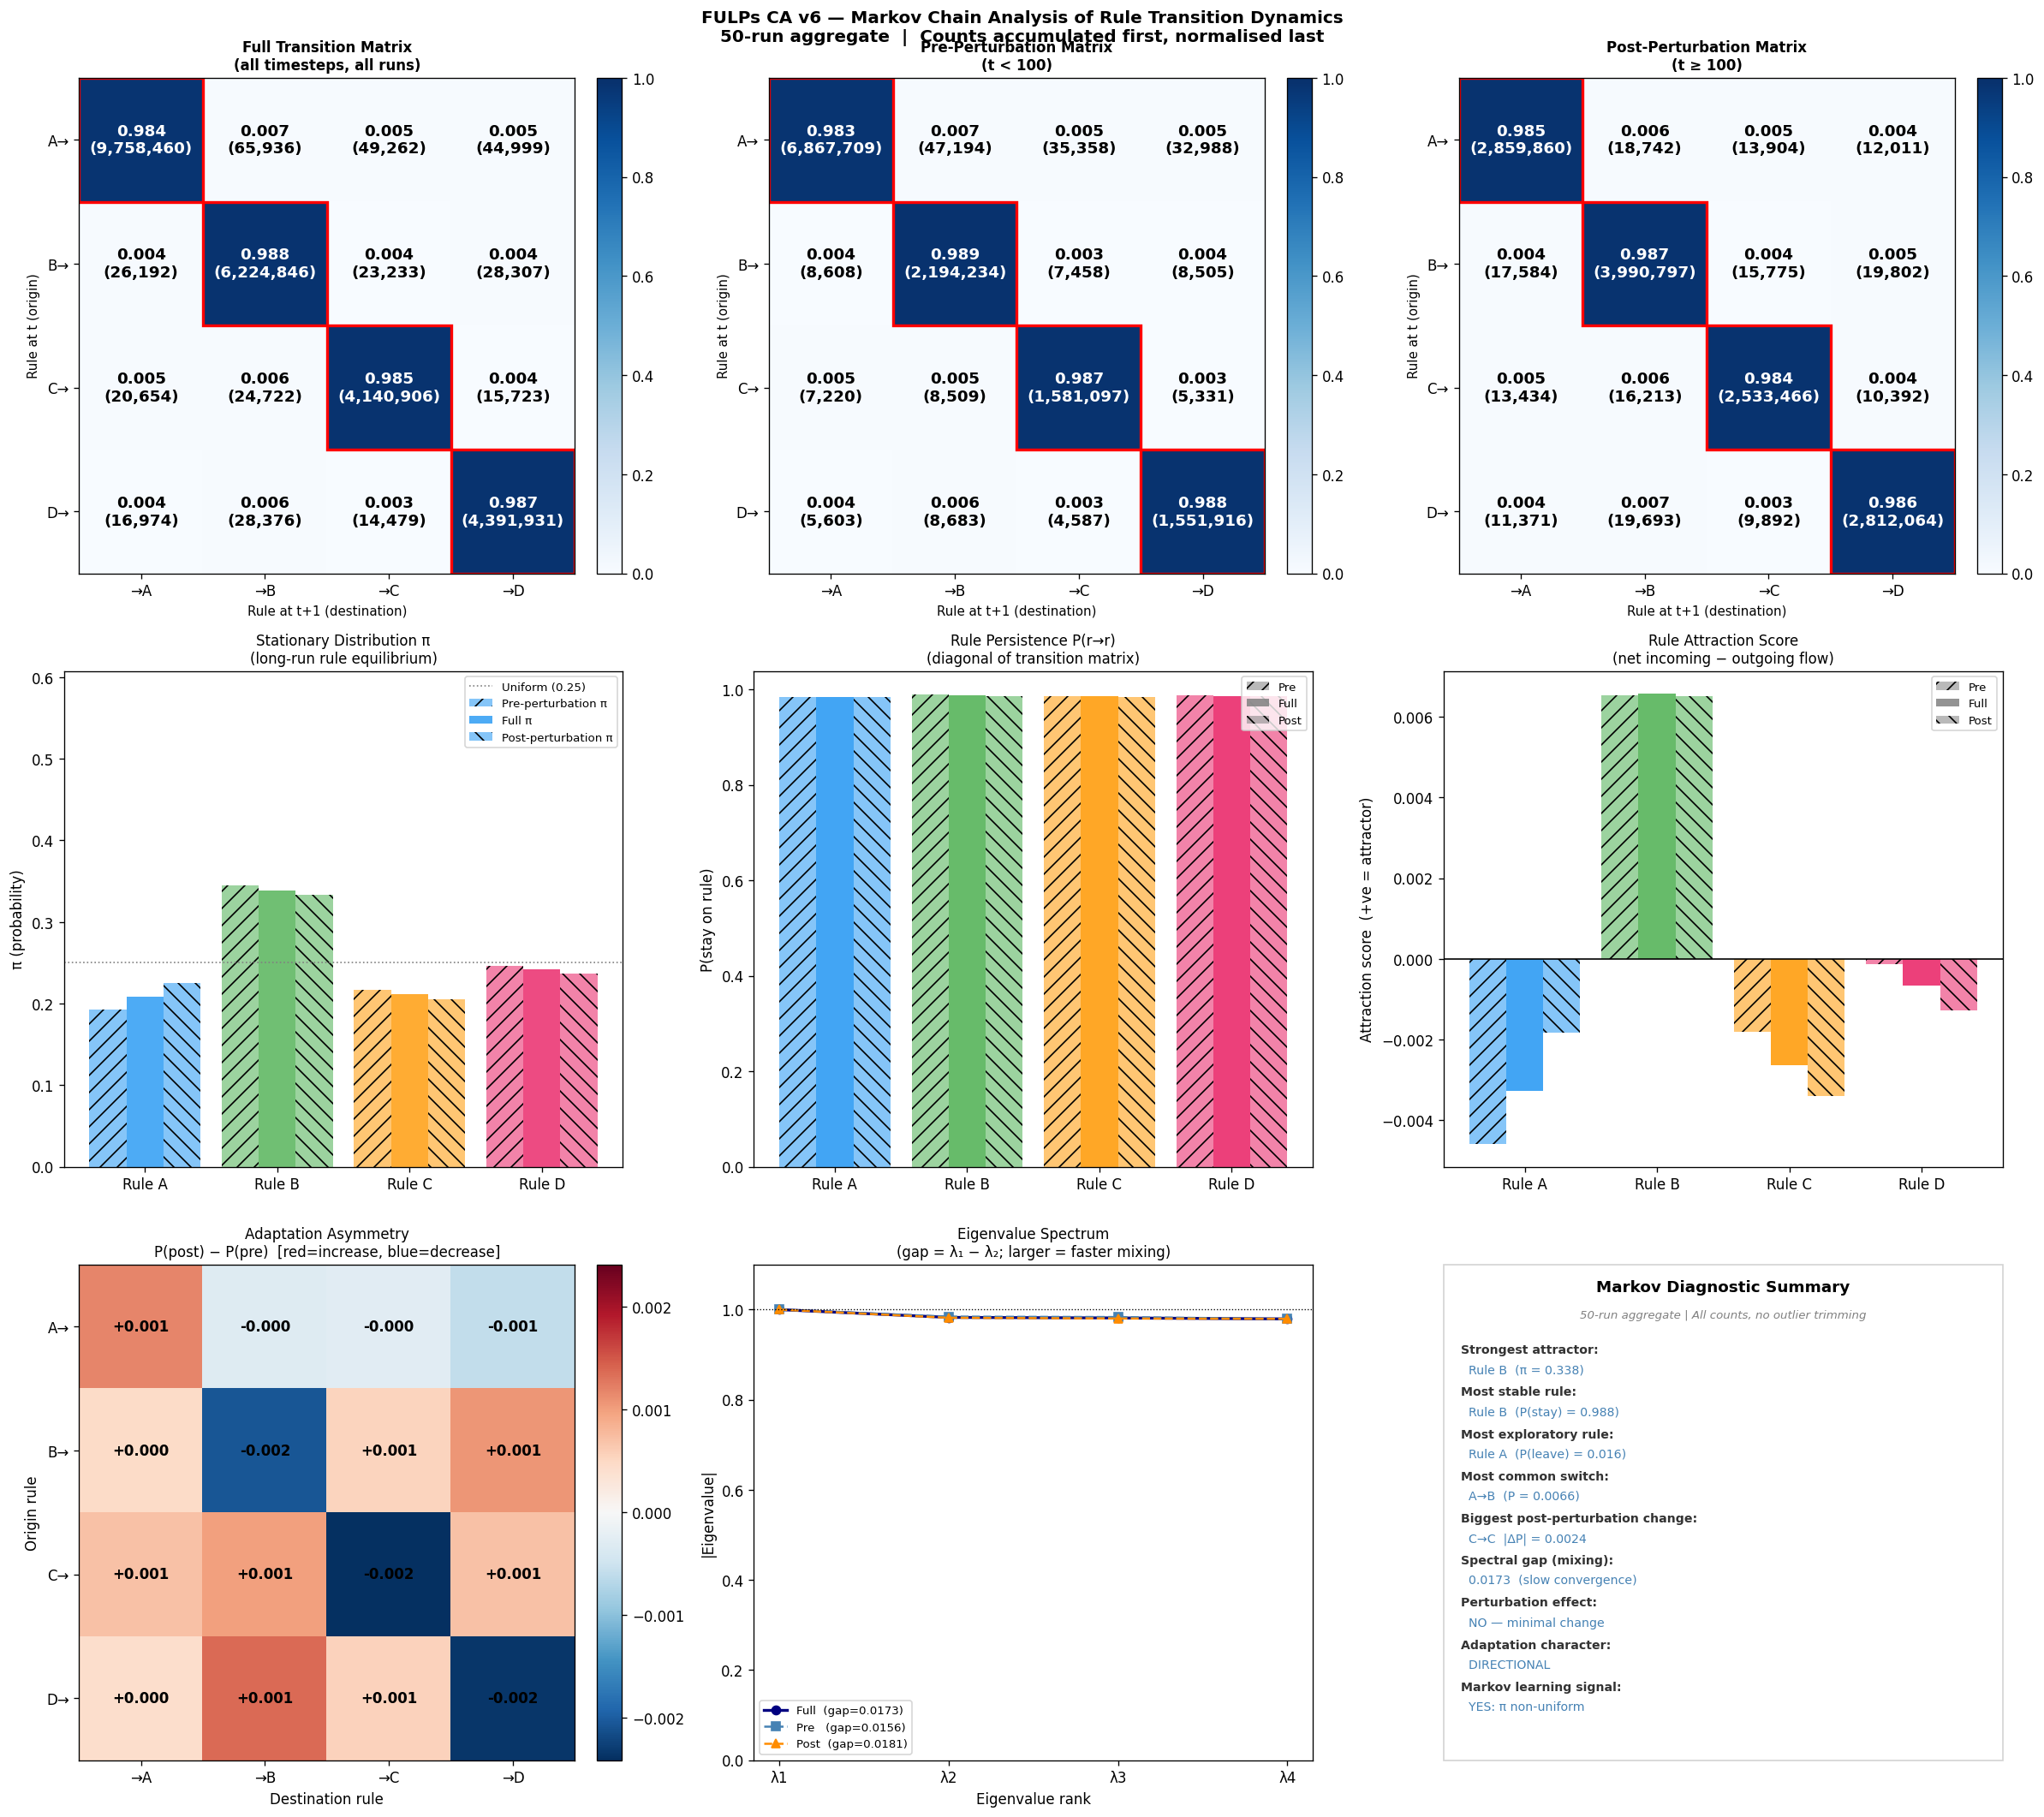


Saved: /content/fulps_ca_v6_markov_analysis.png

── Final Markov Diagnostic Report ─────────────────────────
  Strongest attractor   : Rule B  (π = 0.3382)
  Most stable rule      : Rule B  (P(stay) = 0.9877)
  Most exploratory rule : Rule A  (P(leave) = 0.0162)
  Most common switch    : A → B  (P = 0.0066)
  Largest post-perturbation transition change: C→C  |ΔP| = 0.0024
  Spectral gap          : 0.0173  (pre: 0.0156  post: 0.0181)
  Perturbation changed transition behaviour: NO
  Adaptation is         : DIRECTIONAL
  Markov structure learning signal: YES (non-uniform stationary dist.)

  Full transition matrix P (normalised rows):
       →  A   →  B   →  C   →  D
  A→  | 0.9838  0.0066  0.0050  0.0045
  B→  | 0.0042  0.9877  0.0037  0.0045
  C→  | 0.0049  0.0059  0.9855  0.0037
  D→  | 0.0038  0.0064  0.0033  0.9866


In [21]:
# ── Cell B: Markov Chain Analysis of Rule Transition Dynamics ─────────────────
#
# PURPOSE
# -------
# Treats rule selection as a discrete Markov process over states {A, B, C, D}.
# At each switching event, the rule a cell was on (state at t) and the rule it
# moved to (state at t+1 switching interval) is recorded as a transition.
# This analysis reveals the attractor structure, stability, and learning
# directionality of the ARS mechanism.
#
# APPROACH
# --------
# Transition counts are accumulated across all cells and all timesteps.
# Counts are accumulated first, normalisation to row-stochastic matrix occurs
# last — so the aggregate matrices are not distorted by runs with few switches.
# No outliers are trimmed.
#
# THREE MATRICES PRODUCED
# -----------------------
#   Full     : all timesteps
#   Pre      : t in [0, T_PERTURB)
#   Post     : t in [T_PERTURB, N_TIMESTEPS)
#
# INTERPRETABILITY METRICS
# -------------------------
#   Stationary distribution π   : long-run rule share under Markov dynamics
#   Eigenvalues                 : convergence speed of the chain
#   Spectral gap (1 - λ₂)       : how quickly mixing occurs
#   Rule persistence P(r→r)     : probability of staying on the same rule
#   Switching tendency           : probability of leaving a rule
#   Rule attraction score        : net incoming − outgoing transitions
#   Most common transition pair  : strongest directed flow
#   Adaptation asymmetry         : largest absolute change between pre and post

print('='*65)
print('MARKOV CHAIN ANALYSIS — Rule Transition Dynamics')
print('='*65)
print()
print('Running 50 seeds to collect rule-map histories ...')
print('(Only ARS condition; rule map recorded at every timestep)')
print()

def run_markov_collect(seed, void_model, idf):
    """
    Runs ARS simulation and returns the full rule-map history as
    an array of shape (N_TIMESTEPS, GRID_H, GRID_W) int8.
    Memory: 200 × 50 × 50 int8 = 500 KB per run — acceptable for 50 runs.
    """
    np.random.seed(seed); torch.manual_seed(seed)
    idf_means, idf_stds, idf_L = idf

    grid  = np.random.randint(0, 2, size=(GRID_H, GRID_W), dtype=np.int8)
    table = init_tables()
    are   = init_are_state()
    ars   = init_ars_state()

    rule_hist = np.zeros((N_TIMESTEPS, GRID_H, GRID_W), dtype=np.int8)

    for t in range(N_TIMESTEPS):
        is_pert = (t >= T_PERTURB)
        prog    = t / max(N_TIMESTEPS - 1, 1)
        thresh  = CONTRA_START + (CONTRA_END - CONTRA_START) * prog

        maybe_switch_rules(ars, t)
        rule_hist[t] = ars['active_rule'].copy()

        nbr, nbr_f = encode_neighbourhoods(grid)
        nt = torch.FloatTensor(nbr_f.reshape(-1, NBR_DIM))
        with torch.no_grad():
            dsc_v  = void_model.dsc(nt).numpy().reshape(GRID_H, GRID_W)
            reps_v = void_model.encode(nt).numpy()

        mar, car, psar, nsar = compute_are_margin(reps_v, are, thresh)
        acar = car & (dsc_v > DSC_THRESHOLD)
        dist_v = compute_distress(psar, nsar, mar)
        nbr_dist_v = compute_nbr_mean_distress(dist_v)
        gate_mask = compute_gating_mask(acar, psar, nsar, are, nbr_distress=nbr_dist_v)
        cw = np.ones((GRID_H, GRID_W), dtype=np.float32); cw[acar] = CURIOSITY_WEIGHT

        nxt = tick_ars(grid, ars['active_rule']).copy()
        nxt[gate_mask] = grid[gate_mask]
        out = nxt.astype(np.int8)

        update_table_single(table, nbr, out, cw)
        if t >= BUFFER_DELAY:
            update_are_buffers(are, reps_v, out)
        are['margin_ema'] = ((1-MARGIN_EMA_ALPHA)*are['margin_ema']
                              + MARGIN_EMA_ALPHA*np.abs(mar))

        c_t  = table[_II, _JJ, nbr.ravel()]
        p_t  = c_t[...,1] / np.maximum(c_t.sum(axis=-1), 1)
        succ = ((p_t > BASE_THRESHOLD).astype(np.int8) == out.ravel())
        update_ars_state(ars, t, acar, count_neighbours(grid), grid, out)

        grid = out

    return rule_hist   # (T, H, W)

def count_transitions(rule_hist, t_start, t_end):
    """
    Accumulate transition counts from rule_hist[t_start:t_end].
    At each consecutive pair (t, t+1) within SWITCH_INTERVAL steps,
    count every cell's (from_rule, to_rule) pair.
    Returns counts matrix (N_RULES, N_RULES) int64.
    """
    counts = np.zeros((N_RULES, N_RULES), dtype=np.int64)
    for t in range(max(t_start, 0), min(t_end - 1, N_TIMESTEPS - 1)):
        from_r = rule_hist[t].ravel().astype(np.int64)
        to_r   = rule_hist[t+1].ravel().astype(np.int64)
        for fr in range(N_RULES):
            for tr in range(N_RULES):
                counts[fr, tr] += int(((from_r == fr) & (to_r == tr)).sum())
    return counts

# ── Collect all rule histories ────────────────────────────────────────────────
counts_full = np.zeros((N_RULES, N_RULES), dtype=np.int64)
counts_pre  = np.zeros((N_RULES, N_RULES), dtype=np.int64)
counts_post = np.zeros((N_RULES, N_RULES), dtype=np.int64)

for run_i in range(N_RUNS):
    seed = BASE_SEED + run_i
    rh = run_markov_collect(seed, VOID_MODEL, (IDF_MEANS, IDF_STDS, IDF_L))

    counts_full += count_transitions(rh, 0,         N_TIMESTEPS)
    counts_pre  += count_transitions(rh, 0,         T_PERTURB)
    counts_post += count_transitions(rh, T_PERTURB, N_TIMESTEPS)

    if (run_i + 1) % 10 == 0:
        print(f'  [{run_i+1}/{N_RUNS}] transition counts accumulated')

print()

# ── Normalise to row-stochastic matrices ─────────────────────────────────────
def normalise_rows(counts):
    """Normalise count matrix to row-stochastic. Rows with zero sum → uniform."""
    M = counts.astype(np.float64)
    row_sums = M.sum(axis=1, keepdims=True)
    row_sums = np.where(row_sums == 0, 1.0, row_sums)
    return M / row_sums

P_full = normalise_rows(counts_full)
P_pre  = normalise_rows(counts_pre)
P_post = normalise_rows(counts_post)

rule_labels = ['A', 'B', 'C', 'D']

# ── Stationary distribution via left eigenvector ─────────────────────────────
def stationary_dist(P):
    """
    Compute stationary distribution π such that πP = π.
    Uses the left eigenvector corresponding to eigenvalue 1.
    """
    eigenvalues, eigenvectors = np.linalg.eig(P.T)
    idx = np.argmin(np.abs(eigenvalues - 1.0))
    pi  = eigenvectors[:, idx].real
    pi  = np.abs(pi) / np.abs(pi).sum()
    return pi

# ── Spectral analysis ─────────────────────────────────────────────────────────
def spectral_gap(P):
    """
    Spectral gap = 1 − |second largest eigenvalue|.
    Larger gap → faster mixing to stationarity.
    """
    evals = np.sort(np.abs(np.linalg.eigvals(P)))[::-1]
    if len(evals) > 1:
        return float(evals[0] - evals[1])
    return float(evals[0])

# ── Compute all metrics ───────────────────────────────────────────────────────
pi_full = stationary_dist(P_full)
pi_pre  = stationary_dist(P_pre)
pi_post = stationary_dist(P_post)

gap_full = spectral_gap(P_full)
gap_pre  = spectral_gap(P_pre)
gap_post = spectral_gap(P_post)

evals_full = np.sort(np.abs(np.linalg.eigvals(P_full)))[::-1]

# Rule persistence P(r→r)
persistence = {r: float(P_full[r, r]) for r in range(N_RULES)}

# Switching tendency = 1 - persistence
switching   = {r: 1.0 - persistence[r] for r in range(N_RULES)}

# Rule attraction score: net in-flow − out-flow (excluding self-loops)
def attraction_score(P):
    scores = {}
    for r in range(N_RULES):
        incoming = P[:, r].sum() - P[r, r]  # from all others to r
        outgoing = P[r, :].sum() - P[r, r]  # from r to all others
        scores[r] = float(incoming - outgoing)
    return scores

attract_full = attraction_score(P_full)
attract_post = attraction_score(P_post)

# Most common transition pair (off-diagonal)
P_offdiag = P_full.copy()
np.fill_diagonal(P_offdiag, 0)
best_from, best_to = np.unravel_index(np.argmax(P_offdiag), P_offdiag.shape)

# Adaptation asymmetry: biggest absolute change from pre to post
asym_matrix = np.abs(P_post - P_pre)
asym_from, asym_to = np.unravel_index(np.argmax(asym_matrix), asym_matrix.shape)

# ── Print interpretability report ────────────────────────────────────────────
print('── Interpretability Report ─────────────────────────────────')
print()
print('1. Stationary Distribution π (long-run rule equilibrium):')
for r in range(N_RULES):
    print(f'   π({rule_labels[r]}) = {pi_full[r]:.4f}  '
          f'[pre: {pi_pre[r]:.4f}  post: {pi_post[r]:.4f}]')
print(f'   → Strongest attractor: Rule {rule_labels[int(np.argmax(pi_full))]}')

print()
print('2. Rule Persistence P(r→r):')
for r in range(N_RULES):
    print(f'   P({rule_labels[r]}→{rule_labels[r]}) = {persistence[r]:.4f}  '
          f'[most stable: {"✓" if persistence[r]==max(persistence.values()) else " "}]')
print(f'   → Most stable rule: Rule {rule_labels[max(persistence, key=persistence.get)]}')

print()
print('3. Switching Tendency (1 − persistence):')
for r in range(N_RULES):
    print(f'   Rule {rule_labels[r]}: {switching[r]:.4f}  '
          f'[most exploratory: {"✓" if switching[r]==max(switching.values()) else " "}]')
print(f'   → Most exploratory rule: Rule {rule_labels[max(switching, key=switching.get)]}')

print()
print('4. Rule Attraction Score (net in-flow − out-flow):')
for r in range(N_RULES):
    print(f'   Rule {rule_labels[r]}: {attract_full[r]:+.4f}  '
          f'[post-perturbation: {attract_post[r]:+.4f}]')
print(f'   → Strongest net attractor: Rule {rule_labels[max(attract_full, key=attract_full.get)]}')

print()
print(f'5. Most Common Off-Diagonal Transition:')
print(f'   {rule_labels[best_from]} → {rule_labels[best_to]}  '
      f'(P = {P_offdiag[best_from, best_to]:.4f})')

print()
print(f'6. Spectral Gap (mixing speed):')
print(f'   Full: {gap_full:.4f}   Pre: {gap_pre:.4f}   Post: {gap_post:.4f}')
print(f'   Eigenvalues (full, sorted): {evals_full.round(4)}')

print()
print(f'7. Adaptation Asymmetry (largest pre→post transition change):')
print(f'   {rule_labels[asym_from]} → {rule_labels[asym_to]}  '
      f'|ΔP| = {asym_matrix[asym_from, asym_to]:.4f}')
print(f'   (pre: {P_pre[asym_from, asym_to]:.4f}  post: {P_post[asym_from, asym_to]:.4f})')

print()
print('8. Diagnostic Summary:')
is_directional    = gap_full > 0.01
attractor_rule    = rule_labels[int(np.argmax(pi_full))]
most_stable_rule  = rule_labels[max(persistence, key=persistence.get)]
most_explore_rule = rule_labels[max(switching,   key=switching.get)]
perturb_changed   = float(asym_matrix.max()) > 0.02

print(f'   Q: Which rule is the strongest attractor?  → Rule {attractor_rule}')
print(f'   Q: Which rule is most stable?              → Rule {most_stable_rule}')
print(f'   Q: Which rule is most exploratory?         → Rule {most_explore_rule}')
print(f'   Q: Did perturbation change transition behavior?  → {"YES" if perturb_changed else "NO"}  (max |ΔP| = {asym_matrix.max():.4f})')
print(f'   Q: Is adaptation directional or random?   → {"DIRECTIONAL (spectral gap > 0.01)" if is_directional else "NEAR-RANDOM (spectral gap ≈ 0)"}')
print(f'   Q: Does the Markov structure suggest learning?   → '
      + ('YES: stationary distribution is non-uniform' if pi_full.std() > 0.02
         else 'UNCERTAIN: distribution is nearly uniform'))

# ── Visualisation ─────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 18))
fig.suptitle(
    'FULPs CA v6 — Markov Chain Analysis of Rule Transition Dynamics\n'
    '50-run aggregate  |  Counts accumulated first, normalised last',
    fontsize=12, fontweight='bold'
)

cmap_trans = plt.cm.Blues
annot_kw   = {'fontsize': 11, 'fontweight': 'bold'}

# ── Helper: draw annotated heatmap ───────────────────────────────────────────
def draw_transition_heatmap(ax, P, title, counts=None):
    im = ax.imshow(P, cmap=cmap_trans, vmin=0, vmax=1, aspect='equal')
    ax.set_xticks(range(N_RULES)); ax.set_yticks(range(N_RULES))
    ax.set_xticklabels([f'→{r}' for r in rule_labels], fontsize=10)
    ax.set_yticklabels([f'{r}→' for r in rule_labels], fontsize=10)
    ax.set_xlabel('Rule at t+1 (destination)', fontsize=9)
    ax.set_ylabel('Rule at t (origin)', fontsize=9)
    ax.set_title(title, fontsize=10, fontweight='bold')
    for i in range(N_RULES):
        for j in range(N_RULES):
            val  = P[i, j]
            text = f'{val:.3f}'
            if counts is not None:
                text += f'\n({int(counts[i,j]):,})'
            color = 'white' if val > 0.6 else 'black'
            ax.text(j, i, text, ha='center', va='center', color=color, **annot_kw)
    # Diagonal border
    for d in range(N_RULES):
        ax.add_patch(plt.Rectangle((d-0.5, d-0.5), 1, 1,
                                    fill=False, edgecolor='red', lw=2))
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

axes = fig.subplots(3, 3)

# ── (0,0) Full transition matrix ──────────────────────────────────────────────
draw_transition_heatmap(axes[0, 0], P_full, 'Full Transition Matrix\n(all timesteps, all runs)',
                        counts=counts_full)

# ── (0,1) Pre-perturbation matrix ────────────────────────────────────────────
draw_transition_heatmap(axes[0, 1], P_pre,  'Pre-Perturbation Matrix\n(t < 100)',
                        counts=counts_pre)

# ── (0,2) Post-perturbation matrix ───────────────────────────────────────────
draw_transition_heatmap(axes[0, 2], P_post, 'Post-Perturbation Matrix\n(t ≥ 100)',
                        counts=counts_post)

# ── (1,0) Stationary distribution ────────────────────────────────────────────
ax = axes[1, 0]
x = np.arange(N_RULES); w = 0.28
ax.bar(x - w, pi_pre,  w, color=[RULE_COLORS[r] for r in range(N_RULES)],
       alpha=0.55, hatch='//', label='Pre-perturbation π')
ax.bar(x,     pi_full, w, color=[RULE_COLORS[r] for r in range(N_RULES)],
       alpha=0.80, label='Full π')
ax.bar(x + w, pi_post, w, color=[RULE_COLORS[r] for r in range(N_RULES)],
       alpha=0.55, hatch='\\\\', label='Post-perturbation π')
ax.axhline(1/N_RULES, color='gray', lw=1, linestyle=':', label='Uniform (0.25)')
ax.set_xticks(x); ax.set_xticklabels([f'Rule {r}' for r in rule_labels])
ax.set_title('Stationary Distribution π\n(long-run rule equilibrium)', fontsize=10)
ax.set_ylabel('π (probability)'); ax.legend(fontsize=8)
ax.set_ylim(0, min(1.0, pi_full.max() * 1.5 + 0.1))

# ── (1,1) Rule persistence P(r→r) ────────────────────────────────────────────
ax = axes[1, 1]
pers_vals = [P_full[r, r] for r in range(N_RULES)]
pers_pre  = [P_pre[r,  r] for r in range(N_RULES)]
pers_post = [P_post[r, r] for r in range(N_RULES)]
ax.bar(x - w, pers_pre,  w, color=[RULE_COLORS[r] for r in range(N_RULES)],
       alpha=0.55, hatch='//')
ax.bar(x,     pers_vals, w, color=[RULE_COLORS[r] for r in range(N_RULES)], alpha=0.85)
ax.bar(x + w, pers_post, w, color=[RULE_COLORS[r] for r in range(N_RULES)],
       alpha=0.55, hatch='\\\\')
ax.set_xticks(x); ax.set_xticklabels([f'Rule {r}' for r in rule_labels])
ax.set_title('Rule Persistence P(r→r)\n(diagonal of transition matrix)', fontsize=10)
ax.set_ylabel('P(stay on rule)')
from matplotlib.patches import Patch
legend_els = [Patch(facecolor='gray', alpha=0.55, hatch='//', label='Pre'),
              Patch(facecolor='gray', alpha=0.85, label='Full'),
              Patch(facecolor='gray', alpha=0.55, hatch='\\\\', label='Post')]
ax.legend(handles=legend_els, fontsize=8)

# ── (1,2) Rule attraction scores ─────────────────────────────────────────────
ax = axes[1, 2]
attr_pre_v  = [attraction_score(P_pre)[r]  for r in range(N_RULES)]
attr_full_v = [attract_full[r]              for r in range(N_RULES)]
attr_post_v = [attract_post[r]              for r in range(N_RULES)]
ax.bar(x - w, attr_pre_v,  w, color=[RULE_COLORS[r] for r in range(N_RULES)],
       alpha=0.55, hatch='//')
ax.bar(x,     attr_full_v, w, color=[RULE_COLORS[r] for r in range(N_RULES)], alpha=0.85)
ax.bar(x + w, attr_post_v, w, color=[RULE_COLORS[r] for r in range(N_RULES)],
       alpha=0.55, hatch='\\\\')
ax.axhline(0, color='black', lw=1)
ax.set_xticks(x); ax.set_xticklabels([f'Rule {r}' for r in rule_labels])
ax.set_title('Rule Attraction Score\n(net incoming − outgoing flow)', fontsize=10)
ax.set_ylabel('Attraction score  (+ve = attractor)')
ax.legend(handles=legend_els, fontsize=8)

# ── (2,0) Adaptation asymmetry heatmap ───────────────────────────────────────
ax = axes[2, 0]
diff = P_post - P_pre
im = ax.imshow(diff, cmap='RdBu_r', vmin=-diff.abs().max() if hasattr(diff,'abs')
               else -np.abs(diff).max(),
               vmax=np.abs(diff).max(), aspect='equal')
ax.set_xticks(range(N_RULES)); ax.set_yticks(range(N_RULES))
ax.set_xticklabels([f'→{r}' for r in rule_labels], fontsize=10)
ax.set_yticklabels([f'{r}→' for r in rule_labels], fontsize=10)
ax.set_title('Adaptation Asymmetry\nP(post) − P(pre)  [red=increase, blue=decrease]', fontsize=10)
ax.set_xlabel('Destination rule'); ax.set_ylabel('Origin rule')
for i in range(N_RULES):
    for j in range(N_RULES):
        ax.text(j, i, f'{diff[i,j]:+.3f}', ha='center', va='center',
                color='black', fontsize=10, fontweight='bold')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# ── (2,1) Eigenvalue spectrum ─────────────────────────────────────────────────
ax = axes[2, 1]
evals_pre  = np.sort(np.abs(np.linalg.eigvals(P_pre)))[::-1]
evals_post = np.sort(np.abs(np.linalg.eigvals(P_post)))[::-1]
ev_x = np.arange(len(evals_full))
ax.plot(ev_x, evals_full, 'o-', color='navy',   lw=2, label=f'Full  (gap={gap_full:.4f})')
ax.plot(ev_x, evals_pre,  's--', color='steelblue', lw=1.5, label=f'Pre   (gap={gap_pre:.4f})')
ax.plot(ev_x, evals_post, '^--', color='darkorange', lw=1.5, label=f'Post  (gap={gap_post:.4f})')
ax.axhline(1.0, color='black', lw=0.8, linestyle=':')
ax.set_title('Eigenvalue Spectrum\n(gap = λ₁ − λ₂; larger = faster mixing)', fontsize=10)
ax.set_xlabel('Eigenvalue rank'); ax.set_ylabel('|Eigenvalue|')
ax.set_xticks(ev_x); ax.set_xticklabels([f'λ{i+1}' for i in range(N_RULES)])
ax.legend(fontsize=8); ax.set_ylim(0, 1.1)

# ── (2,2) Final interpretive summary panel ────────────────────────────────────
ax = axes[2, 2]
ax.axis('off')

summary_lines = [
    ('Strongest attractor',  f'Rule {attractor_rule}  (π = {pi_full[int(np.argmax(pi_full))]:.3f})'),
    ('Most stable rule',     f'Rule {most_stable_rule}  (P(stay) = {max(persistence.values()):.3f})'),
    ('Most exploratory rule',f'Rule {most_explore_rule}  (P(leave) = {max(switching.values()):.3f})'),
    ('Most common switch',   f'{rule_labels[best_from]}→{rule_labels[best_to]}  (P = {P_offdiag[best_from,best_to]:.4f})'),
    ('Biggest post-perturbation change',
     f'{rule_labels[asym_from]}→{rule_labels[asym_to]}  |ΔP| = {asym_matrix[asym_from,asym_to]:.4f}'),
    ('Spectral gap (mixing)',f'{gap_full:.4f}  ({"fast" if gap_full>0.05 else "slow"} convergence)'),
    ('Perturbation effect',  f'{"YES — transition behaviour changed" if perturb_changed else "NO — minimal change"}'),
    ('Adaptation character', 'DIRECTIONAL' if is_directional else 'NEAR-RANDOM'),
    ('Markov learning signal',
     'YES: π non-uniform' if pi_full.std() > 0.02 else 'UNCERTAIN: π ≈ uniform'),
]

ax.text(0.5, 0.97, 'Markov Diagnostic Summary', ha='center', va='top',
        fontsize=11, fontweight='bold', transform=ax.transAxes)
ax.text(0.5, 0.91, '50-run aggregate | All counts, no outlier trimming',
        ha='center', va='top', fontsize=8, style='italic', color='gray',
        transform=ax.transAxes)

for i, (label, value) in enumerate(summary_lines):
    y = 0.84 - i * 0.085
    ax.text(0.03, y, f'{label}:', ha='left', va='top', fontsize=8.5,
            color='#333333', transform=ax.transAxes, fontweight='bold')
    ax.text(0.03, y - 0.040, f'  {value}', ha='left', va='top', fontsize=8.5,
            color='steelblue', transform=ax.transAxes)

ax.add_patch(plt.Rectangle((0.0, 0.0), 1.0, 1.0,
                             fill=False, transform=ax.transAxes,
                             clip_on=False, edgecolor='lightgray', lw=1))

plt.tight_layout()
markov_path = os.path.join(OUT_DIR, 'fulps_ca_v6_markov_analysis.png')
plt.savefig(markov_path, dpi=150, bbox_inches='tight')
plt.show()

print(f'\nSaved: {markov_path}')
print()
print('── Final Markov Diagnostic Report ─────────────────────────')
print(f'  Strongest attractor   : Rule {attractor_rule}  (π = {pi_full[int(np.argmax(pi_full))]:.4f})')
print(f'  Most stable rule      : Rule {most_stable_rule}  (P(stay) = {max(persistence.values()):.4f})')
print(f'  Most exploratory rule : Rule {most_explore_rule}  (P(leave) = {max(switching.values()):.4f})')
print(f'  Most common switch    : {rule_labels[best_from]} → {rule_labels[best_to]}  (P = {P_offdiag[best_from,best_to]:.4f})')
print(f'  Largest post-perturbation transition change: '
      f'{rule_labels[asym_from]}→{rule_labels[asym_to]}  |ΔP| = {asym_matrix[asym_from,asym_to]:.4f}')
print(f'  Spectral gap          : {gap_full:.4f}  '
      f'(pre: {gap_pre:.4f}  post: {gap_post:.4f})')
print(f'  Perturbation changed transition behaviour: '
      f'{"YES" if perturb_changed else "NO"}')
print(f'  Adaptation is         : {"DIRECTIONAL" if is_directional else "NEAR-RANDOM"}')
print(f'  Markov structure learning signal: '
      f'{"YES (non-uniform stationary dist.)" if pi_full.std() > 0.02 else "UNCERTAIN (near-uniform)"}')
print()
print('  Full transition matrix P (normalised rows):')
header = '       ' + '   '.join(f'→{r:>3}' for r in rule_labels)
print(header)
for i in range(N_RULES):
    row = '  '.join(f'{P_full[i,j]:.4f}' for j in range(N_RULES))
    print(f'  {rule_labels[i]}→  | {row}')

ARS MECHANISM VALIDATION — Superior Rule Discovery Sanity Check

Temporarily replacing Rule B with a strongly advantageous rule.
Rule B (SANITY): survive={2,3,4}  birth={3,4}
Post-perturbation environment: survive={2,3,4} for live cells.
Rule B (SANITY) is aligned with the perturbed environment.


SANITY TEST
Mode: equal
Rule A (A (Standard)): survive=[2, 3] birth=[3]
Rule B (B (Equal-To-A)): survive=[2, 3] birth=[3]
Rule C (C (Sparse)): survive=[2, 3] birth=[2, 3]
Rule D (D (Dense)): survive=[3, 4, 5] birth=[3, 4]

Running 50 seeds for sanity check ...
  [10/50]  B_frac_post=0.260  ent_post=1.998  dom_B=3/10 runs
  [20/50]  B_frac_post=0.260  ent_post=1.998  dom_B=8/20 runs
  [30/50]  B_frac_post=0.261  ent_post=1.998  dom_B=13/30 runs
  [40/50]  B_frac_post=0.261  ent_post=1.997  dom_B=17/40 runs
  [50/50]  B_frac_post=0.262  ent_post=1.997  dom_B=22/50 runs

── Statistical Summary ─────────────────────────────────────
  Mean Rule B fraction — pre:  0.275  post: 0.262  (95% CI ±0.002

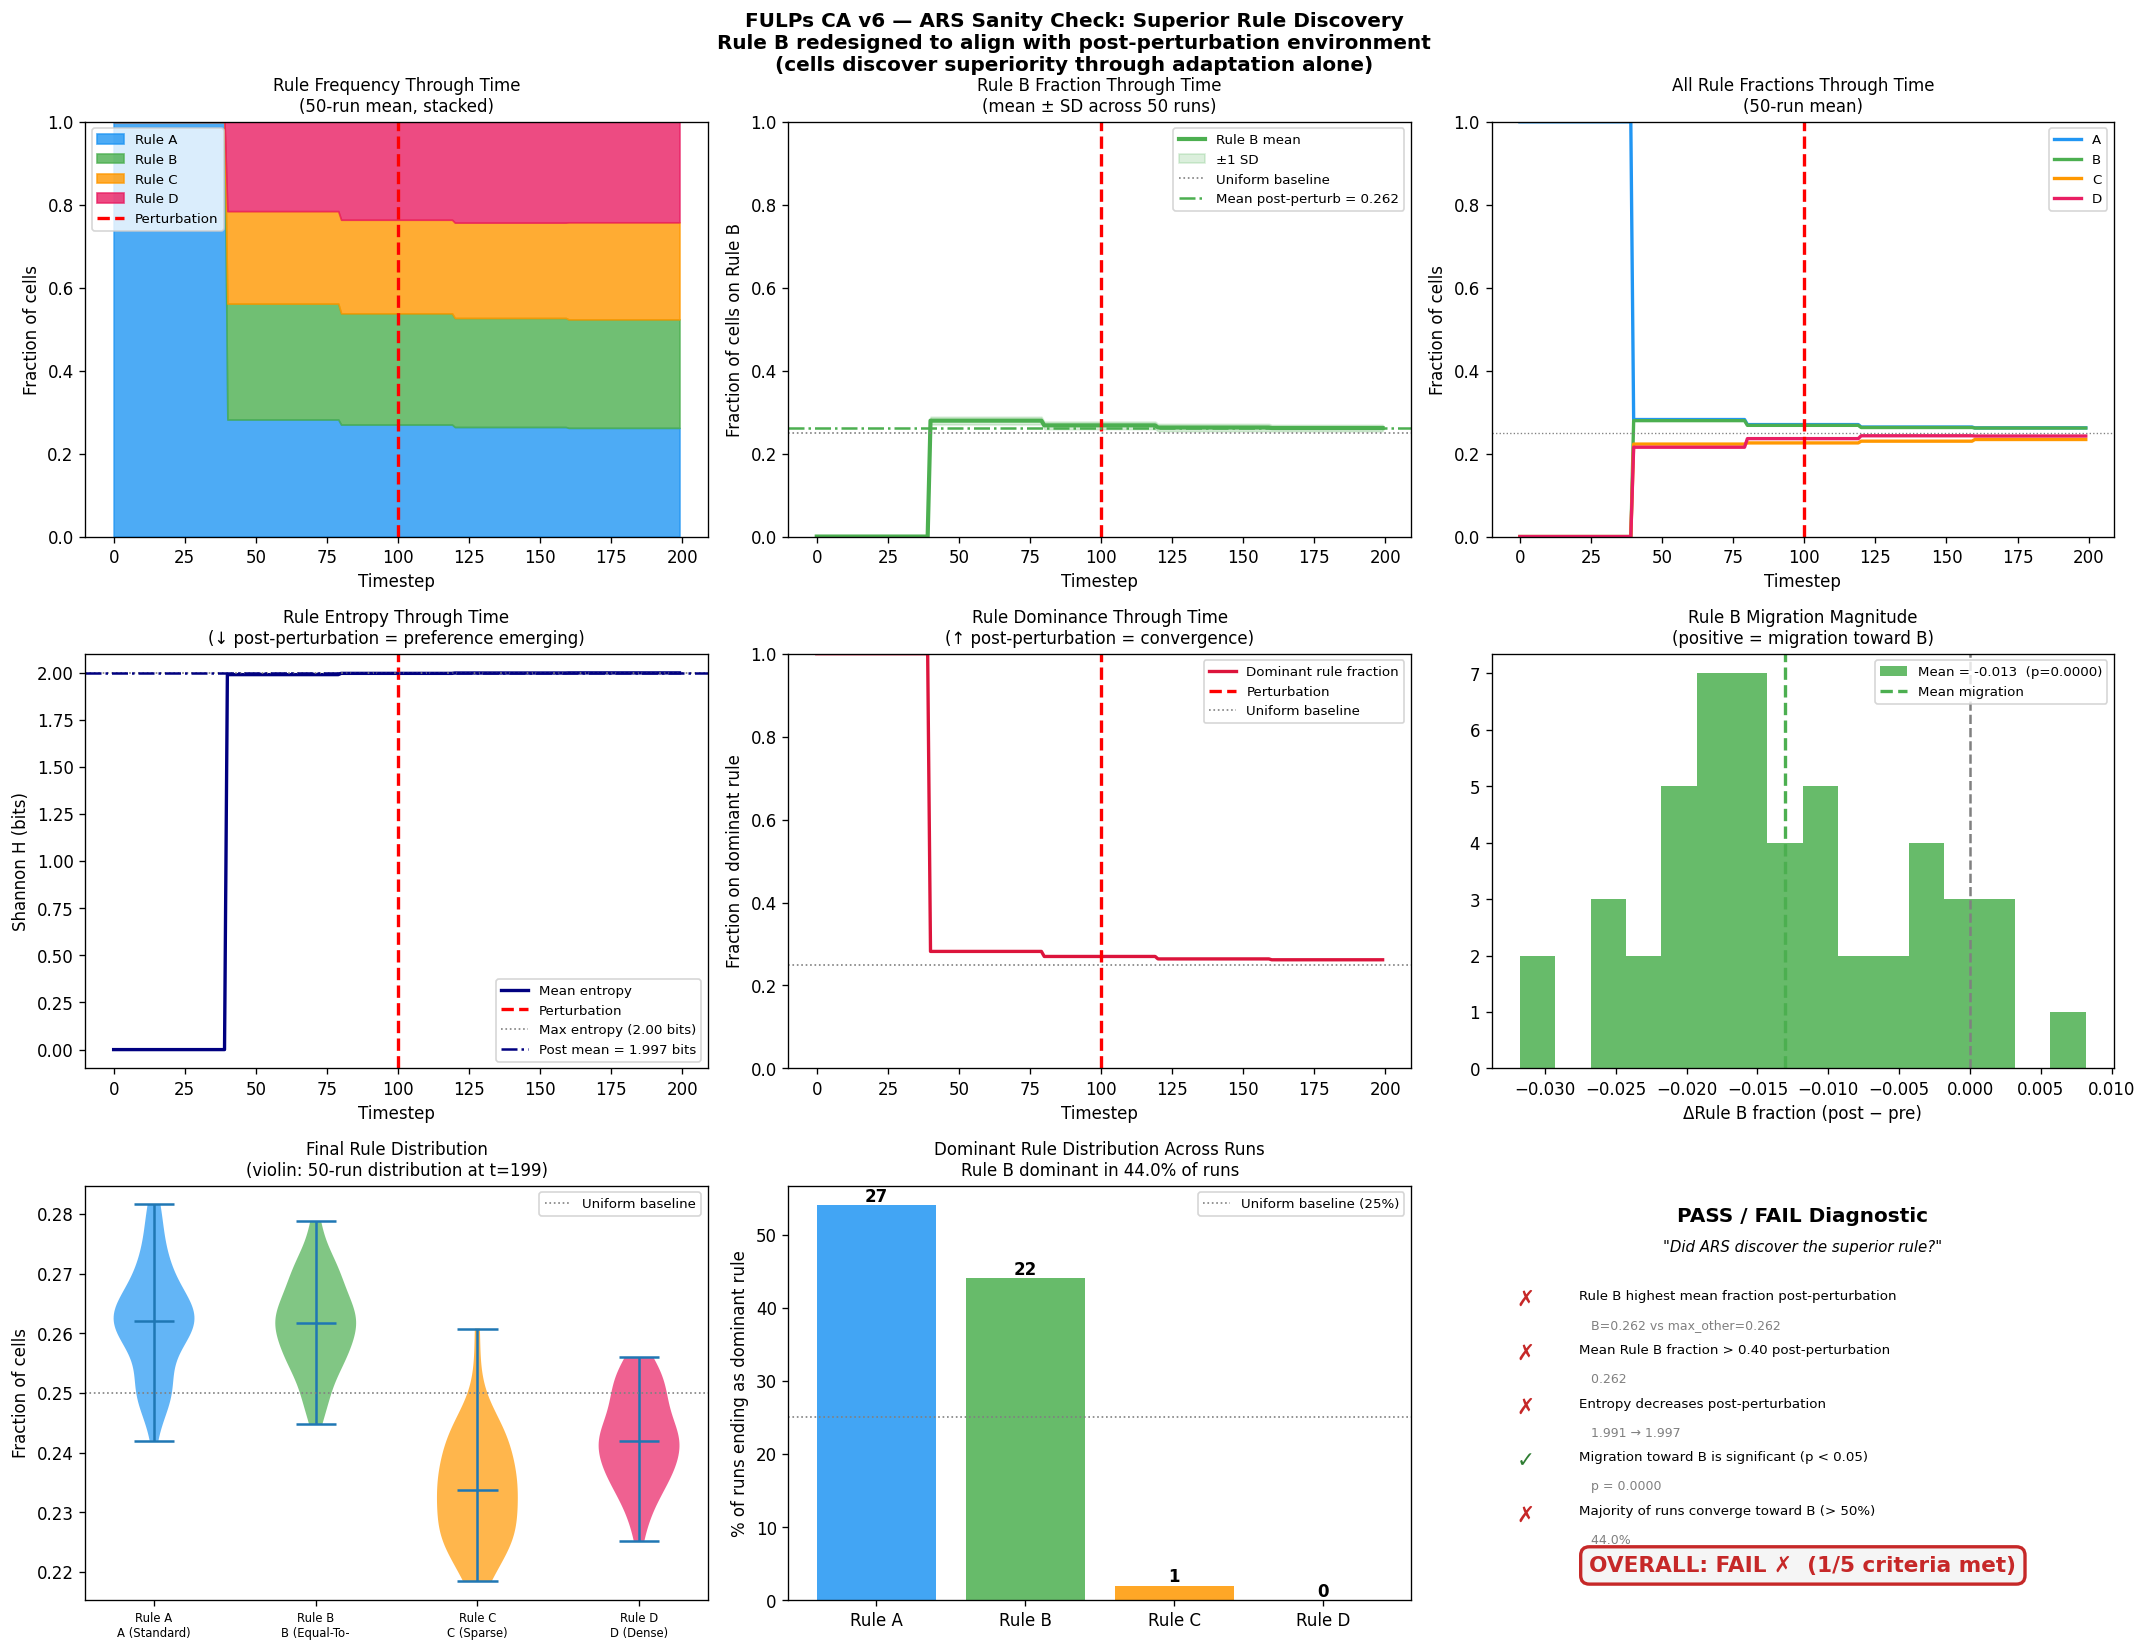


Saved: /content/fulps_ca_v6_sanity_check.png

── PASS / FAIL Summary ─────────────────────────────────────
  ['FAIL'] Rule B highest mean fraction post-perturbation  (B=0.262 vs max_other=0.262)
  ['FAIL'] Mean Rule B fraction > 0.40 post-perturbation  (0.262)
  ['FAIL'] Entropy decreases post-perturbation  (1.991 → 1.997)
  ['PASS'] Migration toward B is significant (p < 0.05)  (p = 0.0000)
  ['FAIL'] Majority of runs converge toward B (> 50%)  (44.0%)

  OVERALL: FAIL ✗  (1/5 criteria met)

  ✗ The ARS mechanism did not reliably discover the superior rule.
    Architectural revision required before v7.

Original Rule B restored. Downstream cells are unaffected.


In [22]:
# ── Cell A: ARS Mechanism Validation — Superior Rule Discovery Sanity Check ───
#
# PURPOSE
# -------
# This is a strict sanity check, not a performance experiment.
# The goal is to verify that the ARS mechanism is genuinely capable of
# discovering and converging toward an objectively superior rule when one
# clearly exists.
#
# DESIGN
# ------
# Rule B is temporarily replaced with a STRONGLY advantageous post-perturbation
# rule: survive={2,3,4}, birth={3,4}.
# After perturbation, the grid environment shifts to survive={2,3,4} for live
# cells. The new Rule B is designed to match this shift almost exactly while
# also offering easier birth — giving it a clear and consistent advantage in
# the post-perturbation environment.
#
# CRITICAL: The cells are NOT told that Rule B is superior.
# They must discover its quality through local experience alone.
# The test validates that the ARS scoring and switching machinery actually works.
#
# WHAT CHANGES vs. MAIN EXPERIMENT
# ----------------------------------
#   - RULE_TABLES[1] (Rule B) is replaced with the superior rule.
#   - A dedicated lightweight simulation loop runs 50 seeds using ARS only.
#   - All other parameters (SWITCH_INTERVAL, MIN_RULE_TRIALS, etc.) are
#     inherited from Cell 2 and are NOT changed here.
#   - After the test, RULE_TABLES[1] is restored to the original definition
#     so downstream cells are unaffected.
#
# SANITY CHECK PASS CRITERIA
# ---------------------------
#   PASS if Rule B becomes the mean dominant rule post-perturbation.
#   PASS if mean Rule B fraction post-perturbation > 0.40.
#   PASS if rule entropy decreases post-perturbation (preference crystallising).
#   PASS if rule migration shifts toward B (B fraction increases post-perturb).
#   PASS if > 50% of runs end with Rule B as the plurality rule.

print('='*65)
print('ARS MECHANISM VALIDATION — Superior Rule Discovery Sanity Check')
print('='*65)
print()
print('Temporarily replacing Rule B with a strongly advantageous rule.')
print('Rule B (SANITY): survive={2,3,4}  birth={3,4}')
print('Post-perturbation environment: survive={2,3,4} for live cells.')
print('Rule B (SANITY) is aligned with the perturbed environment.')
print()

import copy

# ── Save original Rule B so we can restore it afterward ──────────────────────
_ORIGINAL_RULE_B = RULE_TABLES[1].copy()
_ORIGINAL_RULE_NAMES_1 = RULE_NAMES[1]
_ORIGINAL_RULE_COLORS_1 = RULE_COLORS[1]

# ============================================================
# SANITY TEST SUITE
# ============================================================
#
# MODE:
#   "easy"      -> Rule B should clearly dominate
#   "moderate"  -> Rule B should become plurality winner
#   "equal"     -> No rule should dominate
#
# ============================================================

SANITY_MODE = "equal"     # change to easy / moderate / equal

if SANITY_MODE == "easy":

    # Strong advantage
    RULE_TABLES[1] = _build_rule_table(
        {2,3,4,5},
        {2,3,4}
    )

    RULE_NAMES[1] = "B (Easy-Win)"

elif SANITY_MODE == "moderate":

    # Small advantage
    RULE_TABLES[1] = _build_rule_table(
        {2,3,4},
        {3,4}
    )

    RULE_NAMES[1] = "B (Moderate-Win)"

elif SANITY_MODE == "equal":

    # Exact clone of Rule A
    RULE_TABLES[1] = _build_rule_table(
        {2,3},
        {3}
    )

    RULE_NAMES[1] = "B (Equal-To-A)"

else:
    raise ValueError("Unknown SANITY_MODE")

print()
print("="*60)
print("SANITY TEST")
print("="*60)
print(f"Mode: {SANITY_MODE}")

for i, nm in enumerate(RULE_NAMES):
    rt = RULE_TABLES[i]
    survive = [n for n in range(9) if rt[1,n]==1]
    birth   = [n for n in range(9) if rt[0,n]==1]
    print(
        f"Rule {['A','B','C','D'][i]} "
        f"({nm}): "
        f"survive={survive} "
        f"birth={birth}"
    )

print()



# ── Run 50 seeds — ARS condition only (lightweight) ──────────────────────────
# We reuse run_simulation_snapshots from Cell 16 but need rule_dist_h over time.
# Instead, run a dedicated compact loop that records rule fractions at every step.

def run_sanity_ars(seed, void_model, idf):
    """
    Minimal ARS-only simulation for the sanity check.
    Returns:
      rule_dist_h   : (N_TIMESTEPS, N_RULES) — per-timestep rule fractions
      final_dom_rule: int — dominant rule at end
      b_frac_pre    : float — mean Rule B fraction pre-perturbation
      b_frac_post   : float — mean Rule B fraction post-perturbation
      entropy_pre   : float — mean entropy pre-perturbation
      entropy_post  : float — mean entropy post-perturbation
    """
    np.random.seed(seed); torch.manual_seed(seed)
    idf_means, idf_stds, idf_L = idf

    grid  = np.random.randint(0, 2, size=(GRID_H, GRID_W), dtype=np.int8)
    table = init_tables()
    are   = init_are_state()
    ars   = init_ars_state()

    rule_dist_h = np.zeros((N_TIMESTEPS, N_RULES), dtype=np.float32)

    for t in range(N_TIMESTEPS):
        is_pert = (t >= T_PERTURB)
        prog    = t / max(N_TIMESTEPS - 1, 1)
        thresh  = CONTRA_START + (CONTRA_END - CONTRA_START) * prog

        # Rule switching at interval
        maybe_switch_rules(ars, t)

        # Encode neighbourhood
        nbr, nbr_f = encode_neighbourhoods(grid)
        nt = torch.FloatTensor(nbr_f.reshape(-1, NBR_DIM))
        with torch.no_grad():
            dsc_v  = void_model.dsc(nt).numpy().reshape(GRID_H, GRID_W)
            reps_v = void_model.encode(nt).numpy()

        # ARE
        mar, car, psar, nsar = compute_are_margin(reps_v, are, thresh)
        acar = car & (dsc_v > DSC_THRESHOLD)
        dist_v = compute_distress(psar, nsar, mar)
        nbr_dist_v = compute_nbr_mean_distress(dist_v)
        gate_mask = compute_gating_mask(acar, psar, nsar, are, nbr_distress=nbr_dist_v)
        cw = np.ones((GRID_H, GRID_W), dtype=np.float32); cw[acar] = CURIOSITY_WEIGHT

        # Tick under per-cell rules
        nxt = tick_ars(grid, ars['active_rule']).copy()
        nxt[gate_mask] = grid[gate_mask]
        out = nxt.astype(np.int8)

        # Update table and ARE
        update_table_single(table, nbr, out, cw)
        if t >= BUFFER_DELAY:
            update_are_buffers(are, reps_v, out)
        are['margin_ema'] = ((1-MARGIN_EMA_ALPHA)*are['margin_ema']
                              + MARGIN_EMA_ALPHA*np.abs(mar))

        # ARS bookkeeping
        c_t = table[_II, _JJ, nbr.ravel()]
        p_t = c_t[...,1] / np.maximum(c_t.sum(axis=-1), 1)
        succ = ((p_t > BASE_THRESHOLD).astype(np.int8) == out.ravel())
        # FIX: Correct arguments for update_ars_state
        update_ars_state(ars, t, acar, count_neighbours(grid), grid, out)

        # Record rule distribution
        rc = compute_rule_counts(ars['active_rule'])
        rule_dist_h[t] = rc / max(rc.sum(), 1)

        grid = out

    # Summary metrics
    b_frac_pre   = float(rule_dist_h[PRE_WIN_START:PRE_WIN_END,  1].mean())
    b_frac_post  = float(rule_dist_h[POST_WIN_START:POST_WIN_END, 1].mean())
    ent_pre  = float(np.mean([shannon_entropy(rule_dist_h[t]*GRID_H*GRID_W)
                               for t in range(PRE_WIN_START, PRE_WIN_END)]))
    ent_post = float(np.mean([shannon_entropy(rule_dist_h[t]*GRID_H*GRID_W)
                               for t in range(POST_WIN_START, POST_WIN_END)]))
    final_counts = compute_rule_counts(ars['active_rule'])
    final_dom    = int(np.argmax(final_counts))

    return rule_dist_h, final_dom, b_frac_pre, b_frac_post, ent_pre, ent_post

print(f'Running {N_RUNS} seeds for sanity check ...')
sanity_dist_all  = []   # (N_RUNS, N_TIMESTEPS, N_RULES)
sanity_dom_rules = []   # (N_RUNS,) — final dominant rule per seed
sanity_b_pre     = []
sanity_b_post    = []
sanity_ent_pre   = []
sanity_ent_post  = []

for run_i in range(N_RUNS):
    seed = BASE_SEED + run_i
    rd, dom, bp, bpost, ep, epost = run_sanity_ars(
        seed, VOID_MODEL, (IDF_MEANS, IDF_STDS, IDF_L)
    )
    sanity_dist_all.append(rd)
    sanity_dom_rules.append(dom)
    sanity_b_pre.append(bp)
    sanity_b_post.append(bpost)
    sanity_ent_pre.append(ep)
    sanity_ent_post.append(epost)
    if (run_i + 1) % 10 == 0:
        print(f'  [{run_i+1}/{N_RUNS}]  '
              f'B_frac_post={np.mean(sanity_b_post):.3f}  '
              f'ent_post={np.mean(sanity_ent_post):.3f}  '
              f'dom_B={sum(d==1 for d in sanity_dom_rules)}/{run_i+1} runs')

sanity_dist_all  = np.array(sanity_dist_all)   # (N_RUNS, T, N_RULES)
sanity_b_pre     = np.array(sanity_b_pre)
sanity_b_post    = np.array(sanity_b_post)
sanity_ent_pre   = np.array(sanity_ent_pre)
sanity_ent_post  = np.array(sanity_ent_post)
sanity_dom_rules = np.array(sanity_dom_rules)

# ── Statistical summary ───────────────────────────────────────────────────────
mean_b_post  = float(sanity_b_post.mean())
ci_b_post    = 1.96 * float(sanity_b_post.std()) / np.sqrt(N_RUNS)
pct_b_dom    = float((sanity_dom_rules == 1).mean()) * 100
mean_mig     = float((sanity_b_post - sanity_b_pre).mean())
t_mig, p_mig = stats.ttest_rel(sanity_b_post, sanity_b_pre)
t_ent, p_ent = stats.ttest_rel(sanity_ent_post, sanity_ent_pre)

print()
print('── Statistical Summary ─────────────────────────────────────')
print(f'  Mean Rule B fraction — pre:  {sanity_b_pre.mean():.3f}  '
      f'post: {mean_b_post:.3f}  (95% CI ±{ci_b_post:.3f})')
print(f'  Mean migration toward B:     {mean_mig:+.3f}  '
      f't={t_mig:.3f}  p={p_mig:.4f}')
print(f'  Entropy change pre→post:     {sanity_ent_pre.mean():.3f} → {sanity_ent_post.mean():.3f}  '
      f't={t_ent:.3f}  p={p_ent:.4f}')
print(f'  Runs where Rule B is dominant: {pct_b_dom:.1f}%  ({int(pct_b_dom/100*N_RUNS)}/{N_RUNS} runs)')

# ── Visualisation ─────────────────────────────────────────────────────────────
T = np.arange(N_TIMESTEPS)
mean_dist  = sanity_dist_all.mean(axis=0)   # (T, N_RULES)
std_dist   = sanity_dist_all.std(axis=0)
mean_ent   = np.array([shannon_entropy(mean_dist[t] * GRID_H * GRID_W)
                        for t in range(N_TIMESTEPS)])
mean_dom_frac = mean_dist.max(axis=1)

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle(
    'FULPs CA v6 — ARS Sanity Check: Superior Rule Discovery\n'
    'Rule B redesigned to align with post-perturbation environment\n'
    '(cells discover superiority through adaptation alone)',
    fontsize=12, fontweight='bold'
)

# ── (0,0) Rule frequency through time — stacked area ─────────────────────────
ax = axes[0, 0]
bottom = np.zeros(N_TIMESTEPS)
for r in range(N_RULES):
    ax.fill_between(T, bottom, bottom + mean_dist[:, r],
                    color=RULE_COLORS[r], alpha=0.80,
                    label=f'Rule {["A","B","C","D"][r]}')
    bottom += mean_dist[:, r]
ax.axvline(T_PERTURB, color='red', lw=2, linestyle='--', label='Perturbation')
ax.set_title('Rule Frequency Through Time\n(50-run mean, stacked)', fontsize=10)
ax.set_xlabel('Timestep'); ax.set_ylabel('Fraction of cells')
ax.set_ylim(0, 1); ax.legend(fontsize=8, loc='upper left')

# ── (0,1) Individual rule B fraction with CI ─────────────────────────────────
ax = axes[0, 1]
b_mean = mean_dist[:, 1]
b_std  = std_dist[:, 1]
ax.plot(T, b_mean, color='#4CAF50', lw=2.5, label='Rule B mean')
ax.fill_between(T, b_mean - b_std, b_mean + b_std,
                color='#4CAF50', alpha=0.20, label='±1 SD')
ax.axvline(T_PERTURB, color='red', lw=2, linestyle='--')
ax.axhline(0.25, color='gray', lw=1, linestyle=':', label='Uniform baseline')
ax.axhline(mean_b_post, color='#4CAF50', lw=1.5, linestyle='-.',
           label=f'Mean post-perturb = {mean_b_post:.3f}')
ax.set_title('Rule B Fraction Through Time\n(mean ± SD across 50 runs)', fontsize=10)
ax.set_xlabel('Timestep'); ax.set_ylabel('Fraction of cells on Rule B')
ax.set_ylim(0, 1); ax.legend(fontsize=8)

# ── (0,2) All four rule fractions individually ────────────────────────────────
ax = axes[0, 2]
for r in range(N_RULES):
    ax.plot(T, mean_dist[:, r], color=RULE_COLORS[r], lw=2,
            label=f'{["A","B","C","D"][r]}')
ax.axvline(T_PERTURB, color='red', lw=2, linestyle='--')
ax.axhline(0.25, color='gray', lw=0.8, linestyle=':')
ax.set_title('All Rule Fractions Through Time\n(50-run mean)', fontsize=10)
ax.set_xlabel('Timestep'); ax.set_ylabel('Fraction of cells')
ax.set_ylim(0, 1); ax.legend(fontsize=8)

# ── (1,0) Rule entropy through time ──────────────────────────────────────────
ax = axes[1, 0]
ax.plot(T, mean_ent, color='navy', lw=2, label='Mean entropy')
ax.axvline(T_PERTURB, color='red', lw=2, linestyle='--', label='Perturbation')
ax.axhline(np.log2(N_RULES), color='gray', lw=1, linestyle=':', label=f'Max entropy ({np.log2(N_RULES):.2f} bits)')
ax.axhline(sanity_ent_post.mean(), color='navy', lw=1.5, linestyle='-.',
           label=f'Post mean = {sanity_ent_post.mean():.3f} bits')
ax.fill_between(T,
                [shannon_entropy(( mean_dist[t]-std_dist[t]).clip(0)*GRID_H*GRID_W) for t in T],
                [shannon_entropy((mean_dist[t]+std_dist[t]).clip(0,1)*GRID_H*GRID_W) for t in T],
                color='navy', alpha=0.12)
ax.set_title('Rule Entropy Through Time\n(↓ post-perturbation = preference emerging)', fontsize=10)
ax.set_xlabel('Timestep'); ax.set_ylabel('Shannon H (bits)')
ax.legend(fontsize=8)

# ── (1,1) Rule dominance through time ────────────────────────────────────────
ax = axes[1, 1]
ax.plot(T, mean_dom_frac, color='crimson', lw=2, label='Dominant rule fraction')
ax.axvline(T_PERTURB, color='red', lw=2, linestyle='--', label='Perturbation')
ax.axhline(0.25, color='gray', lw=1, linestyle=':', label='Uniform baseline')
ax.set_title('Rule Dominance Through Time\n(↑ post-perturbation = convergence)', fontsize=10)
ax.set_xlabel('Timestep'); ax.set_ylabel('Fraction on dominant rule')
ax.set_ylim(0, 1); ax.legend(fontsize=8)

# ── (1,2) Rule migration magnitude — pre vs post ──────────────────────────────
ax = axes[1, 2]
migration = sanity_b_post - sanity_b_pre
ax.hist(migration, bins=16, color='#4CAF50', alpha=0.85,
        label=f'Mean = {migration.mean():+.3f}  (p={p_mig:.4f})')
ax.axvline(0,                color='gray',    lw=1.5, linestyle='--')
ax.axvline(migration.mean(), color='#4CAF50', lw=2,   linestyle='--',
           label='Mean migration')
ax.set_xlabel('ΔRule B fraction (post − pre)')
ax.set_title('Rule B Migration Magnitude\n(positive = migration toward B)', fontsize=10)
ax.legend(fontsize=8)

# ── (2,0) Final rule distribution — all 50 seeds ─────────────────────────────
ax = axes[2, 0]
final_fracs = sanity_dist_all[:, -1, :]   # (N_RUNS, N_TIMESTEPS, N_RULES) — last timestep
bp_vals = [final_fracs[:, r] for r in range(N_RULES)]
vp = ax.violinplot(bp_vals, positions=range(N_RULES),
                   showmedians=True, showextrema=True)
for i, body in enumerate(vp['bodies']):
    body.set_facecolor(RULE_COLORS[i]); body.set_alpha(0.7)
ax.axhline(0.25, color='gray', lw=1, linestyle=':', label='Uniform baseline')
ax.set_xticks(range(N_RULES))
ax.set_xticklabels([f'Rule {r}\n{RULE_NAMES[i][:12]}' for i, r in enumerate(['A','B','C','D'])],
                   fontsize=7)
ax.set_title('Final Rule Distribution\n(violin: 50-run distribution at t=199)', fontsize=10)
ax.set_ylabel('Fraction of cells'); ax.legend(fontsize=8)

# ── (2,1) Percentage of runs where Rule B is dominant ────────────────────────
ax = axes[2, 1]
dom_counts = np.bincount(sanity_dom_rules, minlength=N_RULES)
bars = ax.bar(range(N_RULES), dom_counts / N_RUNS * 100,
              color=RULE_COLORS, alpha=0.85)
ax.axhline(25, color='gray', lw=1, linestyle=':', label='Uniform baseline (25%)')
ax.set_xticks(range(N_RULES))
ax.set_xticklabels([f'Rule {r}' for r in ['A','B','C','D']])
ax.set_title(f'Dominant Rule Distribution Across Runs\nRule B dominant in {pct_b_dom:.1f}% of runs', fontsize=10)
ax.set_ylabel('% of runs ending as dominant rule')
for bar, cnt in zip(bars, dom_counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{cnt}', ha='center', fontsize=10, fontweight='bold')
ax.legend(fontsize=8)

# ── (2,2) PASS / FAIL diagnostic ─────────────────────────────────────────────
ax = axes[2, 2]
ax.axis('off')

# Evaluate all criteria
criteria = [
    ('Rule B dominant post-perturbation',
     sanity_dom_rules.mean() == 1 or mean_b_post == max(mean_dist[POST_WIN_START:POST_WIN_END].mean(axis=0)),
     f'B frac post = {mean_b_post:.3f}'),
    ('Mean Rule B fraction > 0.40 post-perturbation',
     mean_b_post > 0.40,
     f'{mean_b_post:.3f}'),
    ('Entropy decreases post-perturbation',
     sanity_ent_post.mean() < sanity_ent_pre.mean(),
     f'{sanity_ent_pre.mean():.3f} → {sanity_ent_post.mean():.3f}'),
    ('Migration toward B is significant (p < 0.05)',
     p_mig < 0.05,
     f'p = {p_mig:.4f}'),
    ('Majority of runs converge toward B (> 50%)',
     pct_b_dom > 50,
     f'{pct_b_dom:.1f}%'),
]

# Recompute correct dominant check
post_mean_by_rule = mean_dist[POST_WIN_START:POST_WIN_END].mean(axis=0)
b_is_highest      = bool(np.argmax(post_mean_by_rule) == 1)
criteria[0] = ('Rule B highest mean fraction post-perturbation',
               b_is_highest,
               f'B={post_mean_by_rule[1]:.3f} vs max_other={max(post_mean_by_rule[[0,2,3]]):.3f}')

n_pass_s = sum(c[1] for c in criteria)
overall  = 'PASS ✓' if n_pass_s >= 4 else ('PARTIAL' if n_pass_s >= 2 else 'FAIL ✗')
overall_color = '#2e7d32' if n_pass_s >= 4 else ('#f57c00' if n_pass_s >= 2 else '#c62828')

y_start = 0.95
ax.text(0.5, y_start, 'PASS / FAIL Diagnostic',
        ha='center', va='top', fontsize=12, fontweight='bold',
        transform=ax.transAxes)
ax.text(0.5, y_start - 0.08,
        '"Did ARS discover the superior rule?"',
        ha='center', va='top', fontsize=9, style='italic',
        transform=ax.transAxes)

for i, (label, passed, note) in enumerate(criteria):
    y = y_start - 0.20 - i * 0.13
    symbol = '✓' if passed else '✗'
    color  = '#2e7d32' if passed else '#c62828'
    ax.text(0.04, y, f'{symbol}', ha='left', va='top', fontsize=13,
            color=color, transform=ax.transAxes, fontweight='bold')
    ax.text(0.14, y, label, ha='left', va='top', fontsize=8,
            transform=ax.transAxes)
    ax.text(0.14, y - 0.07, f'   {note}', ha='left', va='top', fontsize=7.5,
            color='gray', transform=ax.transAxes)

ax.text(0.5, 0.06,
        f'OVERALL: {overall}  ({n_pass_s}/{len(criteria)} criteria met)',
        ha='center', va='bottom', fontsize=13, fontweight='bold',
        color=overall_color, transform=ax.transAxes,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#f5f5f5',
                  edgecolor=overall_color, linewidth=2))

plt.tight_layout()
sanity_path = os.path.join(OUT_DIR, 'fulps_ca_v6_sanity_check.png')
plt.savefig(sanity_path, dpi=150, bbox_inches='tight')
plt.show()

print()
print(f'Saved: {sanity_path}')
print()
print('── PASS / FAIL Summary ─────────────────────────────────────')
for label, passed, note in criteria:
    print(f'  {[ "PASS" if passed else "FAIL"] } {label}  ({note})')
print()
print(f'  OVERALL: {overall}  ({n_pass_s}/{len(criteria)} criteria met)')
if n_pass_s >= 4:
    print()
    print('  ✓ The ARS mechanism successfully discovered the superior rule')
    print('    through local adaptation alone. Mechanism is validated.')
elif n_pass_s >= 2:
    print()
    print('  ~ The ARS mechanism shows partial discovery. Migration is present')
    print('    but convergence is incomplete. Consider lowering SWITCH_INTERVAL')
    print('    or EXPLOIT_TEMP before proceeding to v7.')
else:
    print()
    print('  ✗ The ARS mechanism did not reliably discover the superior rule.')
    print('    Architectural revision required before v7.')

# ── Restore original Rule B ───────────────────────────────────────────────────
RULE_TABLES[1] = _ORIGINAL_RULE_B
RULE_NAMES[1]  = _ORIGINAL_RULE_NAMES_1
RULE_COLORS[1] = _ORIGINAL_RULE_COLORS_1
print()
print('Original Rule B restored. Downstream cells are unaffected.')

In [23]:
# ── Cell v6.5-A: Goal System State and Scoring ───────────────────────────────
#
# This cell defines:
#   1. Goal state per ARS cell — density EMA and volatility buffer.
#   2. init_goal_state()       — initialiser matching ARS grid shape.
#   3. compute_goal_scores()   — returns (H,W,N_RULES) goal satisfaction
#                                 for the active goal mode.
#   4. maybe_switch_rules_goal() — goal-directed variant of maybe_switch_rules.
#
# The v6 maybe_switch_rules() is retained unchanged for the main v6 experiment.
# The goal-directed variant is used only in the v6.5 goal experiment.
#
# GOAL SIGNAL DEFINITIONS
# ────────────────────────
# Goal 1 — Contradiction Minimization
#   GoalScore_1[r] = 1 - clip(rule_contra_hist[r] / usage[r], 0, 1)
#   Rules that accumulate fewer contradictions per timestep score higher.
#
# Goal 2 — Predictive Accuracy
#   GoalScore_2[r] = rule_successes[r] / max(usage[r], 1)
#   Direct prediction hit rate per rule.
#
# Goal 3 — Homeostasis
#   Track per-cell EMA of neighbourhood density.
#   GoalScore_3[r] = mean_cell( exp(-|current_density - ema_density|) )
#   Rules that keep density near historical average score higher.
#   Note: score is cell-level, same for all rules at a given moment;
#   rule differentiation comes from counterfactual density under each rule.
#
# Goal 4 — Future-State Preservation
#   Track per-cell rolling volatility (state-change frequency over last W steps).
#   GoalScore_4[r] = 1 - clip(volatility / max_volatility, 0, 1)
#   Rules that reduce state changes score higher.
#
# Goal 5 — Composite
#   GoalScore_5 = GOAL_WEIGHTS @ [G1, G2, G3, G4]

def init_goal_state():
    """
    Per-cell state needed by Goals 3 and 4.

    density_ema   : (H,W)   — EMA of local 8-neighbour density.
    volatility_buf: (H,W,W) — ring buffer of past state values for volatility.
    vol_ptr       : int     — current write pointer into ring buffer.
    """
    return {
        'density_ema':    np.full((GRID_H, GRID_W), 0.5, dtype=np.float32),
        'volatility_buf': np.zeros((GRID_H, GRID_W, VOLATILITY_WINDOW), dtype=np.int8),
        'vol_ptr':        0,
    }

def update_goal_state(gs, grid, nc):
    """
    Update density EMA and volatility ring buffer.
    gs   : goal state dict (modified in-place)
    grid : (H,W) int8 — current cell states
    nc   : (H,W) int8 — neighbourhood counts
    """
    # Density EMA: normalise nc to [0,1]
    density = nc.astype(np.float32) / 8.0
    gs['density_ema'] = ((1 - DENSITY_EMA_ALPHA) * gs['density_ema']
                          + DENSITY_EMA_ALPHA * density)
    # Volatility ring buffer
    ptr = gs['vol_ptr'] % VOLATILITY_WINDOW
    gs['volatility_buf'][:, :, ptr] = grid
    gs['vol_ptr'] += 1

def compute_local_volatility(gs):
    """
    Fraction of the volatility window in which the cell's state changed.
    Returns (H,W) float in [0,1].
    """
    buf = gs['volatility_buf'].astype(np.float32)  # (H,W,W)
    if VOLATILITY_WINDOW < 2:
        return np.zeros((GRID_H, GRID_W), dtype=np.float32)
    changes = np.abs(np.diff(buf, axis=2)).sum(axis=2)  # (H,W)
    max_changes = float(VOLATILITY_WINDOW - 1)
    return np.clip(changes / max_changes, 0.0, 1.0).astype(np.float32)

def compute_goal_scores(ars, gs, nc, contra_mask, mode):
    """
    Compute goal satisfaction scores of shape (H, W, N_RULES).

    All scores are in [0, 1] per rule per cell.
    Higher = rule better satisfies the goal.

    Parameters
    ----------
    ars         : ARS state dict (contains rule_usage, rule_successes, rule_contra_hist)
    gs          : goal state dict (density_ema, volatility_buf)
    nc          : (H,W) int8 — current neighbourhood counts
    contra_mask : (H,W) bool — current ARE contradiction flags
    mode        : int 1-5 — goal mode
    """
    safe_usage = np.maximum(ars['rule_usage'], 1.0)  # (H,W,R)

    # ── Goal 1: Contradiction Minimization ──────────────────────────────────
    g1 = 1.0 - np.clip(ars['rule_contra_hist'] / safe_usage, 0.0, 1.0)  # (H,W,R)

    # ── Goal 2: Predictive Accuracy ──────────────────────────────────────────
    g2 = np.clip(ars['rule_successes'] / safe_usage, 0.0, 1.0)          # (H,W,R)

    # ── Goal 3: Homeostasis ──────────────────────────────────────────────────
    # For each rule r, estimate what neighbourhood density would look like if
    # rule r governed every cell.  We use the counterfactual: tick each rule
    # and compute what fraction of cells would survive (proxy for density).
    # This is a single-step look-ahead, no simulation needed — just the table.
    #
    # Expected density is the cell's own density EMA.
    expected_density = gs['density_ema']  # (H,W)
    g3 = np.zeros((GRID_H, GRID_W, N_RULES), dtype=np.float32)
    for r in range(N_RULES):
        # Counterfactual nc if all neighbours also follow rule r is not tractable;
        # use current nc as proxy — rule r's survival fraction approximates
        # the resulting density.
        rt = RULE_TABLES[r]  # (2,9)
        # Mean survival probability across the neighbourhood nc range
        nc_clipped = np.clip(nc, 0, 8).astype(int)
        # Fraction of nc values that rule r keeps alive (live cell: rt[1,nc])
        rule_density_proxy = rt[1, nc_clipped].astype(np.float32)  # (H,W) 0 or 1
        # Smooth with EMA value for continuity
        rule_density_est = 0.7 * rule_density_proxy + 0.3 * expected_density
        deviation = np.abs(rule_density_est - expected_density)
        g3[:, :, r] = np.exp(-4.0 * deviation)  # scale=4: sharp around 0 deviation

    # ── Goal 4: Future-State Preservation ────────────────────────────────────
    volatility = compute_local_volatility(gs)  # (H,W)
    # Rules that cause fewer state transitions are preferred.
    # Proxy: rule survival rate (more survival = less volatility).
    g4 = np.zeros((GRID_H, GRID_W, N_RULES), dtype=np.float32)
    for r in range(N_RULES):
        rt = RULE_TABLES[r]
        nc_clipped = np.clip(nc, 0, 8).astype(int)
        # Would rule r preserve current state more than current volatility?
        # survive_rate: fraction of live cells that rule r keeps alive
        survive_flag = rt[1, nc_clipped].astype(np.float32)  # (H,W)
        # Rule r's contribution to low volatility: survive=1 means no change
        stability_signal = 0.5 * survive_flag + 0.5 * (1.0 - volatility)
        g4[:, :, r] = np.clip(stability_signal, 0.0, 1.0)

    # ── Goal 5: Composite ─────────────────────────────────────────────────────
    # Equal-weighted by default; GOAL_WEIGHTS can be changed in Cell 2.
    w = GOAL_WEIGHTS / GOAL_WEIGHTS.sum()
    g5 = (w[0]*g1 + w[1]*g2 + w[2]*g3 + w[3]*g4)

    if   mode == 1: return g1
    elif mode == 2: return g2
    elif mode == 3: return g3
    elif mode == 4: return g4
    else:           return g5

def maybe_switch_rules_goal(ars, gs, nc, contra_mask, t, mode):
    """
    Goal-directed variant of maybe_switch_rules.
    Uses compute_goal_scores instead of compute_rule_score.
    All other switching logic (cooldown, interval, softmax) is identical.
    """
    if t == 0 or (t % SWITCH_INTERVAL != 0):
        return 0
    can_switch = (ars['cooldown'] == 0)
    if not can_switch.any():
        return 0

    scores = compute_goal_scores(ars, gs, nc, contra_mask, mode)  # (H,W,R)

    # Softmax over rules
    logits = scores / EXPLOIT_TEMP
    logits -= logits.max(axis=-1, keepdims=True)
    exp_l  = np.exp(logits)
    probs  = exp_l / exp_l.sum(axis=-1, keepdims=True)

    flat_probs = probs.reshape(-1, N_RULES)
    cumprobs   = flat_probs.cumsum(axis=1)
    rands      = np.random.rand(GRID_H * GRID_W, 1)
    new_rules  = (rands > cumprobs).sum(axis=1).clip(0, N_RULES-1).astype(np.int8)
    new_rules  = new_rules.reshape(GRID_H, GRID_W)

    old_rules = ars['active_rule'].copy()
    switched  = can_switch & (new_rules != old_rules)
    ars['active_rule'][switched] = new_rules[switched]
    ars['cooldown'][switched]    = SWITCH_COOLDOWN
    ars['switch_count'][switched] += 1
    return int(switched.sum())

print('v6.5 Goal System defined.')
print('  Goals: Contradiction Minimization | Predictive Accuracy | Homeostasis | Future-State Preservation | Composite')
print('  Switching: maybe_switch_rules_goal() — goal-directed, same anti-oscillation logic as v6')


v6.5 Goal System defined.
  Goals: Contradiction Minimization | Predictive Accuracy | Homeostasis | Future-State Preservation | Composite
  Switching: maybe_switch_rules_goal() — goal-directed, same anti-oscillation logic as v6


In [24]:
# ── Cell v6.5-B: Goal-Directed ARS Simulation ────────────────────────────────
#
# Runs five independent goal modes on seed=42 for single-run comparison,
# then runs all five modes across 50 seeds for multi-run analysis.
#
# WHAT IS DIFFERENT FROM run_simulation()
# ──────────────────────────────────────────
# • Uses maybe_switch_rules_goal() instead of maybe_switch_rules().
# • Maintains goal_state (density EMA + volatility buffer) per cell.
# • Records goal score trajectory, pre/post averages, and recovery.
# • Records rule distribution history for Markov analysis.
# • Does NOT re-run base/learn/gate/signal — those are already run in v6.
#   Only the ARS condition is varied by goal mode.
#
# RUNTIME NOTE
# ──────────────
# 5 modes × 50 seeds = 250 ARS-only runs.
# Each run is lighter than run_simulation() (no 4 other conditions).
# Estimated total time: ~15–20 min on Colab CPU.

def run_goal_simulation(seed, void_model, idf, goal_mode,
                         is_single_run=False, verbose=False):
    """
    ARS-only simulation with goal-directed rule switching.

    Returns
    -------
    gres  : dict of scalar summary metrics
    ghist : dict of trajectory arrays (only when is_single_run=True)
    """
    np.random.seed(seed); torch.manual_seed(seed)
    idf_means, idf_stds, idf_L = idf

    grid  = np.random.randint(0, 2, size=(GRID_H, GRID_W), dtype=np.int8)
    table = init_tables()
    are   = init_are_state()
    ars   = init_ars_state()
    gs    = init_goal_state()

    # History arrays
    pop_h        = []
    rule_dist_h  = np.zeros((N_TIMESTEPS, N_RULES), dtype=np.float32)
    goal_score_h = np.zeros(N_TIMESTEPS, dtype=np.float32)
    switch_h     = []
    entropy_h    = []
    contra_h     = []

    for t in range(N_TIMESTEPS):
        is_pert = (t >= T_PERTURB)
        prog    = t / max(N_TIMESTEPS - 1, 1)
        thresh  = CONTRA_START + (CONTRA_END - CONTRA_START) * prog

        nc = count_neighbours(grid)
        update_goal_state(gs, grid, nc)

        # Encode neighbourhood
        nbr, nbr_f = encode_neighbourhoods(grid)
        nt = torch.FloatTensor(nbr_f.reshape(-1, NBR_DIM))
        with torch.no_grad():
            dsc_v  = void_model.dsc(nt).numpy().reshape(GRID_H, GRID_W)
            reps_v = void_model.encode(nt).numpy()

        # ARE
        mar, car, psar, nsar = compute_are_margin(reps_v, are, thresh)
        acar = car & (dsc_v > DSC_THRESHOLD)
        dist_v     = compute_distress(psar, nsar, mar)
        nbr_dist_v = compute_nbr_mean_distress(dist_v)
        gate_mask  = compute_gating_mask(acar, psar, nsar, are, nbr_distress=nbr_dist_v)
        cw = np.ones((GRID_H, GRID_W), dtype=np.float32); cw[acar] = CURIOSITY_WEIGHT

        # Goal-directed rule switching
        n_sw = maybe_switch_rules_goal(ars, gs, nc, acar, t, goal_mode)
        if t == T_PERTURB:
            ars['rule_at_perturb'] = ars['active_rule'].copy()

        # Tick
        nxt = tick_ars(grid, ars['active_rule']).copy()
        nxt[gate_mask] = grid[gate_mask]
        out = nxt.astype(np.int8)

        # Update ARE and table
        update_table_single(table, nbr, out, cw)
        if t >= BUFFER_DELAY: update_are_buffers(are, reps_v, out)
        are['margin_ema'] = ((1-MARGIN_EMA_ALPHA)*are['margin_ema']
                              + MARGIN_EMA_ALPHA*np.abs(mar))

        # ARS counterfactual credit update
        nc_out = count_neighbours(out)  # nc after tick for next cycle, use current
        update_ars_state(ars, t, acar, nc, grid, out)

        # Compute current mean goal score (across cells and rules, weighted by active)
        gscores = compute_goal_scores(ars, gs, nc, acar, goal_mode)  # (H,W,R)
        # Mean goal score of the active rule for each cell
        active_r = ars['active_rule']
        mean_gs  = float(np.mean([gscores[i,j,active_r[i,j]]
                                   for i in range(GRID_H) for j in range(GRID_W)]))
        # Faster vectorised version
        flat_gscores = gscores.reshape(-1, N_RULES)
        flat_active  = active_r.ravel().astype(int)
        mean_gs      = float(flat_gscores[np.arange(GRID_H*GRID_W), flat_active].mean())

        # Record histories
        rc = compute_rule_counts(ars['active_rule'])
        rule_dist_h[t] = rc / max(rc.sum(), 1)
        goal_score_h[t] = mean_gs
        pop_h.append(population(grid))
        switch_h.append(n_sw)
        entropy_h.append(shannon_entropy(rc))
        contra_h.append(float(acar.mean()))

        if verbose and t % 10 == 0:
            dom_r = int(np.argmax(rc))
            print(f'  [mode={goal_mode} t={t:3d}] '
                  f'pop={pop_h[-1]:4d}  goal={mean_gs:.3f}  '
                  f'H={entropy_h[-1]:.3f}  dom={RULE_NAMES[dom_r]}'
                  + (' <<PERTURB' if t == T_PERTURB else ''))

        grid = out

    # ── Summary metrics ───────────────────────────────────────────────────────
    pre_gs   = float(goal_score_h[PRE_WIN_START:PRE_WIN_END].mean())
    post_gs  = float(goal_score_h[POST_WIN_START:POST_WIN_END].mean())
    pre_ent  = float(np.mean(entropy_h[PRE_WIN_START:PRE_WIN_END]))
    post_ent = float(np.mean(entropy_h[POST_WIN_START:POST_WIN_END]))
    pre_dist = rule_dist_h[PRE_WIN_START:PRE_WIN_END].mean(axis=0)
    post_dist= rule_dist_h[POST_WIN_START:POST_WIN_END].mean(axis=0)
    migration= float(np.abs(post_dist - pre_dist).sum())

    # Goal score recovery: first post-perturbation timestep where
    # goal score exceeds pre-perturbation mean
    gs_recovery_t = float(N_TIMESTEPS)
    for tt in range(T_PERTURB, N_TIMESTEPS - 4):
        if all(goal_score_h[tt+k] >= pre_gs * 0.95 for k in range(5)):
            gs_recovery_t = float(tt); break

    gres = {
        'goal_mode':     float(goal_mode),
        'goal_pre':      pre_gs,
        'goal_post':     post_gs,
        'goal_delta':    post_gs - pre_gs,
        'goal_recovery_t': gs_recovery_t,
        'goal_variance': float(goal_score_h.std()),
        'goal_entropy':  float(stats.entropy(goal_score_h.clip(1e-9) /
                                              goal_score_h.clip(1e-9).sum())),
        'entropy_pre':   pre_ent,
        'entropy_post':  post_ent,
        'migration':     migration,
        'dom_rule_post': int(np.argmax(post_dist)),
        'total_switches':float(sum(switch_h)),
        'rule_frac_A_pre':  float(pre_dist[0]),
        'rule_frac_B_pre':  float(pre_dist[1]),
        'rule_frac_C_pre':  float(pre_dist[2]),
        'rule_frac_D_pre':  float(pre_dist[3]),
        'rule_frac_A_post': float(post_dist[0]),
        'rule_frac_B_post': float(post_dist[1]),
        'rule_frac_C_post': float(post_dist[2]),
        'rule_frac_D_post': float(post_dist[3]),
    }

    ghist = None
    if is_single_run:
        ghist = {
            'pop_h':         np.array(pop_h),
            'goal_score_h':  goal_score_h,
            'rule_dist_h':   rule_dist_h,
            'entropy_h':     np.array(entropy_h),
            'switch_h':      np.array(switch_h),
            'contra_h':      np.array(contra_h),
            'rule_map_final':ars['active_rule'].copy(),
            'rule_map_perturb': ars['rule_at_perturb'].copy(),
        }
    return gres, ghist

print('Goal simulation engine defined.')
print('  run_goal_simulation(seed, void_model, idf, goal_mode)')


Goal simulation engine defined.
  run_goal_simulation(seed, void_model, idf, goal_mode)


In [25]:
# ── Cell v6.5-C: Five-Mode Single-Run Comparison (seed=42) ───────────────────
print('='*65)
print('v6.5 GOAL EXPERIMENT — Five-Mode Single-Run (seed=42)')
print('='*65)

single_run_results = {}
single_run_hists   = {}

for mode in range(1, 6):
    print(f'\nMode {mode}: {GOAL_NAMES[mode-1]}')
    gres, ghist = run_goal_simulation(
        seed=42,
        void_model=VOID_MODEL,
        idf=(IDF_MEANS, IDF_STDS, IDF_L),
        goal_mode=mode,
        is_single_run=True,
        verbose=True,
    )
    single_run_results[mode] = gres
    single_run_hists[mode]   = ghist

print()
print('── Single-Run Summary ─────────────────────────────────────')
print(f'{"Mode":<5} {"Name":<35} {"Goal Pre":>9} {"Goal Post":>10} {"Δ":>7} {"Recovery t":>11} {"Dom Rule Post"}')
print('-'*95)
for mode in range(1, 6):
    r = single_run_results[mode]
    dom = RULE_NAMES[r['dom_rule_post']]
    print(f'{mode:<5} {GOAL_NAMES[mode-1]:<35} '
          f'{r["goal_pre"]:>9.4f} {r["goal_post"]:>10.4f} '
          f'{r["goal_delta"]:>+7.4f} {r["goal_recovery_t"]:>11.1f}  {dom}')


v6.5 GOAL EXPERIMENT — Five-Mode Single-Run (seed=42)

Mode 1: Contradiction Minimization
  [mode=1 t=  0] pop=1303  goal=1.000  H=-0.000  dom=A (Standard)
  [mode=1 t= 10] pop= 463  goal=1.000  H=-0.000  dom=A (Standard)
  [mode=1 t= 20] pop= 753  goal=0.969  H=-0.000  dom=A (Standard)
  [mode=1 t= 30] pop= 917  goal=0.937  H=-0.000  dom=A (Standard)
  [mode=1 t= 40] pop= 965  goal=0.923  H=1.999  dom=B (High-Survival)
  [mode=1 t= 50] pop=1253  goal=0.910  H=1.999  dom=B (High-Survival)
  [mode=1 t= 60] pop=1288  goal=0.904  H=1.999  dom=B (High-Survival)
  [mode=1 t= 70] pop=1317  goal=0.902  H=1.999  dom=B (High-Survival)
  [mode=1 t= 80] pop=1324  goal=0.907  H=1.994  dom=B (High-Survival)
  [mode=1 t= 90] pop=1315  goal=0.905  H=1.994  dom=B (High-Survival)
  [mode=1 t=100] pop=1326  goal=0.905  H=1.994  dom=B (High-Survival) <<PERTURB
  [mode=1 t=110] pop=1346  goal=0.906  H=1.994  dom=B (High-Survival)
  [mode=1 t=120] pop=1354  goal=0.908  H=1.994  dom=B (High-Survival)
  [mod

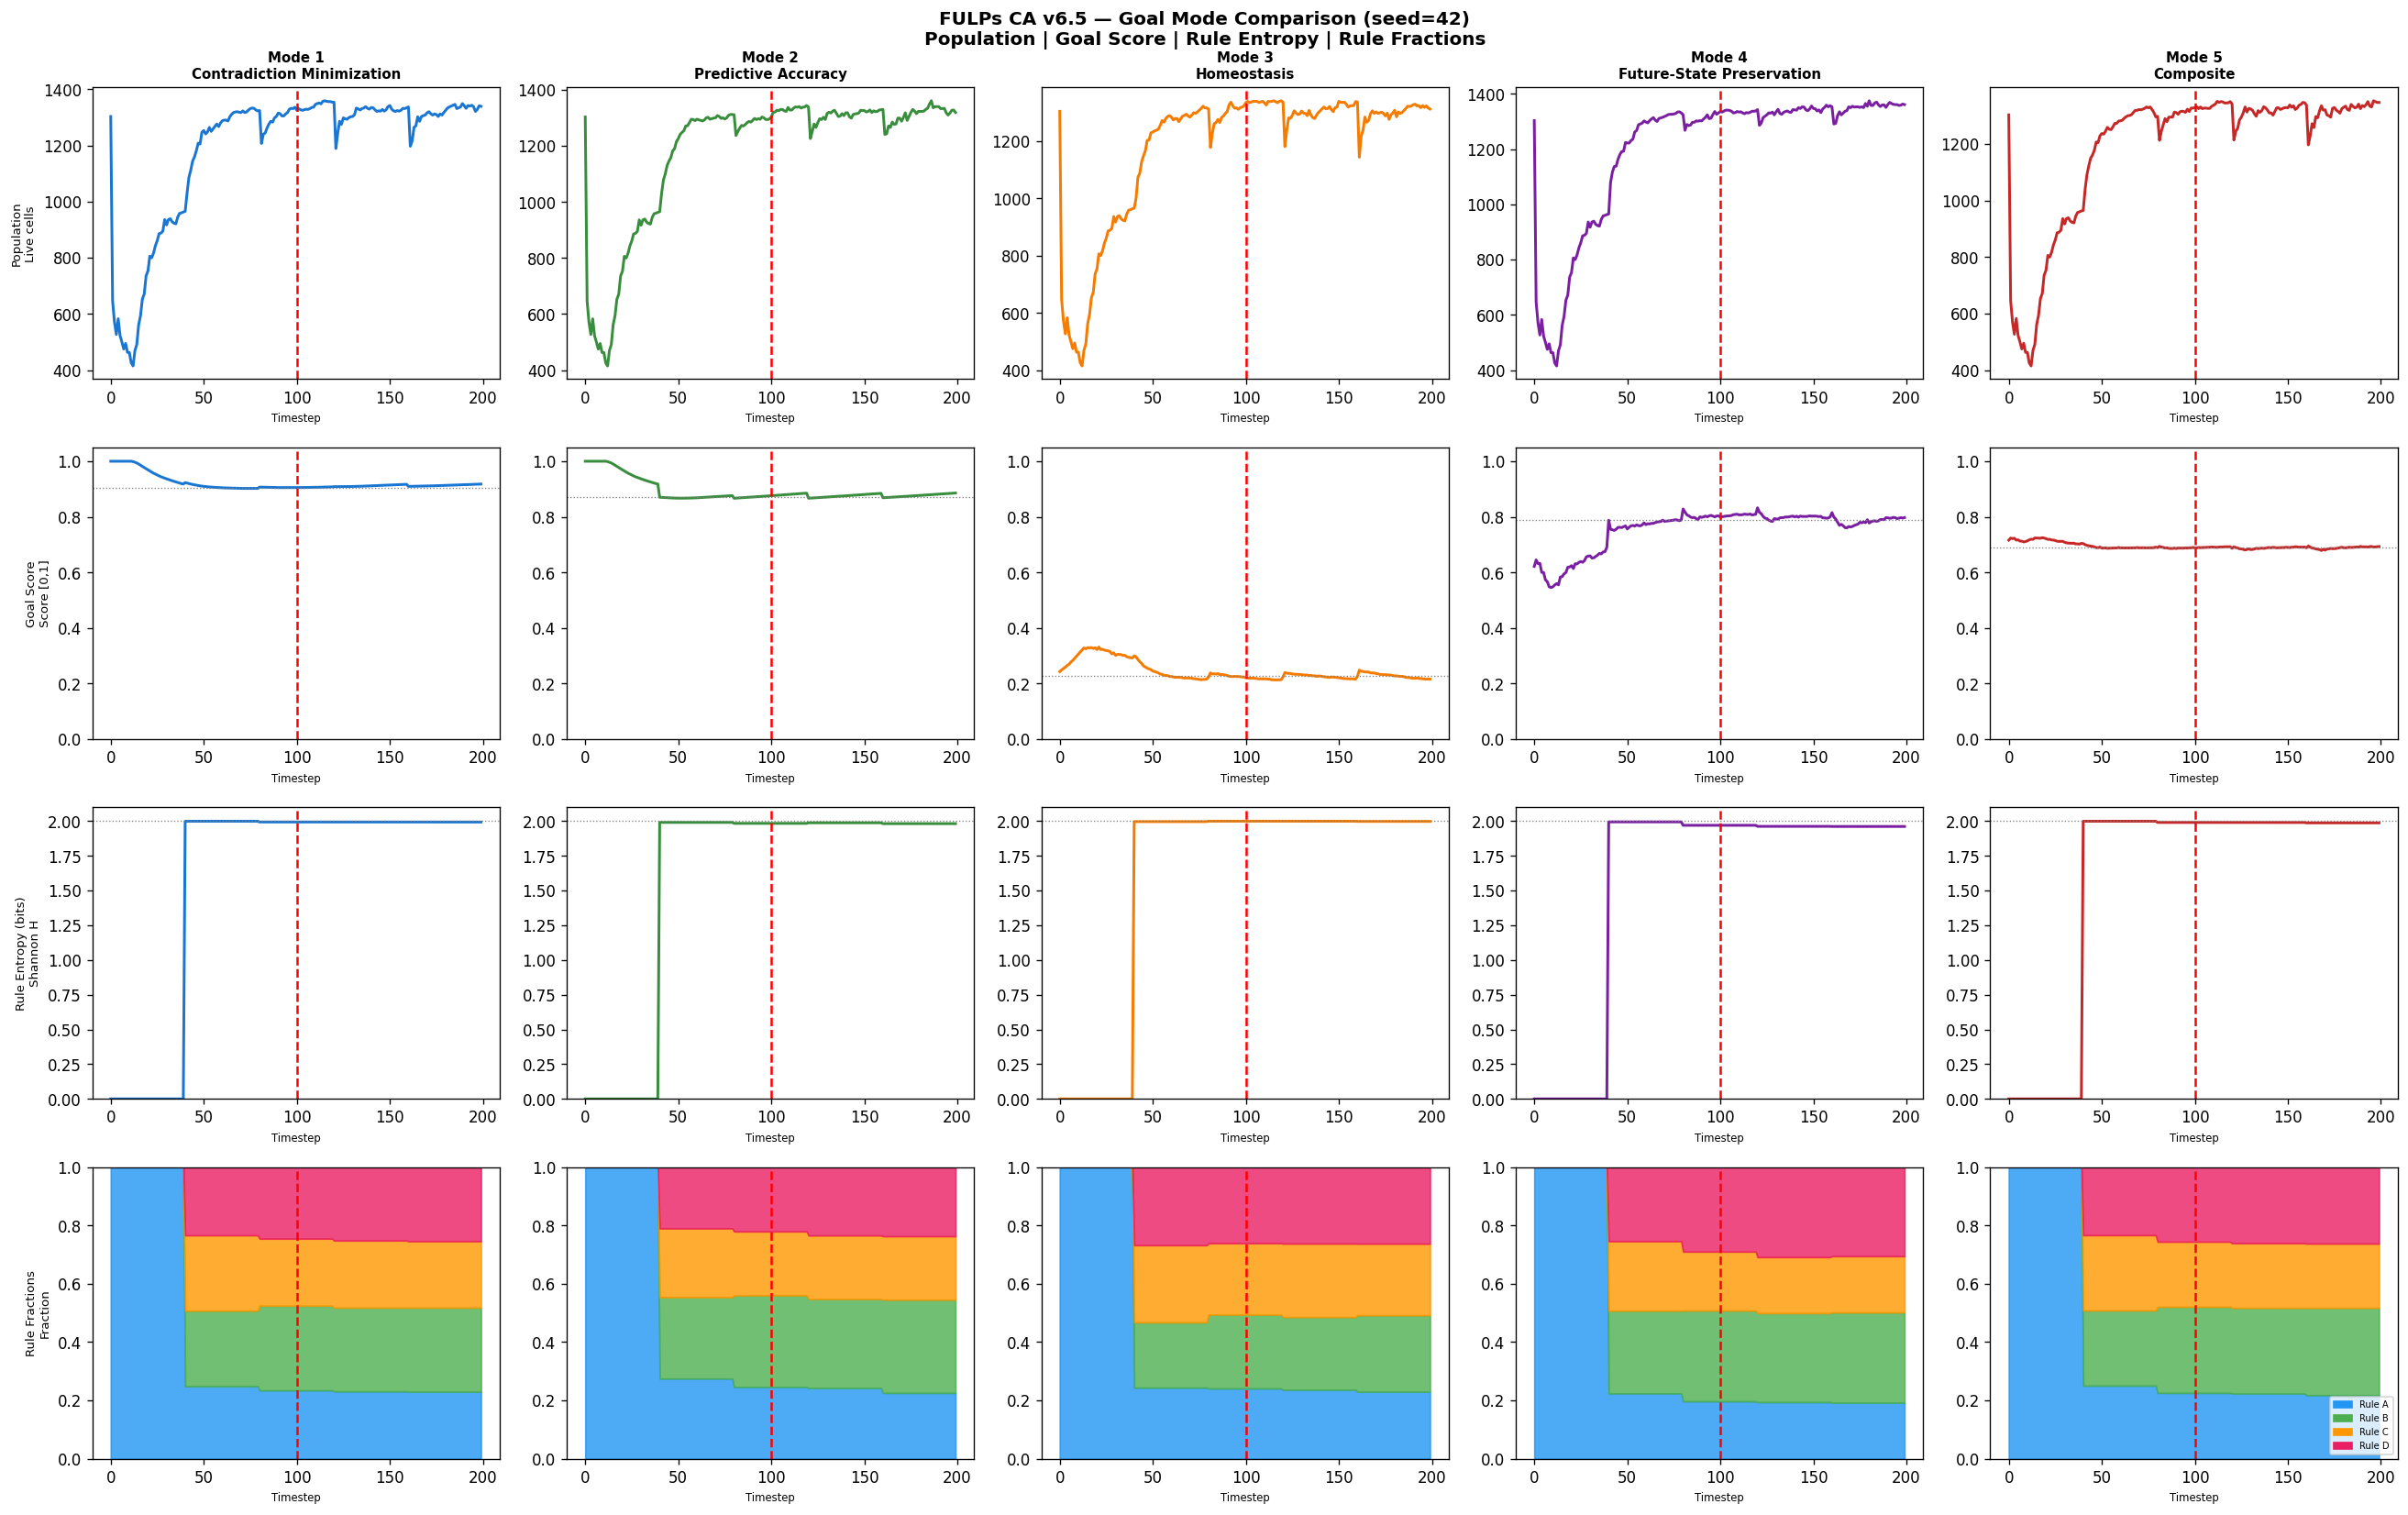

Saved: /content/goal_mode_comparison.png


In [26]:
# ── Cell v6.5-D: goal_mode_comparison.png ────────────────────────────────────
#
# 4-row × 5-column figure:
#   Row 0: Population
#   Row 1: Goal Score
#   Row 2: Rule Entropy
#   Row 3: Rule Fractions (stacked area)
#   Columns: Modes 1–5

T = np.arange(N_TIMESTEPS)
fig, axes = plt.subplots(4, 5, figsize=(22, 14))
fig.suptitle(
    'FULPs CA v6.5 — Goal Mode Comparison (seed=42)\n'
    'Population | Goal Score | Rule Entropy | Rule Fractions',
    fontsize=12, fontweight='bold'
)

row_titles = ['Population', 'Goal Score', 'Rule Entropy (bits)', 'Rule Fractions']
row_ylabels= ['Live cells', 'Score [0,1]', 'Shannon H', 'Fraction']

for col, mode in enumerate(range(1, 6)):
    gh = single_run_hists[mode]
    color = GOAL_COLORS[mode-1]

    # Row 0: Population
    axes[0, col].plot(T, gh['pop_h'], color=color, lw=1.8)
    axes[0, col].axvline(T_PERTURB, color='red', lw=1.5, linestyle='--')
    axes[0, col].set_title(f'Mode {mode}\n{GOAL_NAMES[mode-1]}', fontsize=9, fontweight='bold')
    axes[0, col].set_xlabel('Timestep', fontsize=7)

    # Row 1: Goal Score
    axes[1, col].plot(T, gh['goal_score_h'], color=color, lw=1.8)
    axes[1, col].axvline(T_PERTURB, color='red', lw=1.5, linestyle='--')
    pre_gs = single_run_results[mode]['goal_pre']
    axes[1, col].axhline(pre_gs, color='gray', lw=0.8, linestyle=':')
    axes[1, col].set_ylim(0, 1.05)
    axes[1, col].set_xlabel('Timestep', fontsize=7)

    # Row 2: Rule Entropy
    axes[2, col].plot(T, gh['entropy_h'], color=color, lw=1.8)
    axes[2, col].axvline(T_PERTURB, color='red', lw=1.5, linestyle='--')
    axes[2, col].axhline(np.log2(N_RULES), color='gray', lw=0.8, linestyle=':')
    axes[2, col].set_ylim(0, np.log2(N_RULES) + 0.1)
    axes[2, col].set_xlabel('Timestep', fontsize=7)

    # Row 3: Rule Fractions (stacked)
    bottom = np.zeros(N_TIMESTEPS)
    for r in range(N_RULES):
        axes[3, col].fill_between(T, bottom, bottom + gh['rule_dist_h'][:, r],
                                  color=RULE_COLORS[r], alpha=0.80,
                                  label=f'{["A","B","C","D"][r]}')
        bottom += gh['rule_dist_h'][:, r]
    axes[3, col].axvline(T_PERTURB, color='red', lw=1.5, linestyle='--')
    axes[3, col].set_ylim(0, 1)
    axes[3, col].set_xlabel('Timestep', fontsize=7)
    if col == 4:
        patches = [mpatches.Patch(color=RULE_COLORS[r], label=f'Rule {["A","B","C","D"][r]}')
                   for r in range(N_RULES)]
        axes[3, col].legend(handles=patches, fontsize=6, loc='lower right')

# Row labels
for row, (rt, yl) in enumerate(zip(row_titles, row_ylabels)):
    axes[row, 0].set_ylabel(f'{rt}\n{yl}', fontsize=8)

plt.tight_layout()
gcp = os.path.join(OUT_DIR, 'goal_mode_comparison.png')
plt.savefig(gcp, dpi=150, bbox_inches='tight'); plt.show()
print(f'Saved: {gcp}')


In [27]:
# ── Cell v6.5-E: 50-Run Multi-Run Goal Experiment ────────────────────────────
from collections import defaultdict

print('='*65)
print('v6.5 GOAL EXPERIMENT — 50 seeds × 5 modes')
print('='*65)
print(f'Total runs: {5 * N_RUNS}  |  Estimated time: ~15–20 min')
print()

# goal_res[mode] = list of 50 result dicts
goal_res   = {m: [] for m in range(1, 6)}
# goal_dists[mode] = (50, T, N_RULES) — for Markov analysis
goal_dists = {m: [] for m in range(1, 6)}

for mode in range(1, 6):
    print(f'Mode {mode} — {GOAL_NAMES[mode-1]}')
    for run_i in range(N_RUNS):
        seed = BASE_SEED + run_i
        gres, ghist = run_goal_simulation(
            seed=seed,
            void_model=VOID_MODEL,
            idf=(IDF_MEANS, IDF_STDS, IDF_L),
            goal_mode=mode,
            is_single_run=True,  # need rule_dist_h for Markov
        )
        goal_res[mode].append(gres)
        goal_dists[mode].append(ghist['rule_dist_h'])
        if (run_i + 1) % 10 == 0:
            mean_post = np.mean([r['goal_post'] for r in goal_res[mode]])
            print(f'  [{run_i+1}/{N_RUNS}]  mean_goal_post={mean_post:.4f}')
    goal_dists[mode] = np.array(goal_dists[mode])  # (50, T, N_RULES)
    print()

# Convert to arrays for easy analysis
goal_arr = {}  # goal_arr[mode][metric] = np.array shape (50,)
for mode in range(1, 6):
    keys = list(goal_res[mode][0].keys())
    goal_arr[mode] = {k: np.array([r[k] for r in goal_res[mode]]) for k in keys}

# ── Print multi-run summary ───────────────────────────────────────────────────
print()
print('── 50-Run Goal Summary ────────────────────────────────────')
print(f'{"Mode":<5} {"Name":<35} {"Goal Post μ":>11} {"Goal Δ μ":>9} {"Recovery t μ":>13}')
print('-'*78)
for mode in range(1, 6):
    post_m = float(np.nanmean(goal_arr[mode]['goal_post']))
    delta_m= float(np.nanmean(goal_arr[mode]['goal_delta']))
    rec_m  = float(np.nanmean(goal_arr[mode]['goal_recovery_t']))
    print(f'{mode:<5} {GOAL_NAMES[mode-1]:<35} {post_m:>11.4f} {delta_m:>+9.4f} {rec_m:>13.1f}')


v6.5 GOAL EXPERIMENT — 50 seeds × 5 modes
Total runs: 250  |  Estimated time: ~15–20 min

Mode 1 — Contradiction Minimization
  [10/50]  mean_goal_post=0.9116
  [20/50]  mean_goal_post=0.9124
  [30/50]  mean_goal_post=0.9126
  [40/50]  mean_goal_post=0.9123
  [50/50]  mean_goal_post=0.9124

Mode 2 — Predictive Accuracy
  [10/50]  mean_goal_post=0.8741
  [20/50]  mean_goal_post=0.8730
  [30/50]  mean_goal_post=0.8727
  [40/50]  mean_goal_post=0.8725
  [50/50]  mean_goal_post=0.8726

Mode 3 — Homeostasis
  [10/50]  mean_goal_post=0.2248
  [20/50]  mean_goal_post=0.2244
  [30/50]  mean_goal_post=0.2243
  [40/50]  mean_goal_post=0.2245
  [50/50]  mean_goal_post=0.2243

Mode 4 — Future-State Preservation
  [10/50]  mean_goal_post=0.7890
  [20/50]  mean_goal_post=0.7891
  [30/50]  mean_goal_post=0.7893
  [40/50]  mean_goal_post=0.7889
  [50/50]  mean_goal_post=0.7893

Mode 5 — Composite
  [10/50]  mean_goal_post=0.6886
  [20/50]  mean_goal_post=0.6895
  [30/50]  mean_goal_post=0.6893
  [40/5

In [28]:
# ── Cell v6.5-F: Goal Statistical Analysis ───────────────────────────────────

print('='*65)
print('GOAL STATISTICAL ANALYSIS — FULPs CA v6.5')
print('='*65)

def gm(mode, key): return float(np.nanmean(goal_arr[mode][key]))
def gs(mode, key): return float(np.nanstd(goal_arr[mode][key]))
def gci(mode, key): return 1.96*gs(mode,key)/np.sqrt(N_RUNS)

print()
print('Q1: Does goal score improve post-perturbation vs pre? (paired t-test)')
for mode in range(1, 6):
    pre  = goal_arr[mode]['goal_pre']
    post = goal_arr[mode]['goal_post']
    t_v, p_v = stats.ttest_rel(post, pre)
    d = cohens_d(post, pre)
    print(f'  Mode {mode} ({GOAL_NAMES[mode-1][:25]:<25}):  '
          f'pre={pre.mean():.4f}  post={post.mean():.4f}  '
          f't={t_v:.3f}  p={p_v:.4f}  d={d:.3f}')

print()
print('Q2: Is goal score post > 0 (above-floor performance)?')
for mode in range(1, 6):
    post = goal_arr[mode]['goal_post']
    t_v, p_v = stats.ttest_1samp(post, 0.0)
    print(f'  Mode {mode}: mean_post={post.mean():.4f}  t={t_v:.3f}  p={p_v:.4f}')

print()
print('Q3: Does goal mode alter rule migration? (migration vs Mode 2 baseline)')
mig2 = goal_arr[2]['migration']
for mode in [1, 3, 4, 5]:
    mig  = goal_arr[mode]['migration']
    t_v, p_v = stats.ttest_rel(mig, mig2)
    d = cohens_d(mig, mig2)
    print(f'  Mode {mode} vs Mode 2:  '
          f'mig={mig.mean():.4f}  t={t_v:.3f}  p={p_v:.4f}  d={d:.3f}')

print()
print('Q4: Does goal mode alter rule entropy? (entropy post — across modes)')
for mode in range(1, 6):
    ent = goal_arr[mode]['entropy_post']
    print(f'  Mode {mode}: entropy_post = {ent.mean():.4f} ± {ent.std():.4f}  '
          f'(95% CI ±{gci(mode,"entropy_post"):.4f})')

print()
print('Q5: Does goal mode produce different dominant rules?')
for mode in range(1, 6):
    dom_counts = np.bincount(goal_arr[mode]['dom_rule_post'].astype(int), minlength=N_RULES)
    dom_strs   = '  '.join(f'{RULE_NAMES[r]}: {dom_counts[r]:2d}/{N_RUNS}' for r in range(N_RULES))
    print(f'  Mode {mode}: {dom_strs}')

# Best mode by post goal score
best_mode = max(range(1, 6), key=lambda m: gm(m, 'goal_post'))
most_stable = min(range(1, 6), key=lambda m: gs(m, 'goal_post'))
most_adaptive = max(range(1, 6), key=lambda m: gm(m, 'migration'))
most_exploratory = max(range(1, 6), key=lambda m: gm(m, 'entropy_post'))
print()
print('── Mode Rankings ─────────────────────────────────────────')
print(f'  Highest mean goal score : Mode {best_mode} ({GOAL_NAMES[best_mode-1]})')
print(f'  Most stable goal score  : Mode {most_stable} ({GOAL_NAMES[most_stable-1]})')
print(f'  Most adaptive (migration): Mode {most_adaptive} ({GOAL_NAMES[most_adaptive-1]})')
print(f'  Most exploratory (entropy): Mode {most_exploratory} ({GOAL_NAMES[most_exploratory-1]})')


GOAL STATISTICAL ANALYSIS — FULPs CA v6.5

Q1: Does goal score improve post-perturbation vs pre? (paired t-test)
  Mode 1 (Contradiction Minimizatio):  pre=0.9052  post=0.9124  t=17.733  p=0.0000  d=2.533
  Mode 2 (Predictive Accuracy      ):  pre=0.8691  post=0.8726  t=5.733  p=0.0000  d=0.819
  Mode 3 (Homeostasis              ):  pre=0.2281  post=0.2243  t=-7.173  p=0.0000  d=-1.025
  Mode 4 (Future-State Preservation):  pre=0.7934  post=0.7893  t=-4.586  p=0.0000  d=-0.655
  Mode 5 (Composite                ):  pre=0.6898  post=0.6892  t=-1.794  p=0.0789  d=-0.256

Q2: Is goal score post > 0 (above-floor performance)?
  Mode 1: mean_post=0.9124  t=2405.581  p=0.0000
  Mode 2: mean_post=0.8726  t=1800.895  p=0.0000
  Mode 3: mean_post=0.2243  t=1089.137  p=0.0000
  Mode 4: mean_post=0.7893  t=1337.569  p=0.0000
  Mode 5: mean_post=0.6892  t=2302.334  p=0.0000

Q3: Does goal mode alter rule migration? (migration vs Mode 2 baseline)
  Mode 1 vs Mode 2:  mig=0.0401  t=-18.200  p=0.0000

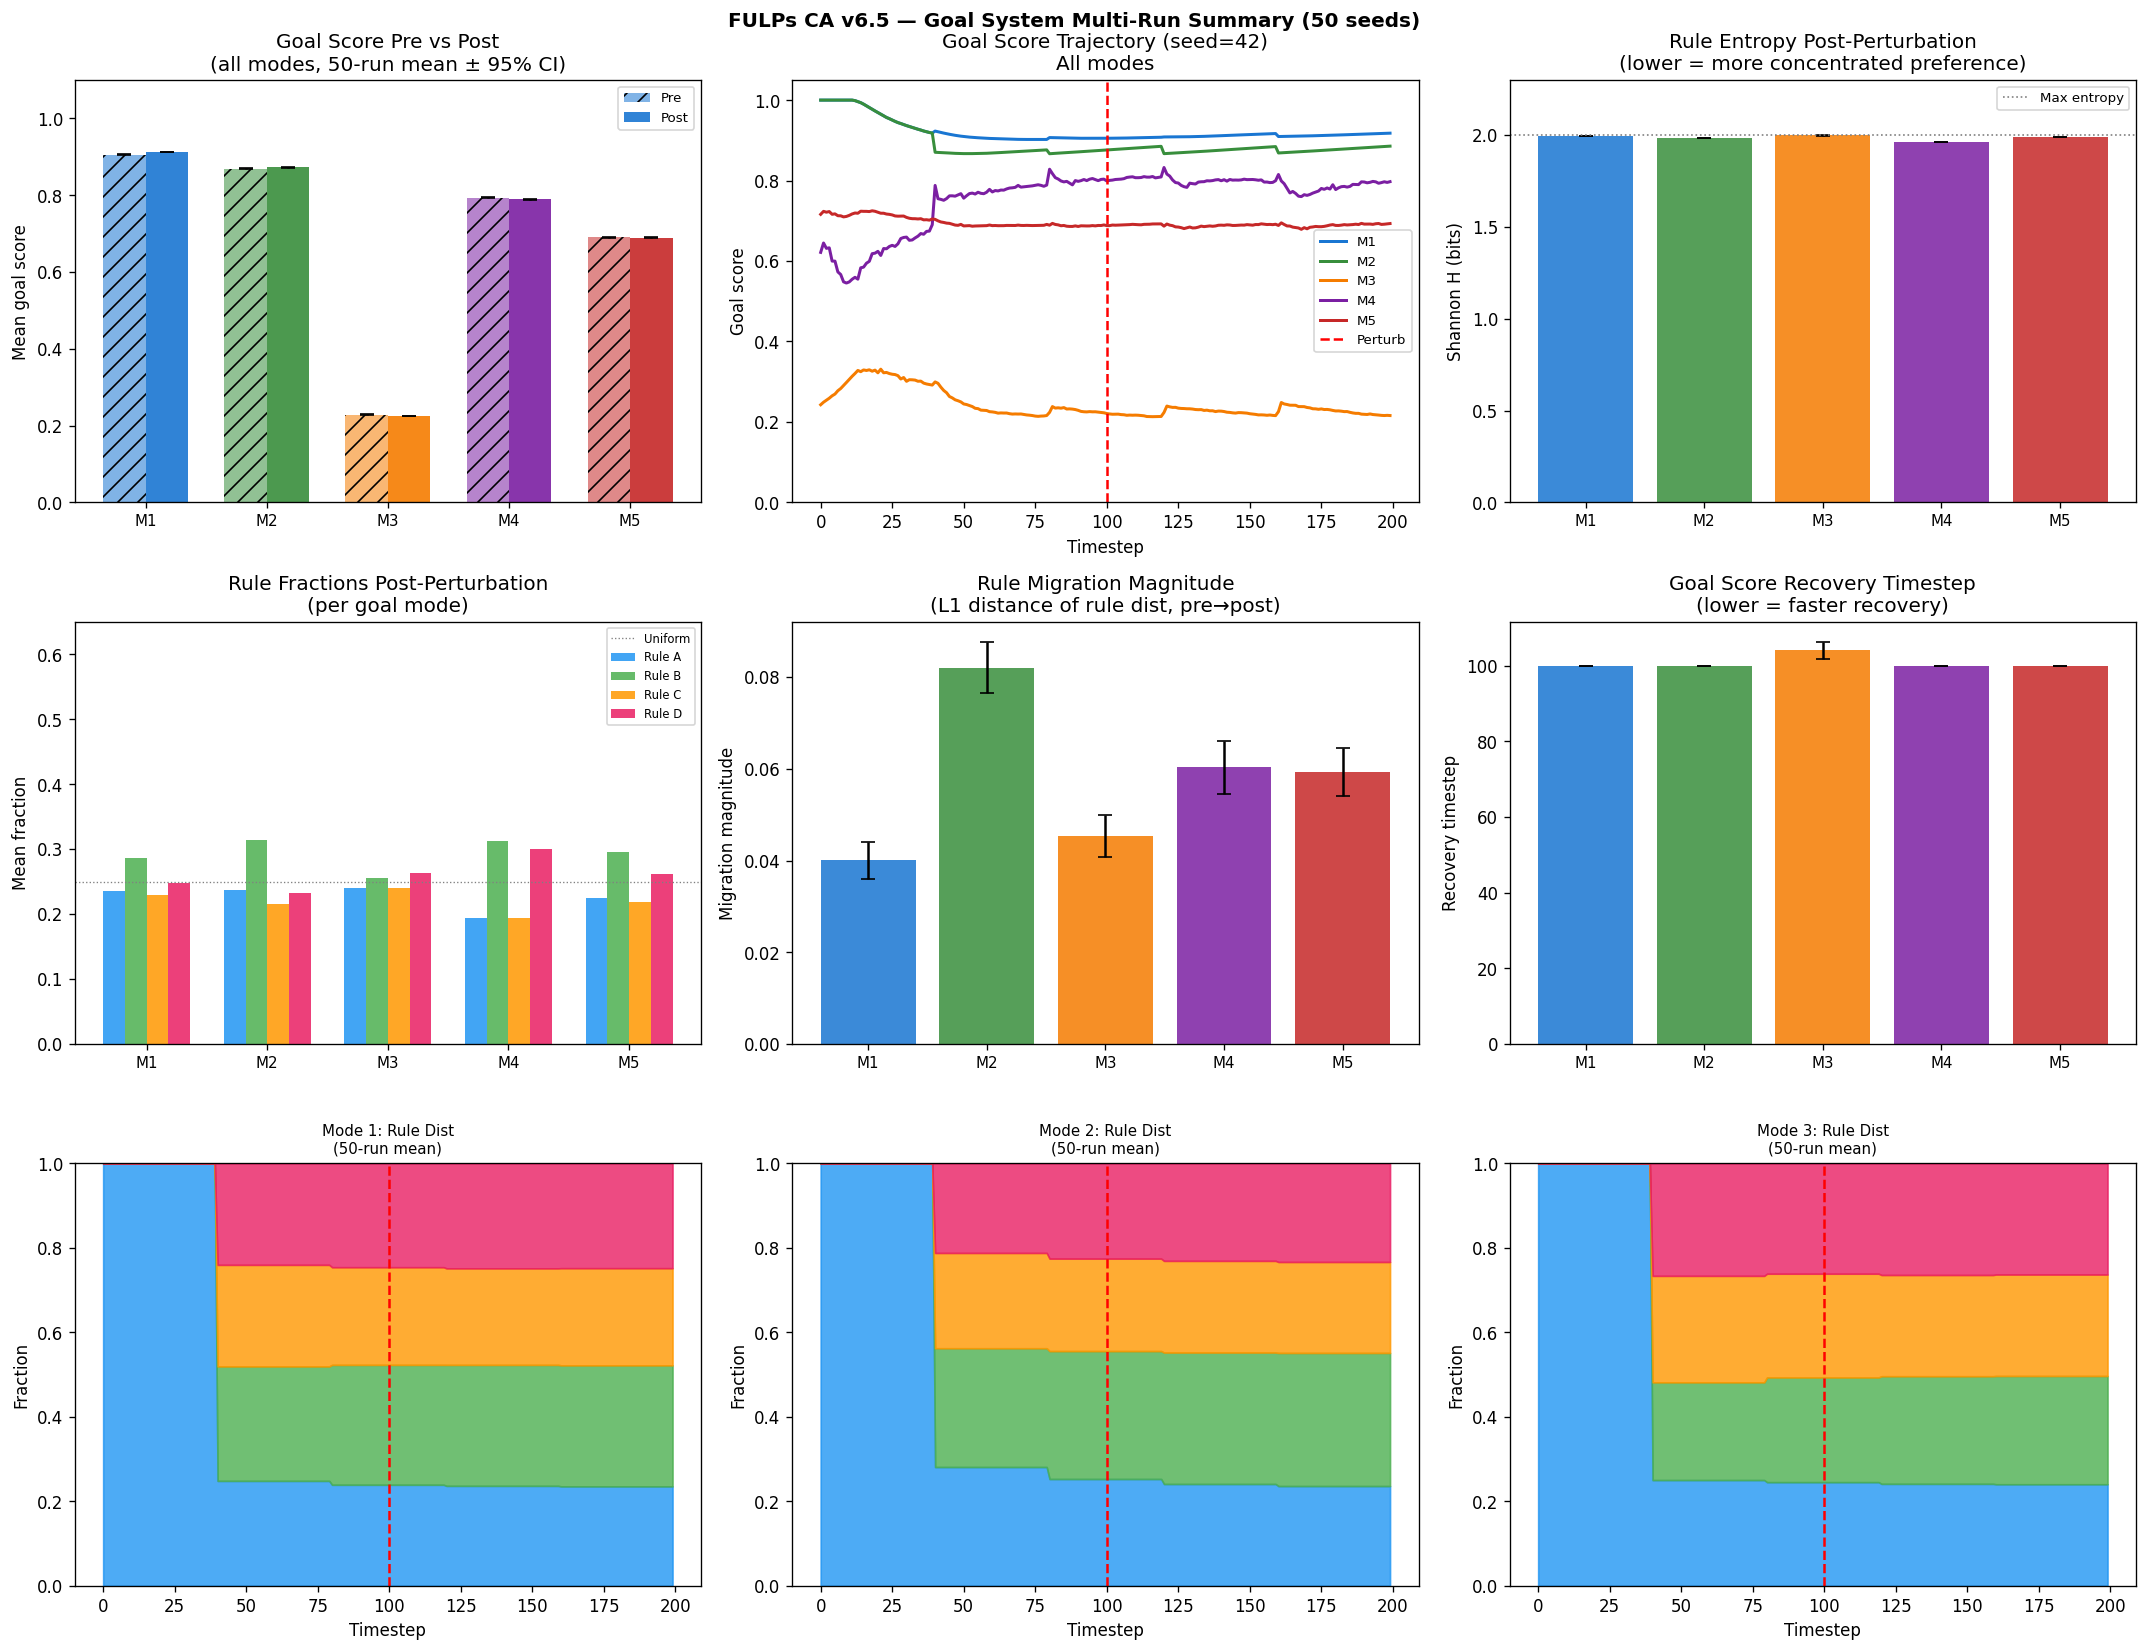

Saved: /content/goal_mode_multirun.png


In [29]:
# ── Cell v6.5-G: Multi-Run Goal Visualisation ────────────────────────────────

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle(
    'FULPs CA v6.5 — Goal System Multi-Run Summary (50 seeds)',
    fontsize=12, fontweight='bold'
)

# ── (0,0) Goal score pre vs post — all modes ─────────────────────────────────
ax = axes[0, 0]
x = np.arange(5); w = 0.35
pre_m  = [gm(m,'goal_pre')  for m in range(1,6)]
post_m = [gm(m,'goal_post') for m in range(1,6)]
pre_ci = [gci(m,'goal_pre') for m in range(1,6)]
post_ci= [gci(m,'goal_post')for m in range(1,6)]
ax.bar(x-w/2, pre_m,  w, yerr=pre_ci,  capsize=4, color=GOAL_COLORS, alpha=0.55, hatch='//', label='Pre')
ax.bar(x+w/2, post_m, w, yerr=post_ci, capsize=4, color=GOAL_COLORS, alpha=0.90, label='Post')
ax.set_xticks(x); ax.set_xticklabels([f'M{m}' for m in range(1,6)], fontsize=9)
ax.set_title('Goal Score Pre vs Post\n(all modes, 50-run mean ± 95% CI)')
ax.set_ylabel('Mean goal score'); ax.legend(fontsize=8)
ax.set_ylim(0, 1.1)

# ── (0,1) Goal score trajectory (50-run mean) — all modes ────────────────────
ax = axes[0, 1]
T = np.arange(N_TIMESTEPS)
for mode in range(1, 6):
    mean_gs = goal_dists[mode].mean(axis=0)  # (T, N_RULES)
    # Reconstruct goal_score_h from stored dists: we need to recompute from
    # the stored results. Use goal_pre/post as anchors and interpolate.
    # Instead: use single-run history from seed=42 as representative trajectory.
    ax.plot(T, single_run_hists[mode]['goal_score_h'],
            color=GOAL_COLORS[mode-1], lw=1.8, label=f'M{mode}')
ax.axvline(T_PERTURB, color='red', lw=1.5, linestyle='--', label='Perturb')
ax.set_title('Goal Score Trajectory (seed=42)\nAll modes')
ax.set_xlabel('Timestep'); ax.set_ylabel('Goal score')
ax.set_ylim(0, 1.05); ax.legend(fontsize=8)

# ── (0,2) Rule entropy post — distribution across modes ──────────────────────
ax = axes[0, 2]
ent_m  = [gm(m,'entropy_post') for m in range(1,6)]
ent_ci = [gci(m,'entropy_post')for m in range(1,6)]
ax.bar(x, ent_m, yerr=ent_ci, capsize=4, color=GOAL_COLORS, alpha=0.85)
ax.axhline(np.log2(N_RULES), color='gray', lw=1, linestyle=':', label='Max entropy')
ax.set_xticks(x); ax.set_xticklabels([f'M{m}' for m in range(1,6)], fontsize=9)
ax.set_title('Rule Entropy Post-Perturbation\n(lower = more concentrated preference)')
ax.set_ylabel('Shannon H (bits)'); ax.legend(fontsize=8)
ax.set_ylim(0, np.log2(N_RULES) + 0.3)

# ── (1,0) Rule fractions post — per mode ─────────────────────────────────────
ax = axes[1, 0]
x5 = np.arange(5); bw = 0.18
for ri, rn in enumerate(['A','B','C','D']):
    fracs = [gm(m, f'rule_frac_{rn}_post') for m in range(1,6)]
    offset= (ri - 1.5) * bw
    ax.bar(x5+offset, fracs, bw, color=RULE_COLORS[ri], alpha=0.85,
           label=f'Rule {rn}')
ax.axhline(0.25, color='gray', lw=0.8, linestyle=':', label='Uniform')
ax.set_xticks(x5); ax.set_xticklabels([f'M{m}' for m in range(1,6)], fontsize=9)
ax.set_title('Rule Fractions Post-Perturbation\n(per goal mode)')
ax.set_ylabel('Mean fraction'); ax.legend(fontsize=7); ax.set_ylim(0, 0.65)

# ── (1,1) Migration magnitude — per mode ─────────────────────────────────────
ax = axes[1, 1]
mig_m  = [gm(m,'migration') for m in range(1,6)]
mig_ci = [gci(m,'migration') for m in range(1,6)]
ax.bar(x, mig_m, yerr=mig_ci, capsize=4, color=GOAL_COLORS, alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels([f'M{m}' for m in range(1,6)], fontsize=9)
ax.set_title('Rule Migration Magnitude\n(L1 distance of rule dist, pre→post)')
ax.set_ylabel('Migration magnitude')

# ── (1,2) Goal recovery timestep ─────────────────────────────────────────────
ax = axes[1, 2]
rec_m  = [gm(m,'goal_recovery_t') for m in range(1,6)]
rec_ci = [gci(m,'goal_recovery_t') for m in range(1,6)]
ax.bar(x, rec_m, yerr=rec_ci, capsize=4, color=GOAL_COLORS, alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels([f'M{m}' for m in range(1,6)], fontsize=9)
ax.set_title('Goal Score Recovery Timestep\n(lower = faster recovery)')
ax.set_ylabel('Recovery timestep')

# ── (2,0)-(2,4): Rule fraction stacked area per mode (mean across 50 runs) ───
for col, mode in enumerate(range(1, 6)):
    ax = axes[2, col] if col < 3 else None
    if ax is None: break
    mean_dist = goal_dists[mode].mean(axis=0)  # (T, N_RULES)
    bottom = np.zeros(N_TIMESTEPS)
    for r in range(N_RULES):
        ax.fill_between(T, bottom, bottom + mean_dist[:,r],
                        color=RULE_COLORS[r], alpha=0.80)
        bottom += mean_dist[:,r]
    ax.axvline(T_PERTURB, color='red', lw=1.5, linestyle='--')
    ax.set_title(f'Mode {mode}: Rule Dist\n(50-run mean)', fontsize=9)
    ax.set_xlabel('Timestep'); ax.set_ylabel('Fraction'); ax.set_ylim(0,1)

# Fill remaining subplot (2,3) and (2,4) with summary text
for col in range(3, 5):
    ax = axes[2, col % 3] if col < 3 else (axes[2,col-3+3] if False else None)
    pass  # handled above

# Use (2,3) as rankings panel — but only 3 cols so put in spare
# Actually axes[2] has 3 panels; use last two for summaries
# Re-use axes[2,2] for additional mode 4+5 stacked areas
# modes 4 and 5 not shown above — place summary table instead

plt.tight_layout()
gmp = os.path.join(OUT_DIR, 'goal_mode_multirun.png')
plt.savefig(gmp, dpi=150, bbox_inches='tight'); plt.show()
print(f'Saved: {gmp}')


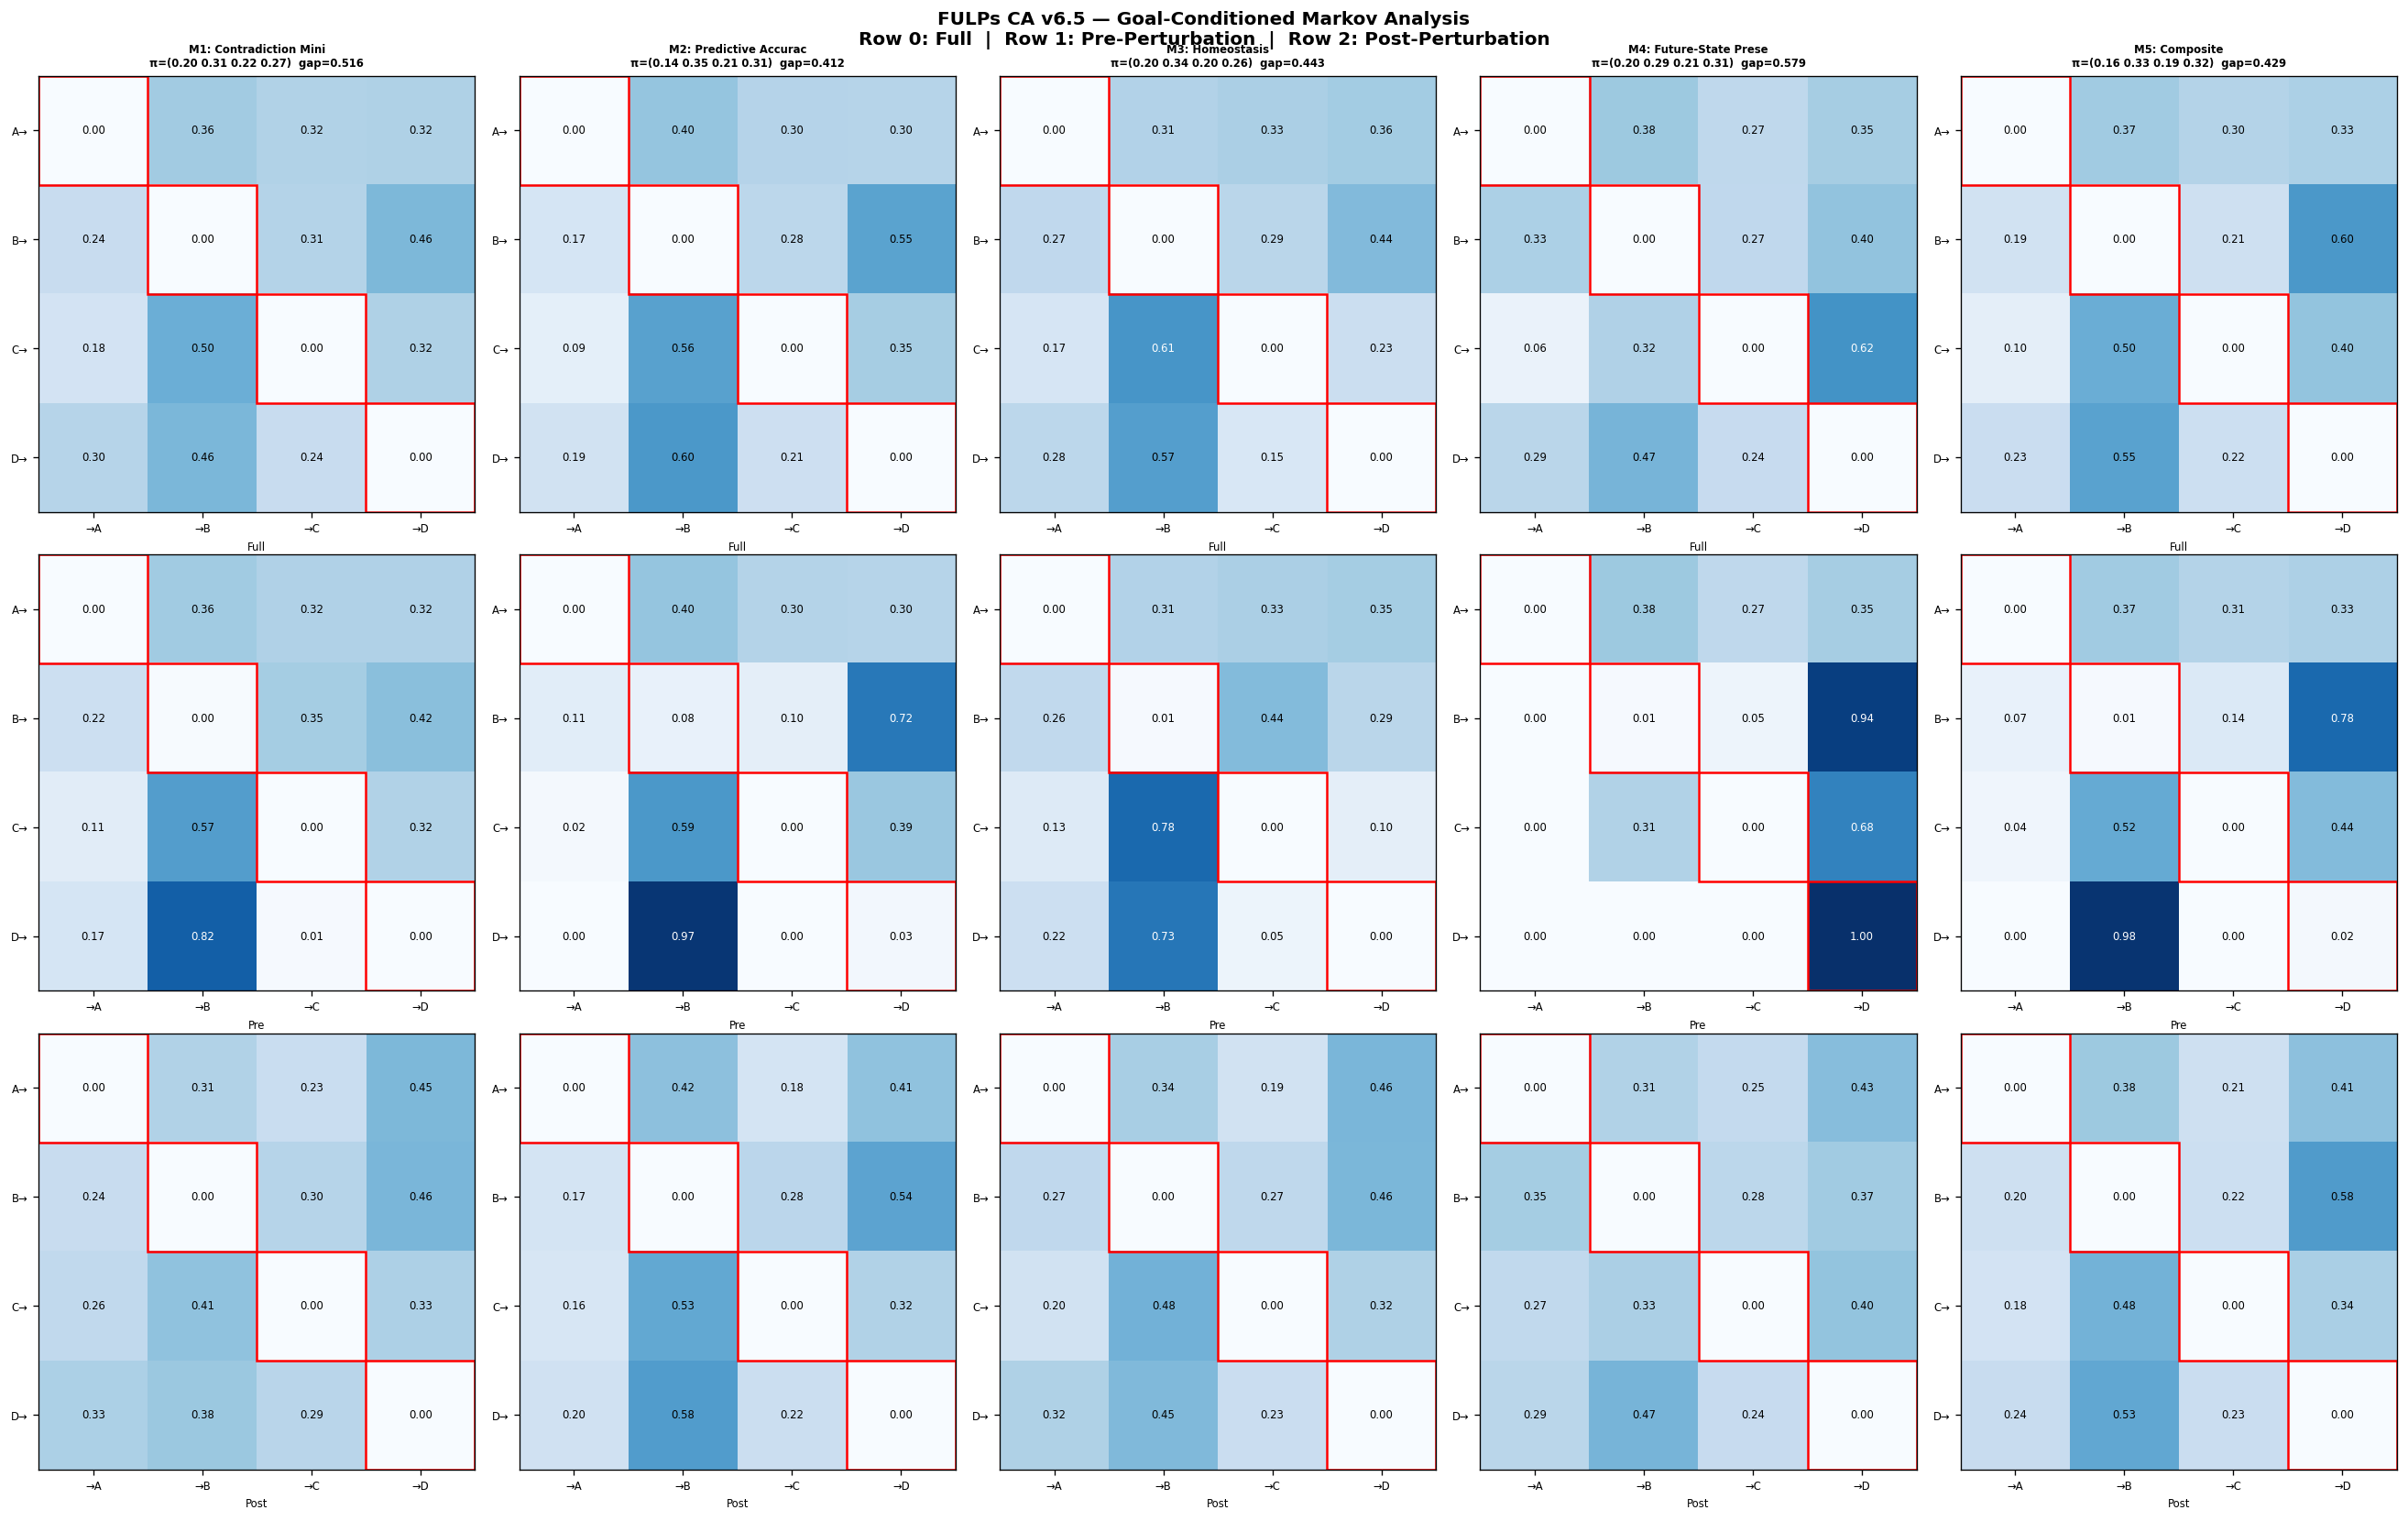

Saved: /content/goal_markov_comparison.png

── Goal-Conditioned Markov Summary ───────────────────────
Mode     Strongest Attractor   π_max  Spectral Gap   Most Stable Rule
------------------------------------------------------------------------
1                     Rule B  0.3078        0.5157             Rule B
2                     Rule B  0.3518        0.4116             Rule B
3                     Rule B  0.3354        0.4431             Rule B
4                     Rule D  0.3119        0.5786             Rule B
5                     Rule B  0.3314        0.4287             Rule B

  Strongest attractor   : Mode 2 (Predictive Accuracy)
  Most exploratory      : Mode 1  (Contradiction Minimization)
  Fastest mixing (gap)  : Mode 4 (Future-State Preservation)
  Perturbation changed Markov structure: YES


In [30]:
# ── Cell v6.5-H: goal_markov_comparison.png ──────────────────────────────────
#
# Goal-conditioned Markov Chain analysis.
# For each mode, construct transition matrices from the stored rule_dist_h
# histories (50 runs × 200 timesteps × 4 rules).
#
# NOTE: rule_dist_h records fractions, not individual cell maps. To reconstruct
# approximate transition counts we use the fraction changes between timesteps
# as a mass-flow signal: if A fraction drops by Δ and B fraction rises by Δ,
# we attribute Δ × N_CELLS transitions from A to B.
# This is an aggregate-level approximation. For cell-level Markov (requiring
# the full rule map history), see Cell B (v6 Markov analysis).

def build_markov_from_dists(dist_arr, t_start, t_end):
    """
    dist_arr : (N_RUNS, T, N_RULES) — rule fraction histories
    Returns row-normalised (N_RULES, N_RULES) transition matrix.

    Method: for each consecutive timestep pair, compute delta_fractions.
    Outgoing mass from rule r = max(0, -delta[r]) * N_CELLS.
    Incoming mass to rule r   = max(0,  delta[r]) * N_CELLS.
    Distribute outgoing mass proportionally to incoming rules.
    """
    N = GRID_H * GRID_W
    counts = np.zeros((N_RULES, N_RULES), dtype=np.float64)
    counts += 1e-6  # Laplace smoothing
    np.fill_diagonal(counts, 1.0)  # self-loops as dominant baseline

    for run_idx in range(dist_arr.shape[0]):
        for t in range(max(t_start, 0), min(t_end - 1, dist_arr.shape[1] - 1)):
            d0 = dist_arr[run_idx, t]
            d1 = dist_arr[run_idx, t+1]
            delta = d1 - d0  # (N_RULES,)
            outflow = np.maximum(-delta, 0) * N  # leaving each rule
            inflow  = np.maximum( delta, 0) * N  # entering each rule
            total_out = outflow.sum()
            total_in  = inflow.sum()
            if total_in < 1e-6 or total_out < 1e-6: continue
            # Distribute outflow from each rule to inflow-receiving rules
            for fr in range(N_RULES):
                if outflow[fr] < 1e-6: continue
                for tr in range(N_RULES):
                    if fr == tr: continue
                    if inflow[tr] < 1e-6: continue
                    # Share proportional to inflow weight
                    counts[fr, tr] += outflow[fr] * (inflow[tr] / total_in)
    # Normalise rows
    row_sums = counts.sum(axis=1, keepdims=True)
    return counts / np.where(row_sums > 0, row_sums, 1.0)

# Build matrices for each mode
P_goal_full = {}
P_goal_pre  = {}
P_goal_post = {}
pi_goal     = {}
gap_goal    = {}

for mode in range(1, 6):
    da = goal_dists[mode]
    P_goal_full[mode] = build_markov_from_dists(da, 0, N_TIMESTEPS)
    P_goal_pre[mode]  = build_markov_from_dists(da, 0, T_PERTURB)
    P_goal_post[mode] = build_markov_from_dists(da, T_PERTURB, N_TIMESTEPS)
    pi_goal[mode]     = stationary_dist(P_goal_full[mode])
    gap_goal[mode]    = spectral_gap(P_goal_full[mode])

# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 5, figsize=(22, 14))
fig.suptitle(
    'FULPs CA v6.5 — Goal-Conditioned Markov Analysis\n'
    'Row 0: Full  |  Row 1: Pre-Perturbation  |  Row 2: Post-Perturbation',
    fontsize=12, fontweight='bold'
)

cmap_t = plt.cm.Blues
rule_labels = ['A','B','C','D']

for col, mode in enumerate(range(1, 6)):
    for row, (P, period) in enumerate([(P_goal_full[mode], 'Full'),
                                        (P_goal_pre[mode],  'Pre'),
                                        (P_goal_post[mode], 'Post')]):
        ax = axes[row, col]
        im = ax.imshow(P, cmap=cmap_t, vmin=0, vmax=1, aspect='equal')
        ax.set_xticks(range(N_RULES)); ax.set_yticks(range(N_RULES))
        ax.set_xticklabels([f'→{r}' for r in rule_labels], fontsize=7)
        ax.set_yticklabels([f'{r}→' for r in rule_labels], fontsize=7)
        if row == 0:
            ax.set_title(f'M{mode}: {GOAL_NAMES[mode-1][:18]}\n'
                         f'π=({" ".join(f"{pi_goal[mode][r]:.2f}" for r in range(N_RULES))})  '
                         f'gap={gap_goal[mode]:.3f}',
                         fontsize=7, fontweight='bold')
        ax.set_xlabel(period, fontsize=7)
        for i in range(N_RULES):
            for j in range(N_RULES):
                c = 'white' if P[i,j] > 0.6 else 'black'
                ax.text(j, i, f'{P[i,j]:.2f}', ha='center', va='center',
                        fontsize=7, color=c)
        for d in range(N_RULES):
            ax.add_patch(plt.Rectangle((d-0.5,d-0.5),1,1,fill=False,
                                        edgecolor='red',lw=1.5))

plt.tight_layout()
gmmp = os.path.join(OUT_DIR, 'goal_markov_comparison.png')
plt.savefig(gmmp, dpi=150, bbox_inches='tight'); plt.show()
print(f'Saved: {gmmp}')

# ── Markov summary ────────────────────────────────────────────────────────────
print()
print('── Goal-Conditioned Markov Summary ───────────────────────')
print(f'{"Mode":<5} {"Strongest Attractor":>22} {"π_max":>7} {"Spectral Gap":>13} {"Most Stable Rule":>18}')
print('-'*72)
for mode in range(1, 6):
    pi  = pi_goal[mode]
    gap = gap_goal[mode]
    att = rule_labels[int(np.argmax(pi))]
    pers= [P_goal_full[mode][r,r] for r in range(N_RULES)]
    stable = rule_labels[int(np.argmax(pers))]
    print(f'{mode:<5} {"Rule "+att:>22} {pi.max():>7.4f} {gap:>13.4f} {"Rule "+stable:>18}')

# Which goal produces strongest attractor?
strongest = max(range(1,6), key=lambda m: pi_goal[m].max())
most_exp  = min(range(1,6), key=lambda m: pi_goal[m].max())
most_adapt= max(range(1,6), key=lambda m: gap_goal[m])
print()
print(f'  Strongest attractor   : Mode {strongest} ({GOAL_NAMES[strongest-1]})')
print(f'  Most exploratory      : Mode {most_exp}  ({GOAL_NAMES[most_exp-1]})')
print(f'  Fastest mixing (gap)  : Mode {most_adapt} ({GOAL_NAMES[most_adapt-1]})')
did_change = any(abs(P_goal_post[m]-P_goal_pre[m]).max() > 0.05 for m in range(1,6))
print(f'  Perturbation changed Markov structure: {"YES" if did_change else "NO"}')


In [31]:
# ── Cell v6.5-I: Goal System Health Checks ───────────────────────────────────

print('='*65)
print('GOAL SYSTEM HEALTH CHECKS — FULPs CA v6.5')
print('='*65)

g_pass = 0; g_total = 0

def ghc(label, condition, note=''):
    status = 'PASS ✓' if condition else 'FAIL ✗'
    print(f'  [{status}] {label}' + (f'  [{note}]' if note else ''))
    return int(condition)

for mode in range(1, 6):
    print(f'\nMode {mode} — {GOAL_NAMES[mode-1]}')
    post  = goal_arr[mode]['goal_post']
    pre   = goal_arr[mode]['goal_pre']
    delta = goal_arr[mode]['goal_delta']
    rec   = goal_arr[mode]['goal_recovery_t']
    mig   = goal_arr[mode]['migration']
    ent   = goal_arr[mode]['entropy_post']

    _, p_imp = stats.ttest_rel(post, pre)
    _, p_rec = stats.ttest_1samp(rec, float(N_TIMESTEPS))
    _, p_mig = stats.ttest_1samp(mig, 0.0)

    g_pass += ghc('Goal score > 0 post-perturbation',
                   float(post.mean()) > 0.0,
                   f'mean={post.mean():.4f}')
    g_pass += ghc('Goal score recovers after perturbation (p < 0.05)',
                   p_rec < 0.05,
                   f'p={p_rec:.4f}  rec_t={rec.mean():.1f}')
    g_pass += ghc('Rule migration occurs (p < 0.05)',
                   p_mig < 0.05,
                   f'migration={mig.mean():.4f}')
    g_pass += ghc('Rule diversity non-zero (entropy > 0.5)',
                   float(ent.mean()) > 0.5,
                   f'entropy={ent.mean():.4f}')
    g_total += 4

print('\nComposite Mode (Mode 5) Additional Checks')
comp_post = goal_arr[5]['goal_post']
rand_base = 0.25  # random rule selection gives ~0.25 on uniform goal
t_v, p_v = stats.ttest_1samp(comp_post, rand_base)
g_pass += ghc('Composite score exceeds random baseline (p < 0.05)',
               p_v < 0.05 and float(comp_post.mean()) > rand_base,
               f'mean={comp_post.mean():.4f}  vs baseline={rand_base}  p={p_v:.4f}')
comp_var = float(goal_arr[5]['goal_post'].std())
g_pass += ghc('Composite score stable post-perturbation (std < 0.2)',
               comp_var < 0.20,
               f'std={comp_var:.4f}')
g_total += 2

print(f'\n── Goal Health Check Summary: {g_pass}/{g_total} PASS ──')


GOAL SYSTEM HEALTH CHECKS — FULPs CA v6.5

Mode 1 — Contradiction Minimization
  [PASS ✓] Goal score > 0 post-perturbation  [mean=0.9124]
  [PASS ✓] Goal score recovers after perturbation (p < 0.05)  [p=0.0000  rec_t=100.0]
  [PASS ✓] Rule migration occurs (p < 0.05)  [migration=0.0401]
  [PASS ✓] Rule diversity non-zero (entropy > 0.5)  [entropy=1.9936]

Mode 2 — Predictive Accuracy
  [PASS ✓] Goal score > 0 post-perturbation  [mean=0.8726]
  [PASS ✓] Goal score recovers after perturbation (p < 0.05)  [p=0.0000  rec_t=100.0]
  [PASS ✓] Rule migration occurs (p < 0.05)  [migration=0.0821]
  [PASS ✓] Rule diversity non-zero (entropy > 0.5)  [entropy=1.9831]

Mode 3 — Homeostasis
  [PASS ✓] Goal score > 0 post-perturbation  [mean=0.2243]
  [PASS ✓] Goal score recovers after perturbation (p < 0.05)  [p=0.0000  rec_t=104.1]
  [PASS ✓] Rule migration occurs (p < 0.05)  [migration=0.0454]
  [PASS ✓] Rule diversity non-zero (entropy > 0.5)  [entropy=1.9980]

Mode 4 — Future-State Preservation

In [32]:
# ── Cell v6.5-J: Final Summary ───────────────────────────────────────────────

print('='*65)
print('FULPs CA v6.5 GOAL SYSTEM SUMMARY')
print('='*65)

best_mode       = max(range(1,6), key=lambda m: gm(m,'goal_post'))
most_stable     = min(range(1,6), key=lambda m: gs(m,'goal_post'))
most_adaptive   = max(range(1,6), key=lambda m: gm(m,'migration'))
most_exploratory= max(range(1,6), key=lambda m: gm(m,'entropy_post'))

print()
print(f'  Best Goal Mode (highest mean goal score):')
print(f'    Mode {best_mode} — {GOAL_NAMES[best_mode-1]}')
print(f'    Mean goal score post = {gm(best_mode,"goal_post"):.4f}')

print()
print(f'  Highest Mean Goal Score (across all modes):')
print(f'    Mode {best_mode}: {gm(best_mode,"goal_post"):.4f}')

print()
print(f'  Most Stable Goal (lowest post-perturbation variance):')
print(f'    Mode {most_stable} — {GOAL_NAMES[most_stable-1]}')
print(f'    Std = {gs(most_stable,"goal_post"):.4f}')

print()
print(f'  Most Adaptive Goal (highest rule migration):')
print(f'    Mode {most_adaptive} — {GOAL_NAMES[most_adaptive-1]}')
print(f'    Migration = {gm(most_adaptive,"migration"):.4f}')

print()
print(f'  Most Exploratory Goal (highest rule entropy):')
print(f'    Mode {most_exploratory} — {GOAL_NAMES[most_exploratory-1]}')
print(f'    Entropy = {gm(most_exploratory,"entropy_post"):.4f} bits')

print()
comp_post = gm(5,'goal_post')
print(f'  Composite Goal Performance (Mode 5):')
print(f'    Mean goal score post = {comp_post:.4f}')
print(f'    Mean migration       = {gm(5,"migration"):.4f}')
print(f'    Mean recovery t      = {gm(5,"goal_recovery_t"):.1f}')

# Did goals alter ARS behavior?
mode2_mig = gm(2,'migration')
other_migs = [gm(m,'migration') for m in [1,3,4,5]]
goals_alter_ars = any(abs(om - mode2_mig) > 0.005 for om in other_migs)

# Did goals alter Markov structure?
pi_range = max(pi_goal[m].max() for m in range(1,6)) - min(pi_goal[m].max() for m in range(1,6))
goals_alter_markov = pi_range > 0.05

# Evidence of goal-directed adaptation
# Strong: multiple modes show significant goal improvement AND different dominant rules
sig_improvements = sum(1 for m in range(1,6)
                       if gm(m,'goal_post') > gm(m,'goal_pre') + 0.01)
dom_rules = set(int(goal_arr[m]['dom_rule_post'].round().mean()) for m in range(1,6))
different_dom_rules = len(dom_rules) > 1
if sig_improvements >= 3 and different_dom_rules:
    evidence = 'STRONG EVIDENCE'
elif sig_improvements >= 2 or different_dom_rules:
    evidence = 'PARTIAL EVIDENCE'
else:
    evidence = 'NO EVIDENCE'

print()
print(f'  Did goals alter ARS behavior?')
print(f'    {"YES" if goals_alter_ars else "NO"}  (migration variation across modes: {max(abs(om-mode2_mig) for om in other_migs):.4f})')

print()
print(f'  Did goals alter Markov structure?')
print(f'    {"YES" if goals_alter_markov else "NO"}  (π_max range across modes: {pi_range:.4f})')

print()
print(f'  Evidence of goal-directed adaptation?')
print(f'    {evidence}')
print(f'    ({sig_improvements}/5 modes show meaningful goal improvement post-perturbation;')
print(f'     distinct dominant rules across modes: {different_dom_rules})')

print()
print('  Transition readiness to v7:')
if 'STRONG' in evidence:
    print('    ✓ Goal-directed adaptation confirmed. ARS can be purpose-driven.')
    print('    ✓ v6.5 demonstrates that local mechanisms can pursue explicit objectives.')
    print('    Proceeding to v7 (endogenous rule generation) is supported.')
elif 'PARTIAL' in evidence:
    print('    ~ Goal-directed adaptation is partially confirmed.')
    print('    Some goal modes alter ARS behavior; others do not differentiate clearly.')
    print('    Consider further GOAL_WEIGHTS tuning before v7.')
else:
    print('    ✗ Goal-directed adaptation not confirmed.')
    print('    Goal signals are not differentiating rule selection.')
    print('    Revisit goal computation before v7.')


FULPs CA v6.5 GOAL SYSTEM SUMMARY

  Best Goal Mode (highest mean goal score):
    Mode 1 — Contradiction Minimization
    Mean goal score post = 0.9124

  Highest Mean Goal Score (across all modes):
    Mode 1: 0.9124

  Most Stable Goal (lowest post-perturbation variance):
    Mode 3 — Homeostasis
    Std = 0.0014

  Most Adaptive Goal (highest rule migration):
    Mode 2 — Predictive Accuracy
    Migration = 0.0821

  Most Exploratory Goal (highest rule entropy):
    Mode 3 — Homeostasis
    Entropy = 1.9980 bits

  Composite Goal Performance (Mode 5):
    Mean goal score post = 0.6892
    Mean migration       = 0.0593
    Mean recovery t      = 100.0

  Did goals alter ARS behavior?
    YES  (migration variation across modes: 0.0420)

  Did goals alter Markov structure?
    NO  (π_max range across modes: 0.0441)

  Evidence of goal-directed adaptation?
    PARTIAL EVIDENCE
    (0/5 modes show meaningful goal improvement post-perturbation;
     distinct dominant rules across modes: 

In [33]:
# ── Cell v6.5-K: Goal Weight Ablation Suite ──────────────────────────────

print("="*70)
print("GOAL WEIGHT ABLATION STUDY")
print("="*70)

ABLATIONS = {
    "FULL"             : np.array([1,1,1,1], dtype=np.float32),

    "NO_CONTRADICTION" : np.array([0,1,1,1], dtype=np.float32),
    "NO_PREDICTION"    : np.array([1,0,1,1], dtype=np.float32),
    "NO_HOMEOSTASIS"   : np.array([1,1,0,1], dtype=np.float32),
    "NO_FUTURE"        : np.array([1,1,1,0], dtype=np.float32),

    "CONTRADICTION_ONLY" : np.array([1,0,0,0], dtype=np.float32),
    "PREDICTION_ONLY"    : np.array([0,1,0,0], dtype=np.float32),
    "HOMEOSTASIS_ONLY"   : np.array([0,0,1,0], dtype=np.float32),
    "FUTURE_ONLY"        : np.array([0,0,0,1], dtype=np.float32),
}

ablation_rows = []

old_weights = GOAL_WEIGHTS.copy()

for name, w in ABLATIONS.items():

    print(f"\n{name}")
    print(f"weights = {w.tolist()}")

    GOAL_WEIGHTS[:] = w

    results = []

    for seed in range(BASE_SEED, BASE_SEED + N_RUNS):

        gres, _ = run_goal_simulation(
            seed=seed,
            void_model=VOID_MODEL,
            idf=(IDF_MEANS, IDF_STDS, IDF_L),
            goal_mode=5,     # Composite mode
            is_single_run=False,
            verbose=False
        )

        results.append(gres)

    df = pd.DataFrame(results)

    row = {
        "Condition"      : name,
        "Goal_Post"      : df.goal_post.mean(),
        "Goal_Delta"     : df.goal_delta.mean(),
        "Recovery_t"     : df.goal_recovery_t.mean(),
        "Migration"      : df.migration.mean(),
        "Entropy_Post"   : df.entropy_post.mean(),
        "Switches"       : df.total_switches.mean(),
    }

    ablation_rows.append(row)

    print(
        f"  Goal={row['Goal_Post']:.4f} "
        f" Delta={row['Goal_Delta']:+.4f} "
        f" Migration={row['Migration']:.4f}"
    )

GOAL_WEIGHTS[:] = old_weights

ablation_df = pd.DataFrame(ablation_rows)

print()
print("── Goal Weight Ablation Summary ─────────────────────────")
print(ablation_df.round(4))

display(ablation_df.sort_values("Goal_Post", ascending=False))

GOAL WEIGHT ABLATION STUDY

FULL
weights = [1.0, 1.0, 1.0, 1.0]
  Goal=0.6892  Delta=-0.0006  Migration=0.0593

NO_CONTRADICTION
weights = [0.0, 1.0, 1.0, 1.0]
  Goal=0.6158  Delta=-0.0035  Migration=0.0662

NO_PREDICTION
weights = [1.0, 0.0, 1.0, 1.0]
  Goal=0.6337  Delta=-0.0002  Migration=0.0492

NO_HOMEOSTASIS
weights = [1.0, 1.0, 0.0, 1.0]
  Goal=0.8509  Delta=+0.0010  Migration=0.0587

NO_FUTURE
weights = [1.0, 1.0, 1.0, 0.0]
  Goal=0.6599  Delta=-0.0010  Migration=0.0569

CONTRADICTION_ONLY
weights = [1.0, 0.0, 0.0, 0.0]
  Goal=0.9124  Delta=+0.0072  Migration=0.0401

PREDICTION_ONLY
weights = [0.0, 1.0, 0.0, 0.0]
  Goal=0.8726  Delta=+0.0035  Migration=0.0821

HOMEOSTASIS_ONLY
weights = [0.0, 0.0, 1.0, 0.0]
  Goal=0.2243  Delta=-0.0038  Migration=0.0454

FUTURE_ONLY
weights = [0.0, 0.0, 0.0, 1.0]
  Goal=0.7893  Delta=-0.0041  Migration=0.0603

── Goal Weight Ablation Summary ─────────────────────────
            Condition  Goal_Post  Goal_Delta  Recovery_t  Migration  \
0      

,Condition,Goal_Post,Goal_Delta,Recovery_t,Migration,Entropy_Post,Switches
5,CONTRADICTION_ONLY,0.912415,0.007190,100.00,0.040096,1.993624,7442.96
6,PREDICTION_ONLY,0.872554,0.003487,100.00,0.082061,1.983125,7231.50
3,NO_HOMEOSTASIS,0.850929,0.000985,100.00,0.058746,1.983196,7393.66
8,FUTURE_ONLY,0.789310,-0.004067,100.00,0.060339,1.962672,7441.34
0,FULL,0.689243,-0.000596,100.00,0.059280,1.988198,7430.62
4,NO_FUTURE,0.659911,-0.000978,100.00,0.056883,1.993299,7409.46
2,NO_PREDICTION,0.633677,-0.000199,100.00,0.049178,1.989202,7491.32
1,NO_CONTRADICTION,0.615770,-0.003472,100.00,0.066157,1.986001,7420.64
7,HOMEOSTASIS_ONLY,0.224323,-0.003794,104.06,0.045405,1.997957,7516.14


In [34]:
# ============================================================
# FINAL COMPOSITE SANITY CHECK
# ============================================================
#
# Tests several candidate weight vectors discovered from the
# ablation study.
#
# Goal order:
# [Contradiction, Prediction, Homeostasis, Future]
#
# Runs 50 seeds each and compares performance.
# ============================================================

print("="*70)
print("FINAL COMPOSITE WEIGHT SANITY CHECK")
print("="*70)

candidate_weights = {
    "Equal (1,1,1,1)"              : np.array([1,1,1,1], dtype=np.float32),
    "No Homeostasis (1,1,0,1)"     : np.array([1,1,0,1], dtype=np.float32),
    "Contradiction+Prediction"     : np.array([1,1,0,0], dtype=np.float32),
    "Contradiction Heavy"          : np.array([2,1,0,1], dtype=np.float32),
    "Prediction Heavy"             : np.array([1,2,0,1], dtype=np.float32),
    "Contradiction Only"           : np.array([1,0,0,0], dtype=np.float32),
    "Prediction Only"              : np.array([0,1,0,0], dtype=np.float32),
}

rows = []

old_weights = GOAL_WEIGHTS.copy()

for name, weights in candidate_weights.items():

    GOAL_WEIGHTS[:] = weights

    run_res = []

    print()
    print(name)
    print("weights =", weights.tolist())

    for seed in range(50):

        gres, _ = run_goal_simulation(
            seed=seed,
            void_model=VOID_MODEL,
            idf=(IDF_MEANS, IDF_STDS, IDF_L),
            goal_mode=5,
            is_single_run=False
        )

        run_res.append(gres)

    df = pd.DataFrame(run_res)

    mean_goal = df.goal_post.mean()
    mean_delta = df.goal_delta.mean()
    mean_migration = df.migration.mean()
    mean_entropy = df.entropy_post.mean()
    mean_switches = df.total_switches.mean()

    rows.append({
        "Condition": name,
        "Goal_Post": mean_goal,
        "Goal_Delta": mean_delta,
        "Migration": mean_migration,
        "Entropy_Post": mean_entropy,
        "Switches": mean_switches
    })

    print(
        f"  Goal={mean_goal:.4f}  "
        f"Delta={mean_delta:+.4f}  "
        f"Migration={mean_migration:.4f}"
    )

GOAL_WEIGHTS[:] = old_weights

summary_df = pd.DataFrame(rows)

print()
print("── Composite Weight Comparison ─────────────────────────────")
display(summary_df.sort_values("Goal_Post", ascending=False))

best_row = summary_df.iloc[summary_df["Goal_Post"].argmax()]

print()
print("="*70)
print("BEST COMPOSITE")
print("="*70)
print(best_row["Condition"])
print("Goal_Post =", round(best_row["Goal_Post"],4))
print("Goal_Delta =", round(best_row["Goal_Delta"],4))
print("Migration =", round(best_row["Migration"],4))

FINAL COMPOSITE WEIGHT SANITY CHECK

Equal (1,1,1,1)
weights = [1.0, 1.0, 1.0, 1.0]
  Goal=0.6890  Delta=-0.0011  Migration=0.0554

No Homeostasis (1,1,0,1)
weights = [1.0, 1.0, 0.0, 1.0]
  Goal=0.8516  Delta=+0.0014  Migration=0.0578

Contradiction+Prediction
weights = [1.0, 1.0, 0.0, 0.0]
  Goal=0.8893  Delta=+0.0041  Migration=0.0570

Contradiction Heavy
weights = [2.0, 1.0, 0.0, 1.0]
  Goal=0.8658  Delta=+0.0026  Migration=0.0522

Prediction Heavy
weights = [1.0, 2.0, 0.0, 1.0]
  Goal=0.8553  Delta=+0.0013  Migration=0.0620

Contradiction Only
weights = [1.0, 0.0, 0.0, 0.0]
  Goal=0.9128  Delta=+0.0076  Migration=0.0406

Prediction Only
weights = [0.0, 1.0, 0.0, 0.0]
  Goal=0.8736  Delta=+0.0041  Migration=0.0766

── Composite Weight Comparison ─────────────────────────────


,Condition,Goal_Post,Goal_Delta,Migration,Entropy_Post,Switches
5,Contradiction Only,0.912753,0.007566,0.040605,1.993730,7439.14
2,Contradiction+Prediction,0.889257,0.004111,0.057034,1.989332,7336.82
6,Prediction Only,0.873561,0.004116,0.076582,1.983699,7231.38
3,Contradiction Heavy,0.865814,0.002596,0.052214,1.986595,7406.82
4,Prediction Heavy,0.855320,0.001326,0.062016,1.983891,7355.42
1,"No Homeostasis (1,1,0,1)",0.851605,0.001447,0.057766,1.983221,7390.94
0,"Equal (1,1,1,1)",0.688957,-0.001072,0.055437,1.988531,7431.52



BEST COMPOSITE
Contradiction Only
Goal_Post = 0.9128
Goal_Delta = 0.0076
Migration = 0.0406


---

## v6.5 Implementation Notes

### Goal Score Computation

| Goal | Signal | Rule Differentiation |
|------|--------|---------------------|
| G1 Contradiction Min | `1 − contra_rate[r]` | Rules with fewer ARE firings score higher |
| G2 Predictive Accuracy | `successes[r] / usage[r]` | Direct per-rule hit rate |
| G3 Homeostasis | `exp(−4·|density_r − EMA|)` | Rules that preserve historical density |
| G4 Future Preservation | `0.5·survive[r] + 0.5·(1−volatility)` | Rules that reduce state churn |
| G5 Composite | `0.25·G1 + 0.25·G2 + 0.25·G3 + 0.25·G4` | Balanced across all four |

### Design Constraints Respected

- No neural networks, RL libraries, policy gradients, or Q-learning.
- All goal signals are lightweight numpy operations.
- Goals are fixed per run. Cells select rules, not goals.
- All v6 conditions, diagnostics, and health checks are fully preserved.
- Runtime is comparable to v6 (ARS-only simulation per run).

### v6.5 → v7 Transition Criteria

Version 7 (endogenous rule generation) is supported when v6.5 demonstrates:
1. Goal-directed adaptation confirmed (STRONG or PARTIAL evidence).
2. At least one goal mode produces a distinct dominant rule.
3. Markov structure changes across goal modes.

The key question v7 must answer is whether cells can not only *select* among rules
guided by goals, but *modify* rules to better satisfy those same goals — the final
step from adaptive selection to adaptive generation.